# Задача 2. Node embeddings


## Условие

- [ ] Найти набор данных для бинарной классификации рёбер в графе.
- [ ] Реализовать случайные блуждания алгоритма `DeepWalk` и построить множества схожих вершин
- [ ] Обучить эмбеддинги вершин, используя `SGD` и **negative sampling**.
- [ ] Визуализировать эмбеддинги.
- [ ] (+5 баллов) Также реализовать `node2vec` блуждания и обучить классификатор, используя его. Сравнить результаты.


---



Установим необходимые библиотеки для работы:

In [52]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

from networkx.algorithms.community import girvan_newman
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import SGD

1) **Dolphin Social Network** — это социальная сеть, представляющая взаимодействия между дельфинами у побережья Новой Зеландии. Этот набор данных был собран Дэвидом Лусом и его коллегами в конце 1990-х годов для изучения социальной структуры дельфинов, обитающих в районе островов Фьордленд в Новой Зеландии. Набор данных стал доступен научному сообществу в 2003 году.

- Узлы в графе представляют собой отдельных дельфинов. Каждый узел соответствует одному дельфину в исследуемой популяции.
- Рёбра представляют взаимодействия между дельфинами. Эти взаимодействия могли быть определены как совместные наблюдения дельфинов, которые плавали вместе в течение определенного периода времени. Считается, что дельфины, которые были замечены вместе, взаимодействуют друг с другом социально.

В графе **62** узла (дельфина) за которыми велось наблюдение. А также **159** рёбер, что отражает связи между дельфинами, которые были замечены вместе.

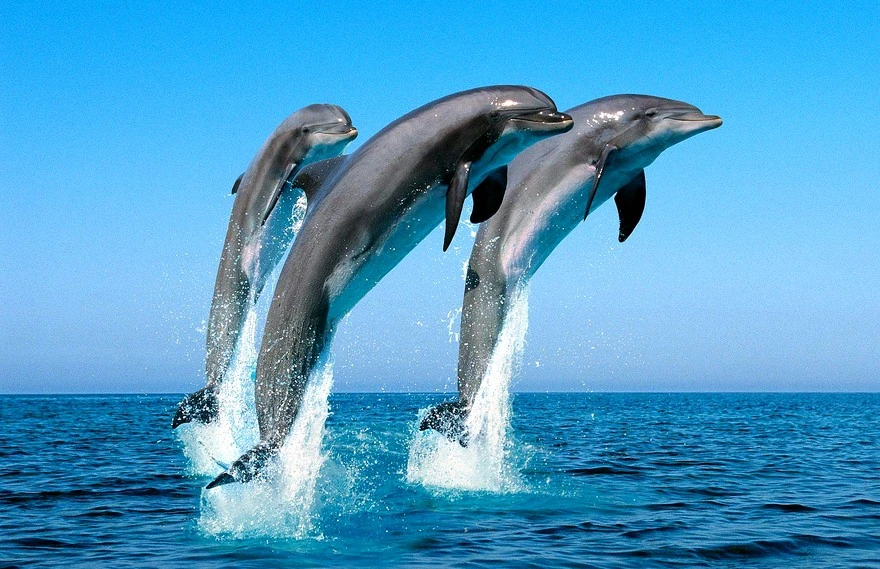

Загрузим граф из библиотеки networkx и визуализируем его:

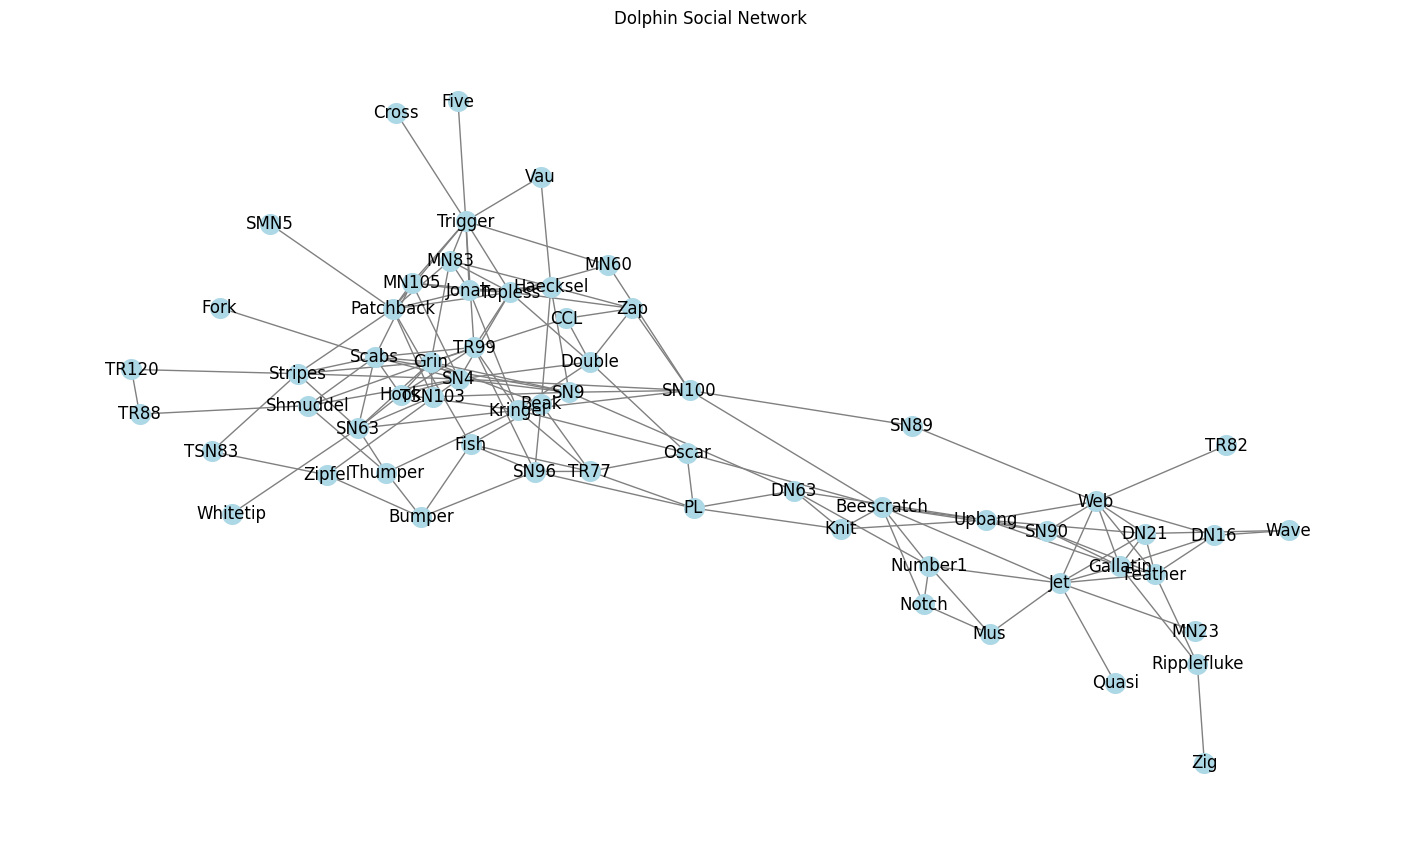

In [25]:
G = nx.read_gml('/content/dolphins.gml')

plt.figure(figsize=(14, 8))
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray', node_size=200)
plt.title("Dolphin Social Network")
plt.show()

Используем алгоритм `Girvan-Newman` для кластеризации графа на два сообщества, выделяя узлы с помощью удаления мостов между ними. Это необходимо, поскольку изначально граф не бинаризован.

Размер группы 1: 41, Размер группы 2: 21


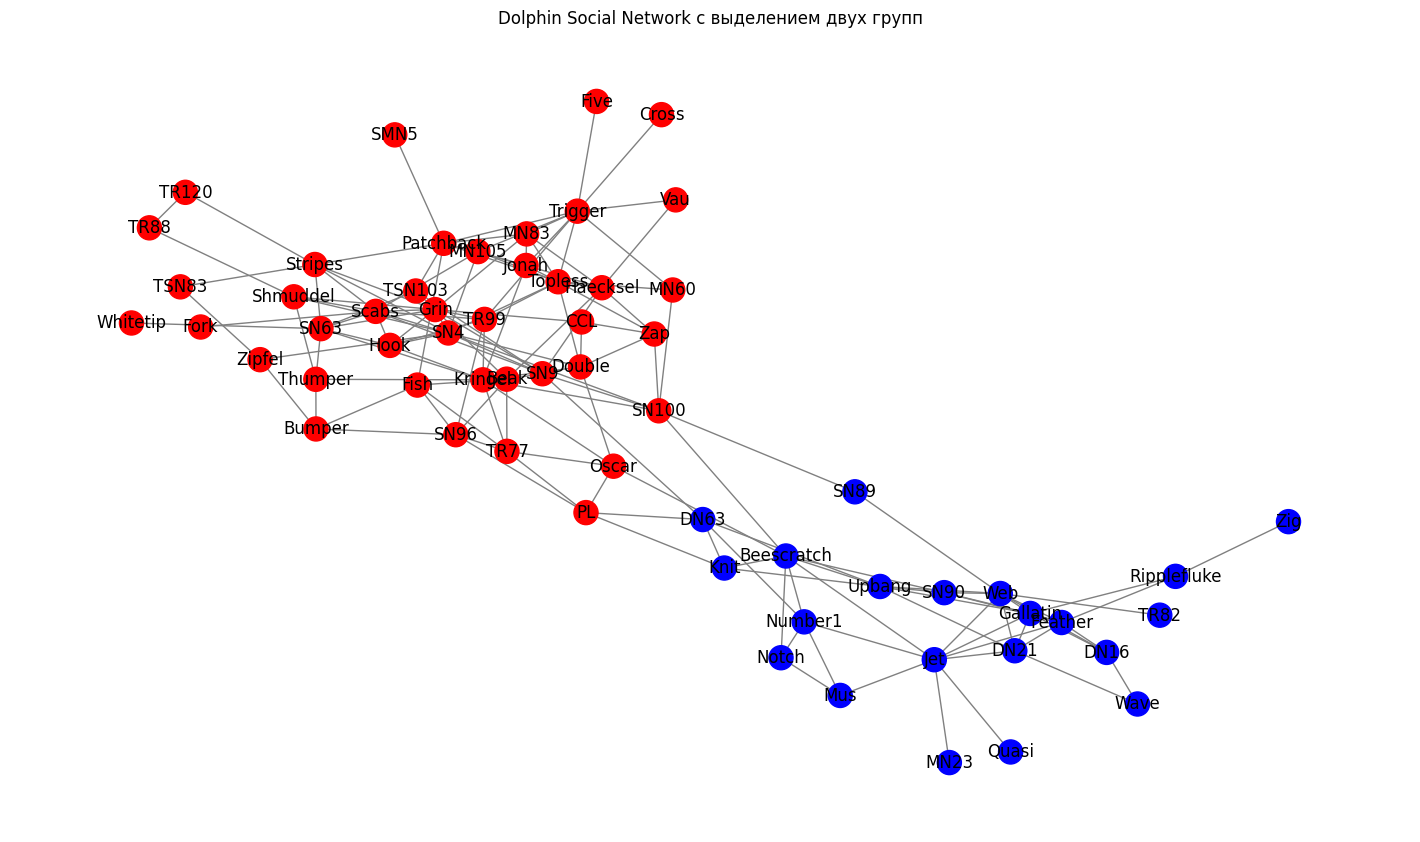

In [26]:
communities = next(girvan_newman(G))
group1, group2 = tuple(communities)

print(f"Размер группы 1: {len(group1)}, Размер группы 2: {len(group2)}")

plt.figure(figsize=(14, 8))
group1_nodes = list(group1)
group2_nodes = list(group2)
colors = ["red" if node in group1 else "blue" for node in G]
nx.draw(G, with_labels=True, node_color=colors, edge_color='gray', node_size=300)
plt.title("Dolphin Social Network с выделением двух групп")
plt.show()

2) Сгенерируем случайные блуждания по графу: для каждого узла выполним несколько блужданий фиксированной длины, где на каждом шаге будем случайно переходить к одному из соседних узлов. Если у текущего узла нет доступных соседей для перехода, то блуждание прерывается раньше. В итоге получится набор последовательностей узлов, которые помогут отразить топологию и структуру графа.

In [30]:
def generate_random_walks(G, num_walks, walk_length):
    '''
    Генерирует случайные блуждания по графу.
    Параметры:
        - G: граф (networkx.Graph)
        - num_walks: количество блужданий для каждого узла
        - walk_length: длина каждого блуждания
    Возвращает:
        Список списков, где каждый вложенный список — это последовательность узлов, пройденных за одно блуждание.
    '''
    walks = []

    for node in G.nodes():
        for _ in range(num_walks):
            walk = [node]
            current_node = node
            for _ in range(walk_length - 1):
                neighbors = list(G.neighbors(current_node))
                if not neighbors:
                    break
                next_node = np.random.choice(neighbors)
                walk.append(next_node)
                current_node = next_node
            walks.append(walk)

    return walks

Построим множества схожих вершин:

In [31]:
num_walks = 10      # Количество блужданий для каждого узла
walk_length = 15     # Длина каждого блуждания
walks = generate_random_walks(G, num_walks, walk_length)

for i, walk in enumerate(walks):
    print(f"Блуждание {i+1}: {walk}")

Блуждание 1: ['Beak', 'Grin', 'TR99', 'SN96', 'Fish', 'Bumper', 'SN96', 'Beak', 'TR77', 'Fish', 'Bumper', 'Zipfel', 'Bumper', 'Fish', 'SN96']
Блуждание 2: ['Beak', 'SN9', 'SN4', 'MN105', 'Jonah', 'Haecksel', 'Zap', 'Double', 'SN4', 'SN100', 'Kringel', 'TR99', 'Topless', 'SN4', 'Zipfel']
Блуждание 3: ['Beak', 'SN9', 'DN63', 'Upbang', 'Knit', 'DN63', 'PL', 'Knit', 'Beescratch', 'Notch', 'Number1', 'Jet', 'Quasi', 'Jet', 'Quasi']
Блуждание 4: ['Beak', 'Haecksel', 'Jonah', 'Kringel', 'Thumper', 'SN63', 'Thumper', 'Shmuddel', 'SN4', 'Stripes', 'Grin', 'MN83', 'Haecksel', 'Jonah', 'MN105']
Блуждание 5: ['Beak', 'Grin', 'SN63', 'TSN103', 'SN9', 'Scabs', 'Hook', 'TR99', 'Grin', 'TR99', 'Grin', 'TR99', 'Trigger', 'TR99', 'Kringel']
Блуждание 6: ['Beak', 'Haecksel', 'Beak', 'Fish', 'Bumper', 'Thumper', 'Bumper', 'Zipfel', 'Bumper', 'Fish', 'SN96', 'PL', 'DN63', 'SN9', 'SN4']
Блуждание 7: ['Beak', 'Fish', 'Bumper', 'Thumper', 'SN63', 'Thumper', 'Shmuddel', 'Grin', 'Stripes', 'TR120', 'Stripes', '

3) Обучим эмбеддинги вершин, используя `SGD` и `negative sampling`:

Сгенерируем список отрицательных рёбер — пар узлов, между которыми нет соединения или которые принадлежат разным сообществам. Эти рёбра используем для обучения модели с негативными примерами, помогая отличать связанные узлы от несвязанных:

In [7]:
def sample_negative_edges(G, group1, group2, num_neg_samples):
    '''
    Генерирует список отрицательных рёбер (рёбра между группами или отсутствующие рёбра).
    Параметры:
        - G: исходный граф
        - group1, group2: множества узлов, принадлежащие разным сообществам
        - num_neg_samples: количество отрицательных рёбер, равное числу положительных рёбер
    Возвращает список отрицательных рёбер.
    '''
    neg_edge_list = []
    pos_set = set(G.edges())

    while len(neg_edge_list) < num_neg_samples:
        u, v = np.random.choice(G.nodes(), 2)
        if u == v or (u, v) in pos_set or (v, u) in pos_set:
            continue
        if (u in group1 and v in group2) or (u in group2 and v in group1):
            neg_edge_list.append((u, v))

    return neg_edge_list

Преобразуем списки положительных и отрицательных рёбер в числовой формат, создавая индексы узлов для дальнейшей работы с фреймворком PyTorch:

In [8]:
def prepare_edge_tensors(G, pos_edge_list, neg_edge_list):
    '''
    Преобразует рёбра в числовой формат для работы с PyTorch.
    Параметры:
        - G: исходный граф
        - pos_edge_list, neg_edge_list: списки положительных и отрицательных рёбер
    Возвращает два тензора рёбер для положительных и отрицательных примеров.
    '''
    node_to_index = {node: i for i, node in enumerate(G.nodes())}

    numerical_pos_edge_list = [
        (node_to_index[u], node_to_index[v]) for u, v in pos_edge_list
    ]
    pos_edge_index = torch.tensor(numerical_pos_edge_list, dtype=torch.long).t().contiguous()

    numerical_neg_edge_list = [
        (node_to_index[u], node_to_index[v]) for u, v in neg_edge_list
    ]
    neg_edge_index = torch.tensor(numerical_neg_edge_list, dtype=torch.long).t().contiguous()

    return pos_edge_index, neg_edge_index

In [9]:
pos_edge_list = [
    (u, v) for u, v in G.edges() if (u in group1 and v in group1) or (u in group2 and v in group2)
]
neg_edge_list = sample_negative_edges(G, group1, group2, len(pos_edge_list))
pos_edge_index, neg_edge_index = prepare_edge_tensors(G, pos_edge_list, neg_edge_list)

print(f"Тензор положительных рёбер имеет форму {pos_edge_index.shape}")
print(f"Тензор отрицательных рёбер имеет форму {neg_edge_index.shape}")

Тензор положительных рёбер имеет форму torch.Size([2, 153])
Тензор отрицательных рёбер имеет форму torch.Size([2, 153])


4) Визуализируем эмбеддинги узлов, используя метод PCA для проекции на 2D-пространство и выделяя два сообщества разными цветами:

In [32]:
def visualize_emb(embedding_layer, G, group1, group2):
    '''
    Визуализирует эмбеддинги узлов с помощью метода PCA, выделяя узлы двух сообществ разными цветами.
    Параметры:
        - embedding_layer: слой эмбеддингов из модели PyTorch (nn.Embedding), который содержит обученные вектора узлов.
        - G: граф (networkx.Graph), представляющий структуру взаимодействий между узлами (дельфинами).
        - group1, group2: списки узлов, принадлежащие двум разным сообществам. Узлы из group1 будут выделены одним цветом, а узлы из group2 — другим.
    '''
    X = embedding_layer.weight.data.numpy()
    pca = PCA(n_components=2)
    components = pca.fit_transform(X)

    plt.figure(figsize=(8, 8))
    group1_x, group1_y = [], []
    group2_x, group2_y = [], []

    for i, node in enumerate(G.nodes()):
        if node in group1:
            group1_x.append(components[i, 0])
            group1_y.append(components[i, 1])
        else:
            group2_x.append(components[i, 0])
            group2_y.append(components[i, 1])

    plt.scatter(group1_x, group1_y, color="red", label="Группа 1")
    plt.scatter(group2_x, group2_y, color="blue", label="Группа 2")
    plt.title("Визуализация эмбеддингов узлов (Dolphin Social Network)")
    plt.legend()
    plt.show()

In [33]:
def train(embedding_layer, train_edge, train_label, loss_fn, optimizer, epochs, G, group1, group2):
    '''
    Выполняет обучение эмбеддингов узлов с визуализацией каждые 50 эпох.
    Параметры:
        - embedding_layer: слой эмбеддингов
        - train_edge: объединённые положительные и отрицательные рёбра
        - train_label: метки рёбер (1 для положительных, 0 для отрицательных)
        - loss_fn: функция потерь
        - optimizer: оптимизатор
        - epochs: количество эпох обучения
        - G: исходный граф
        - group1, group2: множества узлов двух сообществ
    '''
    for epoch in range(epochs):
        optimizer.zero_grad()

        # Извлечение эмбеддингов узлов для каждого рёбра
        emb_u = embedding_layer(train_edge[0])
        emb_v = embedding_layer(train_edge[1])

        # Вычисление скалярного произведения эмбеддингов узлов
        product = torch.sum(torch.mul(emb_u, emb_v), axis=1)

        # Получения вероятности
        pred = sigmoid(product)

        # Вычисление потерь и обновление весов
        loss = loss_fn(pred, train_label)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            if epoch % 50 == 0:
                visualize_emb(embedding_layer, G, group1, group2)
            print(f"Эпоха {epoch + 1}, Потеря: {loss.item():.4f}")

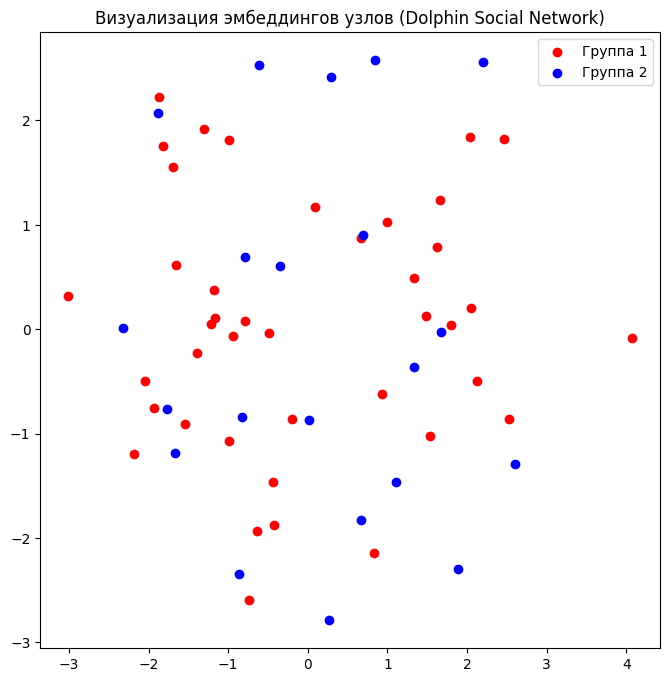

Эпоха 1, Потеря: 1.8242
Эпоха 2, Потеря: 1.8236
Эпоха 3, Потеря: 1.8223
Эпоха 4, Потеря: 1.8205
Эпоха 5, Потеря: 1.8183
Эпоха 6, Потеря: 1.8156
Эпоха 7, Потеря: 1.8125
Эпоха 8, Потеря: 1.8091
Эпоха 9, Потеря: 1.8054
Эпоха 10, Потеря: 1.8014
Эпоха 11, Потеря: 1.7971
Эпоха 12, Потеря: 1.7926
Эпоха 13, Потеря: 1.7880
Эпоха 14, Потеря: 1.7831
Эпоха 15, Потеря: 1.7781
Эпоха 16, Потеря: 1.7730
Эпоха 17, Потеря: 1.7677
Эпоха 18, Потеря: 1.7624
Эпоха 19, Потеря: 1.7569
Эпоха 20, Потеря: 1.7514
Эпоха 21, Потеря: 1.7458
Эпоха 22, Потеря: 1.7401
Эпоха 23, Потеря: 1.7343
Эпоха 24, Потеря: 1.7285
Эпоха 25, Потеря: 1.7227
Эпоха 26, Потеря: 1.7169
Эпоха 27, Потеря: 1.7110
Эпоха 28, Потеря: 1.7051
Эпоха 29, Потеря: 1.6991
Эпоха 30, Потеря: 1.6932
Эпоха 31, Потеря: 1.6872
Эпоха 32, Потеря: 1.6812
Эпоха 33, Потеря: 1.6753
Эпоха 34, Потеря: 1.6693
Эпоха 35, Потеря: 1.6633
Эпоха 36, Потеря: 1.6573
Эпоха 37, Потеря: 1.6513
Эпоха 38, Потеря: 1.6454
Эпоха 39, Потеря: 1.6394
Эпоха 40, Потеря: 1.6334
Эпоха 41,

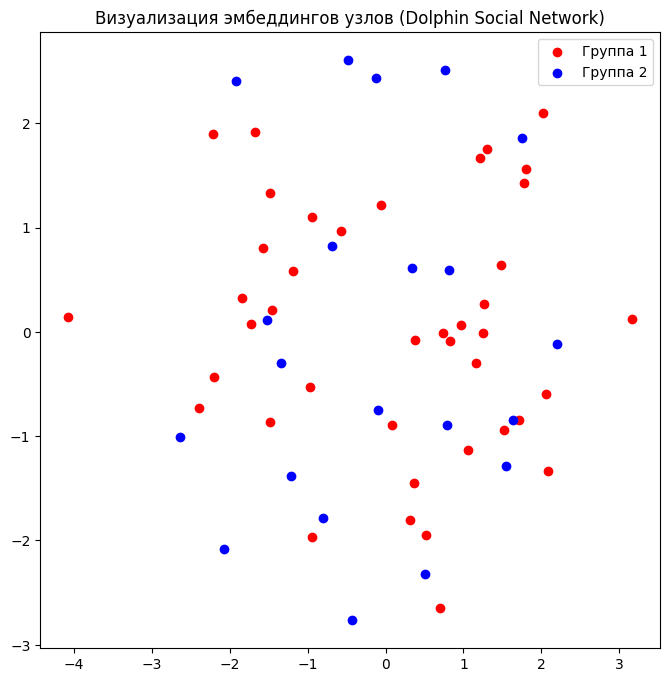

Эпоха 51, Потеря: 1.5687
Эпоха 52, Потеря: 1.5629
Эпоха 53, Потеря: 1.5571
Эпоха 54, Потеря: 1.5513
Эпоха 55, Потеря: 1.5456
Эпоха 56, Потеря: 1.5399
Эпоха 57, Потеря: 1.5341
Эпоха 58, Потеря: 1.5284
Эпоха 59, Потеря: 1.5228
Эпоха 60, Потеря: 1.5171
Эпоха 61, Потеря: 1.5115
Эпоха 62, Потеря: 1.5058
Эпоха 63, Потеря: 1.5002
Эпоха 64, Потеря: 1.4947
Эпоха 65, Потеря: 1.4891
Эпоха 66, Потеря: 1.4836
Эпоха 67, Потеря: 1.4780
Эпоха 68, Потеря: 1.4725
Эпоха 69, Потеря: 1.4670
Эпоха 70, Потеря: 1.4616
Эпоха 71, Потеря: 1.4561
Эпоха 72, Потеря: 1.4507
Эпоха 73, Потеря: 1.4453
Эпоха 74, Потеря: 1.4399
Эпоха 75, Потеря: 1.4345
Эпоха 76, Потеря: 1.4291
Эпоха 77, Потеря: 1.4238
Эпоха 78, Потеря: 1.4185
Эпоха 79, Потеря: 1.4132
Эпоха 80, Потеря: 1.4079
Эпоха 81, Потеря: 1.4027
Эпоха 82, Потеря: 1.3974
Эпоха 83, Потеря: 1.3922
Эпоха 84, Потеря: 1.3870
Эпоха 85, Потеря: 1.3818
Эпоха 86, Потеря: 1.3767
Эпоха 87, Потеря: 1.3715
Эпоха 88, Потеря: 1.3664
Эпоха 89, Потеря: 1.3613
Эпоха 90, Потеря: 1.3562


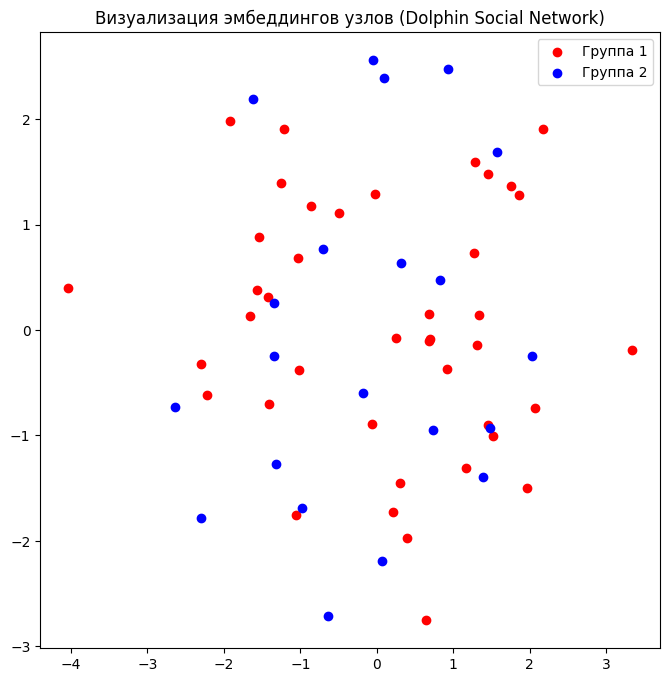

Эпоха 101, Потеря: 1.3015
Эпоха 102, Потеря: 1.2966
Эпоха 103, Потеря: 1.2918
Эпоха 104, Потеря: 1.2870
Эпоха 105, Потеря: 1.2822
Эпоха 106, Потеря: 1.2774
Эпоха 107, Потеря: 1.2726
Эпоха 108, Потеря: 1.2679
Эпоха 109, Потеря: 1.2632
Эпоха 110, Потеря: 1.2584
Эпоха 111, Потеря: 1.2538
Эпоха 112, Потеря: 1.2491
Эпоха 113, Потеря: 1.2444
Эпоха 114, Потеря: 1.2398
Эпоха 115, Потеря: 1.2352
Эпоха 116, Потеря: 1.2306
Эпоха 117, Потеря: 1.2260
Эпоха 118, Потеря: 1.2214
Эпоха 119, Потеря: 1.2169
Эпоха 120, Потеря: 1.2124
Эпоха 121, Потеря: 1.2079
Эпоха 122, Потеря: 1.2034
Эпоха 123, Потеря: 1.1989
Эпоха 124, Потеря: 1.1944
Эпоха 125, Потеря: 1.1900
Эпоха 126, Потеря: 1.1856
Эпоха 127, Потеря: 1.1812
Эпоха 128, Потеря: 1.1768
Эпоха 129, Потеря: 1.1724
Эпоха 130, Потеря: 1.1681
Эпоха 131, Потеря: 1.1638
Эпоха 132, Потеря: 1.1595
Эпоха 133, Потеря: 1.1552
Эпоха 134, Потеря: 1.1509
Эпоха 135, Потеря: 1.1466
Эпоха 136, Потеря: 1.1424
Эпоха 137, Потеря: 1.1382
Эпоха 138, Потеря: 1.1340
Эпоха 139, П

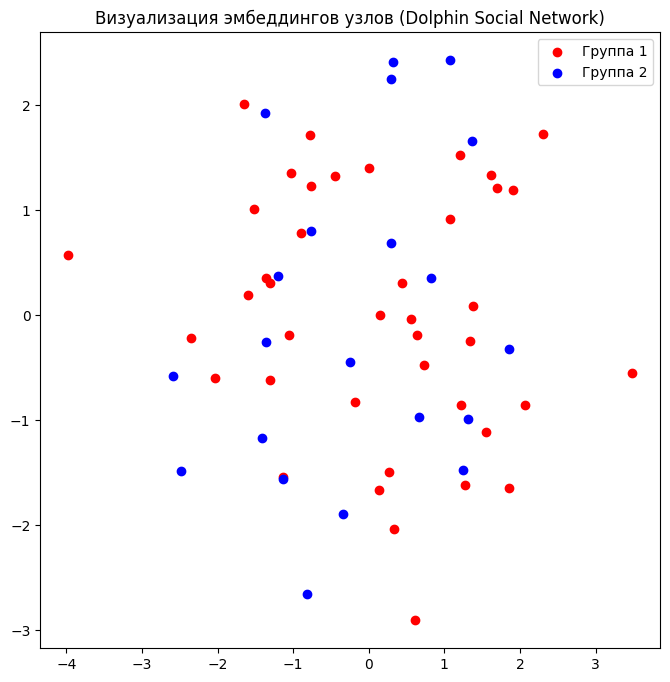

Эпоха 151, Потеря: 1.0809
Эпоха 152, Потеря: 1.0770
Эпоха 153, Потеря: 1.0730
Эпоха 154, Потеря: 1.0691
Эпоха 155, Потеря: 1.0652
Эпоха 156, Потеря: 1.0613
Эпоха 157, Потеря: 1.0574
Эпоха 158, Потеря: 1.0535
Эпоха 159, Потеря: 1.0497
Эпоха 160, Потеря: 1.0459
Эпоха 161, Потеря: 1.0421
Эпоха 162, Потеря: 1.0383
Эпоха 163, Потеря: 1.0345
Эпоха 164, Потеря: 1.0307
Эпоха 165, Потеря: 1.0270
Эпоха 166, Потеря: 1.0233
Эпоха 167, Потеря: 1.0196
Эпоха 168, Потеря: 1.0159
Эпоха 169, Потеря: 1.0122
Эпоха 170, Потеря: 1.0085
Эпоха 171, Потеря: 1.0049
Эпоха 172, Потеря: 1.0013
Эпоха 173, Потеря: 0.9976
Эпоха 174, Потеря: 0.9940
Эпоха 175, Потеря: 0.9905
Эпоха 176, Потеря: 0.9869
Эпоха 177, Потеря: 0.9833
Эпоха 178, Потеря: 0.9798
Эпоха 179, Потеря: 0.9763
Эпоха 180, Потеря: 0.9728
Эпоха 181, Потеря: 0.9693
Эпоха 182, Потеря: 0.9658
Эпоха 183, Потеря: 0.9624
Эпоха 184, Потеря: 0.9589
Эпоха 185, Потеря: 0.9555
Эпоха 186, Потеря: 0.9521
Эпоха 187, Потеря: 0.9487
Эпоха 188, Потеря: 0.9453
Эпоха 189, П

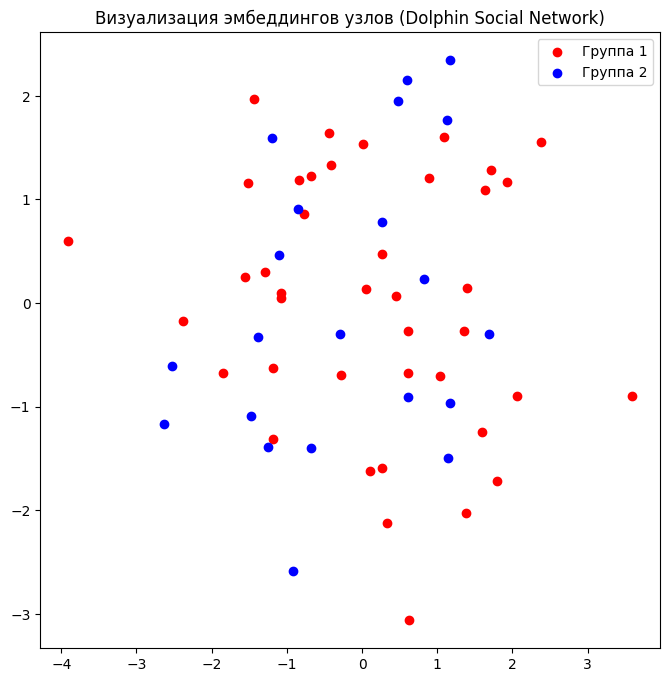

Эпоха 201, Потеря: 0.9027
Эпоха 202, Потеря: 0.8996
Эпоха 203, Потеря: 0.8964
Эпоха 204, Потеря: 0.8932
Эпоха 205, Потеря: 0.8901
Эпоха 206, Потеря: 0.8870
Эпоха 207, Потеря: 0.8839
Эпоха 208, Потеря: 0.8808
Эпоха 209, Потеря: 0.8777
Эпоха 210, Потеря: 0.8747
Эпоха 211, Потеря: 0.8716
Эпоха 212, Потеря: 0.8686
Эпоха 213, Потеря: 0.8656
Эпоха 214, Потеря: 0.8626
Эпоха 215, Потеря: 0.8596
Эпоха 216, Потеря: 0.8566
Эпоха 217, Потеря: 0.8536
Эпоха 218, Потеря: 0.8507
Эпоха 219, Потеря: 0.8477
Эпоха 220, Потеря: 0.8448
Эпоха 221, Потеря: 0.8419
Эпоха 222, Потеря: 0.8390
Эпоха 223, Потеря: 0.8361
Эпоха 224, Потеря: 0.8332
Эпоха 225, Потеря: 0.8303
Эпоха 226, Потеря: 0.8275
Эпоха 227, Потеря: 0.8246
Эпоха 228, Потеря: 0.8218
Эпоха 229, Потеря: 0.8190
Эпоха 230, Потеря: 0.8162
Эпоха 231, Потеря: 0.8134
Эпоха 232, Потеря: 0.8106
Эпоха 233, Потеря: 0.8079
Эпоха 234, Потеря: 0.8051
Эпоха 235, Потеря: 0.8024
Эпоха 236, Потеря: 0.7997
Эпоха 237, Потеря: 0.7969
Эпоха 238, Потеря: 0.7942
Эпоха 239, П

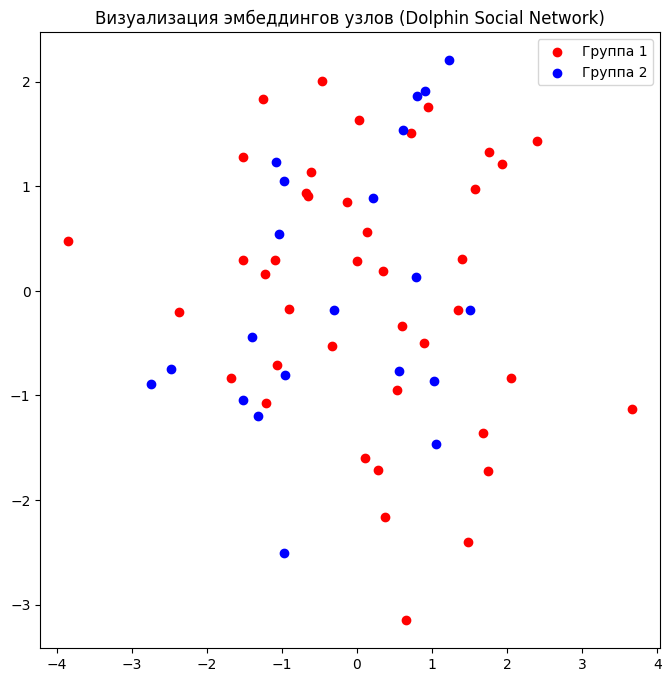

Эпоха 251, Потеря: 0.7602
Эпоха 252, Потеря: 0.7576
Эпоха 253, Потеря: 0.7551
Эпоха 254, Потеря: 0.7526
Эпоха 255, Потеря: 0.7500
Эпоха 256, Потеря: 0.7475
Эпоха 257, Потеря: 0.7451
Эпоха 258, Потеря: 0.7426
Эпоха 259, Потеря: 0.7401
Эпоха 260, Потеря: 0.7377
Эпоха 261, Потеря: 0.7352
Эпоха 262, Потеря: 0.7328
Эпоха 263, Потеря: 0.7304
Эпоха 264, Потеря: 0.7279
Эпоха 265, Потеря: 0.7255
Эпоха 266, Потеря: 0.7231
Эпоха 267, Потеря: 0.7208
Эпоха 268, Потеря: 0.7184
Эпоха 269, Потеря: 0.7160
Эпоха 270, Потеря: 0.7137
Эпоха 271, Потеря: 0.7113
Эпоха 272, Потеря: 0.7090
Эпоха 273, Потеря: 0.7067
Эпоха 274, Потеря: 0.7044
Эпоха 275, Потеря: 0.7021
Эпоха 276, Потеря: 0.6998
Эпоха 277, Потеря: 0.6975
Эпоха 278, Потеря: 0.6952
Эпоха 279, Потеря: 0.6929
Эпоха 280, Потеря: 0.6907
Эпоха 281, Потеря: 0.6884
Эпоха 282, Потеря: 0.6862
Эпоха 283, Потеря: 0.6840
Эпоха 284, Потеря: 0.6818
Эпоха 285, Потеря: 0.6795
Эпоха 286, Потеря: 0.6773
Эпоха 287, Потеря: 0.6752
Эпоха 288, Потеря: 0.6730
Эпоха 289, П

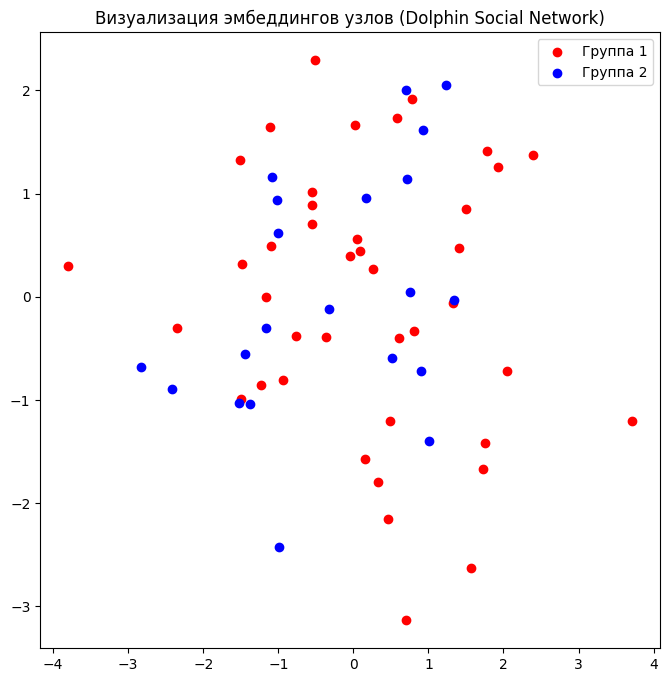

Эпоха 301, Потеря: 0.6455
Эпоха 302, Потеря: 0.6434
Эпоха 303, Потеря: 0.6413
Эпоха 304, Потеря: 0.6393
Эпоха 305, Потеря: 0.6373
Эпоха 306, Потеря: 0.6353
Эпоха 307, Потеря: 0.6332
Эпоха 308, Потеря: 0.6312
Эпоха 309, Потеря: 0.6292
Эпоха 310, Потеря: 0.6273
Эпоха 311, Потеря: 0.6253
Эпоха 312, Потеря: 0.6233
Эпоха 313, Потеря: 0.6213
Эпоха 314, Потеря: 0.6194
Эпоха 315, Потеря: 0.6174
Эпоха 316, Потеря: 0.6155
Эпоха 317, Потеря: 0.6136
Эпоха 318, Потеря: 0.6116
Эпоха 319, Потеря: 0.6097
Эпоха 320, Потеря: 0.6078
Эпоха 321, Потеря: 0.6059
Эпоха 322, Потеря: 0.6040
Эпоха 323, Потеря: 0.6021
Эпоха 324, Потеря: 0.6002
Эпоха 325, Потеря: 0.5984
Эпоха 326, Потеря: 0.5965
Эпоха 327, Потеря: 0.5947
Эпоха 328, Потеря: 0.5928
Эпоха 329, Потеря: 0.5910
Эпоха 330, Потеря: 0.5891
Эпоха 331, Потеря: 0.5873
Эпоха 332, Потеря: 0.5855
Эпоха 333, Потеря: 0.5837
Эпоха 334, Потеря: 0.5819
Эпоха 335, Потеря: 0.5801
Эпоха 336, Потеря: 0.5783
Эпоха 337, Потеря: 0.5765
Эпоха 338, Потеря: 0.5747
Эпоха 339, П

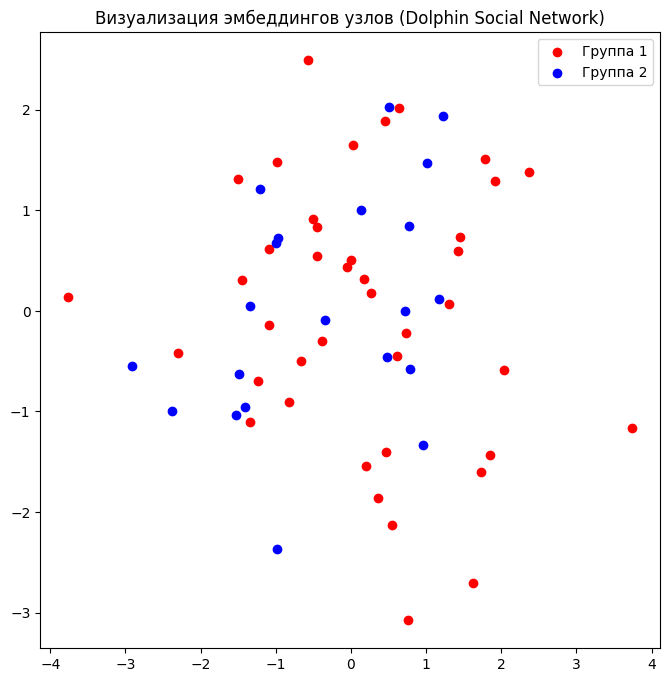

Эпоха 351, Потеря: 0.5523
Эпоха 352, Потеря: 0.5506
Эпоха 353, Потеря: 0.5489
Эпоха 354, Потеря: 0.5473
Эпоха 355, Потеря: 0.5456
Эпоха 356, Потеря: 0.5440
Эпоха 357, Потеря: 0.5423
Эпоха 358, Потеря: 0.5407
Эпоха 359, Потеря: 0.5391
Эпоха 360, Потеря: 0.5374
Эпоха 361, Потеря: 0.5358
Эпоха 362, Потеря: 0.5342
Эпоха 363, Потеря: 0.5326
Эпоха 364, Потеря: 0.5310
Эпоха 365, Потеря: 0.5294
Эпоха 366, Потеря: 0.5278
Эпоха 367, Потеря: 0.5262
Эпоха 368, Потеря: 0.5246
Эпоха 369, Потеря: 0.5231
Эпоха 370, Потеря: 0.5215
Эпоха 371, Потеря: 0.5200
Эпоха 372, Потеря: 0.5184
Эпоха 373, Потеря: 0.5169
Эпоха 374, Потеря: 0.5153
Эпоха 375, Потеря: 0.5138
Эпоха 376, Потеря: 0.5123
Эпоха 377, Потеря: 0.5107
Эпоха 378, Потеря: 0.5092
Эпоха 379, Потеря: 0.5077
Эпоха 380, Потеря: 0.5062
Эпоха 381, Потеря: 0.5047
Эпоха 382, Потеря: 0.5032
Эпоха 383, Потеря: 0.5017
Эпоха 384, Потеря: 0.5003
Эпоха 385, Потеря: 0.4988
Эпоха 386, Потеря: 0.4973
Эпоха 387, Потеря: 0.4958
Эпоха 388, Потеря: 0.4944
Эпоха 389, П

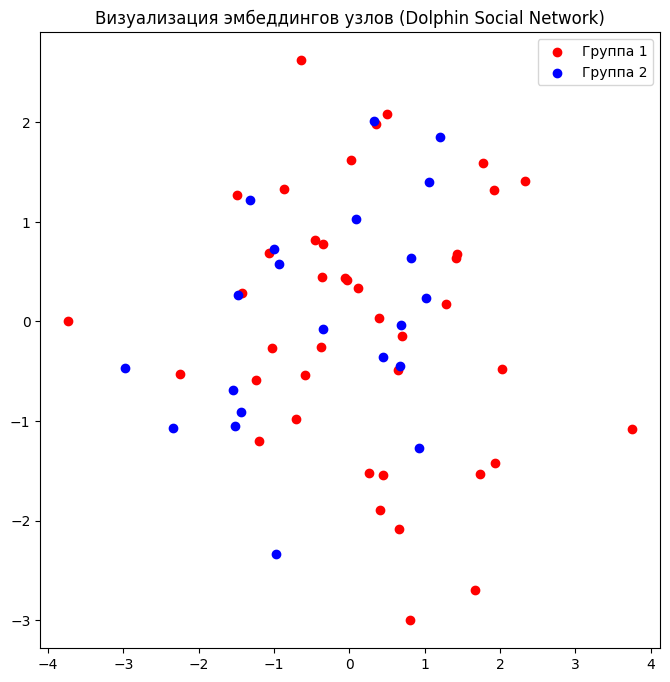

Эпоха 401, Потеря: 0.4759
Эпоха 402, Потеря: 0.4745
Эпоха 403, Потеря: 0.4732
Эпоха 404, Потеря: 0.4718
Эпоха 405, Потеря: 0.4704
Эпоха 406, Потеря: 0.4691
Эпоха 407, Потеря: 0.4677
Эпоха 408, Потеря: 0.4664
Эпоха 409, Потеря: 0.4650
Эпоха 410, Потеря: 0.4637
Эпоха 411, Потеря: 0.4623
Эпоха 412, Потеря: 0.4610
Эпоха 413, Потеря: 0.4597
Эпоха 414, Потеря: 0.4584
Эпоха 415, Потеря: 0.4570
Эпоха 416, Потеря: 0.4557
Эпоха 417, Потеря: 0.4544
Эпоха 418, Потеря: 0.4531
Эпоха 419, Потеря: 0.4518
Эпоха 420, Потеря: 0.4505
Эпоха 421, Потеря: 0.4492
Эпоха 422, Потеря: 0.4480
Эпоха 423, Потеря: 0.4467
Эпоха 424, Потеря: 0.4454
Эпоха 425, Потеря: 0.4441
Эпоха 426, Потеря: 0.4429
Эпоха 427, Потеря: 0.4416
Эпоха 428, Потеря: 0.4404
Эпоха 429, Потеря: 0.4391
Эпоха 430, Потеря: 0.4379
Эпоха 431, Потеря: 0.4366
Эпоха 432, Потеря: 0.4354
Эпоха 433, Потеря: 0.4341
Эпоха 434, Потеря: 0.4329
Эпоха 435, Потеря: 0.4317
Эпоха 436, Потеря: 0.4305
Эпоха 437, Потеря: 0.4293
Эпоха 438, Потеря: 0.4280
Эпоха 439, П

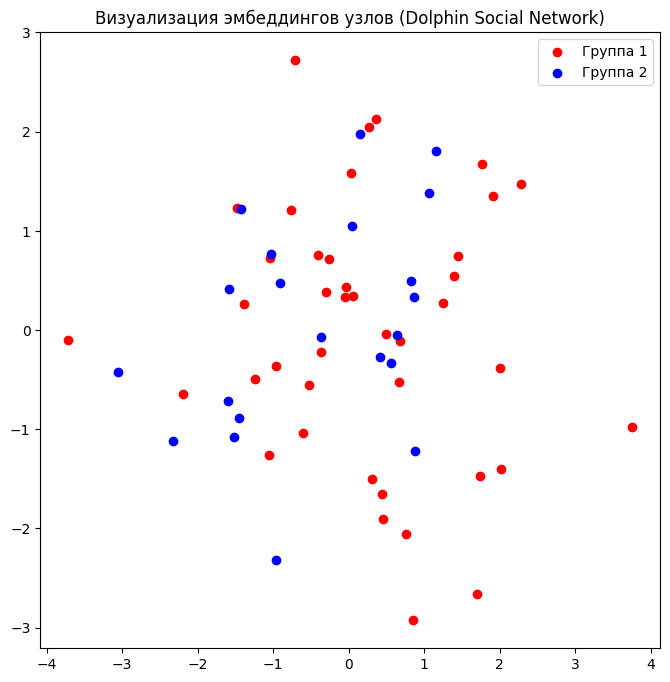

Эпоха 451, Потеря: 0.4127
Эпоха 452, Потеря: 0.4116
Эпоха 453, Потеря: 0.4104
Эпоха 454, Потеря: 0.4093
Эпоха 455, Потеря: 0.4081
Эпоха 456, Потеря: 0.4070
Эпоха 457, Потеря: 0.4059
Эпоха 458, Потеря: 0.4047
Эпоха 459, Потеря: 0.4036
Эпоха 460, Потеря: 0.4025
Эпоха 461, Потеря: 0.4014
Эпоха 462, Потеря: 0.4003
Эпоха 463, Потеря: 0.3992
Эпоха 464, Потеря: 0.3981
Эпоха 465, Потеря: 0.3970
Эпоха 466, Потеря: 0.3959
Эпоха 467, Потеря: 0.3948
Эпоха 468, Потеря: 0.3937
Эпоха 469, Потеря: 0.3926
Эпоха 470, Потеря: 0.3915
Эпоха 471, Потеря: 0.3904
Эпоха 472, Потеря: 0.3894
Эпоха 473, Потеря: 0.3883
Эпоха 474, Потеря: 0.3872
Эпоха 475, Потеря: 0.3862
Эпоха 476, Потеря: 0.3851
Эпоха 477, Потеря: 0.3841
Эпоха 478, Потеря: 0.3830
Эпоха 479, Потеря: 0.3820
Эпоха 480, Потеря: 0.3809
Эпоха 481, Потеря: 0.3799
Эпоха 482, Потеря: 0.3788
Эпоха 483, Потеря: 0.3778
Эпоха 484, Потеря: 0.3768
Эпоха 485, Потеря: 0.3757
Эпоха 486, Потеря: 0.3747
Эпоха 487, Потеря: 0.3737
Эпоха 488, Потеря: 0.3727
Эпоха 489, П

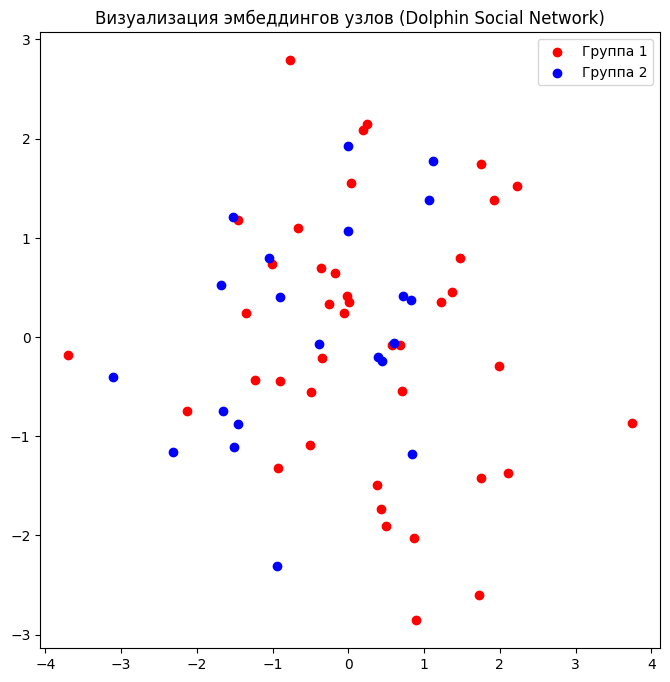

Эпоха 501, Потеря: 0.3598
Эпоха 502, Потеря: 0.3588
Эпоха 503, Потеря: 0.3579
Эпоха 504, Потеря: 0.3569
Эпоха 505, Потеря: 0.3559
Эпоха 506, Потеря: 0.3550
Эпоха 507, Потеря: 0.3540
Эпоха 508, Потеря: 0.3531
Эпоха 509, Потеря: 0.3521
Эпоха 510, Потеря: 0.3512
Эпоха 511, Потеря: 0.3502
Эпоха 512, Потеря: 0.3493
Эпоха 513, Потеря: 0.3484
Эпоха 514, Потеря: 0.3474
Эпоха 515, Потеря: 0.3465
Эпоха 516, Потеря: 0.3456
Эпоха 517, Потеря: 0.3447
Эпоха 518, Потеря: 0.3438
Эпоха 519, Потеря: 0.3428
Эпоха 520, Потеря: 0.3419
Эпоха 521, Потеря: 0.3410
Эпоха 522, Потеря: 0.3401
Эпоха 523, Потеря: 0.3392
Эпоха 524, Потеря: 0.3383
Эпоха 525, Потеря: 0.3374
Эпоха 526, Потеря: 0.3365
Эпоха 527, Потеря: 0.3356
Эпоха 528, Потеря: 0.3347
Эпоха 529, Потеря: 0.3338
Эпоха 530, Потеря: 0.3330
Эпоха 531, Потеря: 0.3321
Эпоха 532, Потеря: 0.3312
Эпоха 533, Потеря: 0.3303
Эпоха 534, Потеря: 0.3295
Эпоха 535, Потеря: 0.3286
Эпоха 536, Потеря: 0.3277
Эпоха 537, Потеря: 0.3269
Эпоха 538, Потеря: 0.3260
Эпоха 539, П

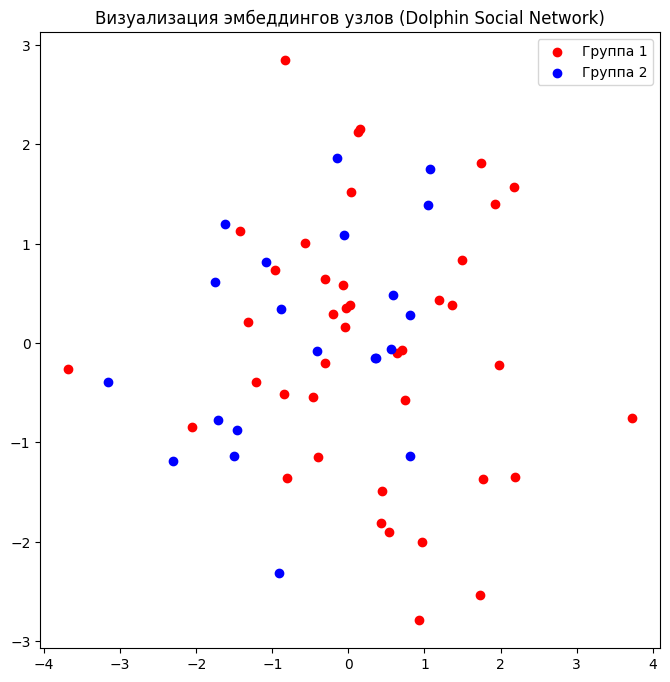

Эпоха 551, Потеря: 0.3151
Эпоха 552, Потеря: 0.3142
Эпоха 553, Потеря: 0.3134
Эпоха 554, Потеря: 0.3126
Эпоха 555, Потеря: 0.3118
Эпоха 556, Потеря: 0.3110
Эпоха 557, Потеря: 0.3102
Эпоха 558, Потеря: 0.3093
Эпоха 559, Потеря: 0.3085
Эпоха 560, Потеря: 0.3077
Эпоха 561, Потеря: 0.3069
Эпоха 562, Потеря: 0.3061
Эпоха 563, Потеря: 0.3053
Эпоха 564, Потеря: 0.3045
Эпоха 565, Потеря: 0.3038
Эпоха 566, Потеря: 0.3030
Эпоха 567, Потеря: 0.3022
Эпоха 568, Потеря: 0.3014
Эпоха 569, Потеря: 0.3006
Эпоха 570, Потеря: 0.2998
Эпоха 571, Потеря: 0.2991
Эпоха 572, Потеря: 0.2983
Эпоха 573, Потеря: 0.2975
Эпоха 574, Потеря: 0.2968
Эпоха 575, Потеря: 0.2960
Эпоха 576, Потеря: 0.2952
Эпоха 577, Потеря: 0.2945
Эпоха 578, Потеря: 0.2937
Эпоха 579, Потеря: 0.2929
Эпоха 580, Потеря: 0.2922
Эпоха 581, Потеря: 0.2914
Эпоха 582, Потеря: 0.2907
Эпоха 583, Потеря: 0.2899
Эпоха 584, Потеря: 0.2892
Эпоха 585, Потеря: 0.2885
Эпоха 586, Потеря: 0.2877
Эпоха 587, Потеря: 0.2870
Эпоха 588, Потеря: 0.2862
Эпоха 589, П

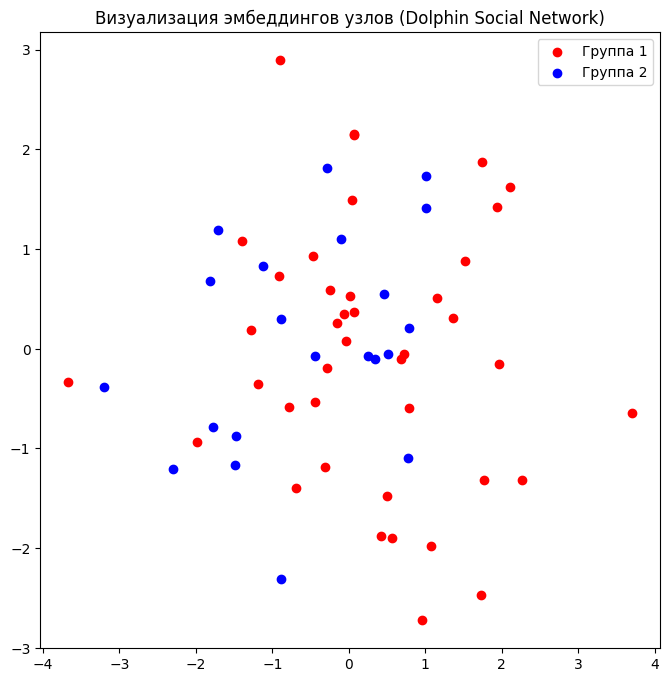

Эпоха 601, Потеря: 0.2769
Эпоха 602, Потеря: 0.2762
Эпоха 603, Потеря: 0.2755
Эпоха 604, Потеря: 0.2748
Эпоха 605, Потеря: 0.2741
Эпоха 606, Потеря: 0.2734
Эпоха 607, Потеря: 0.2727
Эпоха 608, Потеря: 0.2720
Эпоха 609, Потеря: 0.2713
Эпоха 610, Потеря: 0.2706
Эпоха 611, Потеря: 0.2699
Эпоха 612, Потеря: 0.2692
Эпоха 613, Потеря: 0.2685
Эпоха 614, Потеря: 0.2679
Эпоха 615, Потеря: 0.2672
Эпоха 616, Потеря: 0.2665
Эпоха 617, Потеря: 0.2658
Эпоха 618, Потеря: 0.2652
Эпоха 619, Потеря: 0.2645
Эпоха 620, Потеря: 0.2638
Эпоха 621, Потеря: 0.2632
Эпоха 622, Потеря: 0.2625
Эпоха 623, Потеря: 0.2618
Эпоха 624, Потеря: 0.2612
Эпоха 625, Потеря: 0.2605
Эпоха 626, Потеря: 0.2599
Эпоха 627, Потеря: 0.2592
Эпоха 628, Потеря: 0.2586
Эпоха 629, Потеря: 0.2579
Эпоха 630, Потеря: 0.2573
Эпоха 631, Потеря: 0.2566
Эпоха 632, Потеря: 0.2560
Эпоха 633, Потеря: 0.2553
Эпоха 634, Потеря: 0.2547
Эпоха 635, Потеря: 0.2540
Эпоха 636, Потеря: 0.2534
Эпоха 637, Потеря: 0.2528
Эпоха 638, Потеря: 0.2521
Эпоха 639, П

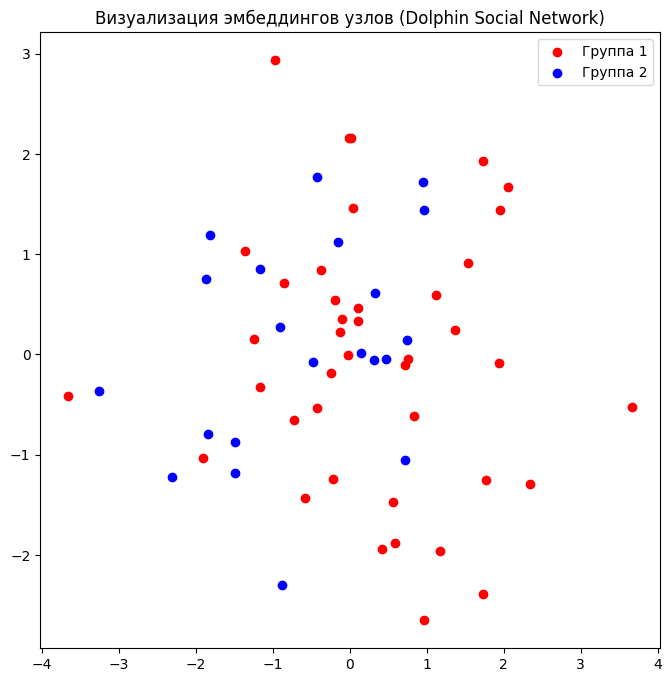

Эпоха 651, Потеря: 0.2441
Эпоха 652, Потеря: 0.2435
Эпоха 653, Потеря: 0.2429
Эпоха 654, Потеря: 0.2423
Эпоха 655, Потеря: 0.2417
Эпоха 656, Потеря: 0.2411
Эпоха 657, Потеря: 0.2405
Эпоха 658, Потеря: 0.2399
Эпоха 659, Потеря: 0.2393
Эпоха 660, Потеря: 0.2387
Эпоха 661, Потеря: 0.2381
Эпоха 662, Потеря: 0.2375
Эпоха 663, Потеря: 0.2369
Эпоха 664, Потеря: 0.2363
Эпоха 665, Потеря: 0.2357
Эпоха 666, Потеря: 0.2351
Эпоха 667, Потеря: 0.2346
Эпоха 668, Потеря: 0.2340
Эпоха 669, Потеря: 0.2334
Эпоха 670, Потеря: 0.2328
Эпоха 671, Потеря: 0.2323
Эпоха 672, Потеря: 0.2317
Эпоха 673, Потеря: 0.2311
Эпоха 674, Потеря: 0.2305
Эпоха 675, Потеря: 0.2300
Эпоха 676, Потеря: 0.2294
Эпоха 677, Потеря: 0.2288
Эпоха 678, Потеря: 0.2283
Эпоха 679, Потеря: 0.2277
Эпоха 680, Потеря: 0.2272
Эпоха 681, Потеря: 0.2266
Эпоха 682, Потеря: 0.2260
Эпоха 683, Потеря: 0.2255
Эпоха 684, Потеря: 0.2249
Эпоха 685, Потеря: 0.2244
Эпоха 686, Потеря: 0.2238
Эпоха 687, Потеря: 0.2233
Эпоха 688, Потеря: 0.2227
Эпоха 689, П

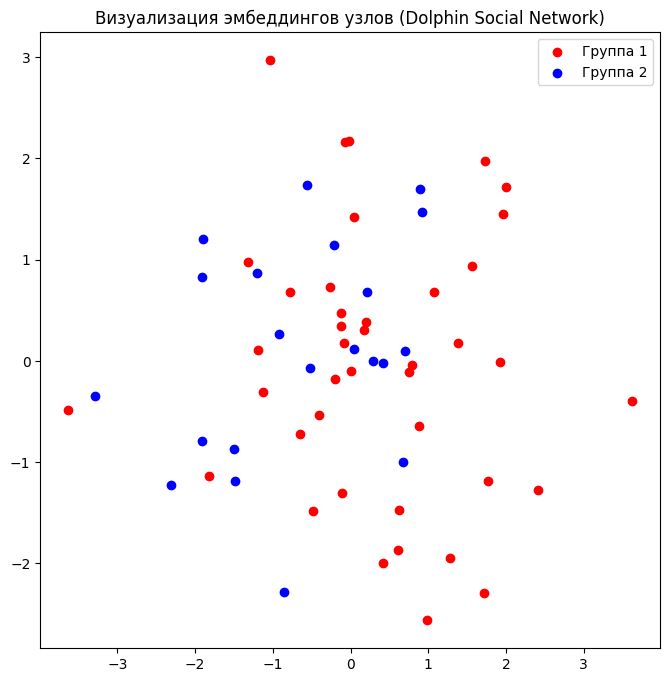

Эпоха 701, Потеря: 0.2158
Эпоха 702, Потеря: 0.2153
Эпоха 703, Потеря: 0.2147
Эпоха 704, Потеря: 0.2142
Эпоха 705, Потеря: 0.2137
Эпоха 706, Потеря: 0.2132
Эпоха 707, Потеря: 0.2127
Эпоха 708, Потеря: 0.2121
Эпоха 709, Потеря: 0.2116
Эпоха 710, Потеря: 0.2111
Эпоха 711, Потеря: 0.2106
Эпоха 712, Потеря: 0.2101
Эпоха 713, Потеря: 0.2096
Эпоха 714, Потеря: 0.2091
Эпоха 715, Потеря: 0.2086
Эпоха 716, Потеря: 0.2081
Эпоха 717, Потеря: 0.2076
Эпоха 718, Потеря: 0.2071
Эпоха 719, Потеря: 0.2066
Эпоха 720, Потеря: 0.2061
Эпоха 721, Потеря: 0.2056
Эпоха 722, Потеря: 0.2051
Эпоха 723, Потеря: 0.2046
Эпоха 724, Потеря: 0.2041
Эпоха 725, Потеря: 0.2036
Эпоха 726, Потеря: 0.2031
Эпоха 727, Потеря: 0.2026
Эпоха 728, Потеря: 0.2022
Эпоха 729, Потеря: 0.2017
Эпоха 730, Потеря: 0.2012
Эпоха 731, Потеря: 0.2007
Эпоха 732, Потеря: 0.2002
Эпоха 733, Потеря: 0.1997
Эпоха 734, Потеря: 0.1993
Эпоха 735, Потеря: 0.1988
Эпоха 736, Потеря: 0.1983
Эпоха 737, Потеря: 0.1978
Эпоха 738, Потеря: 0.1974
Эпоха 739, П

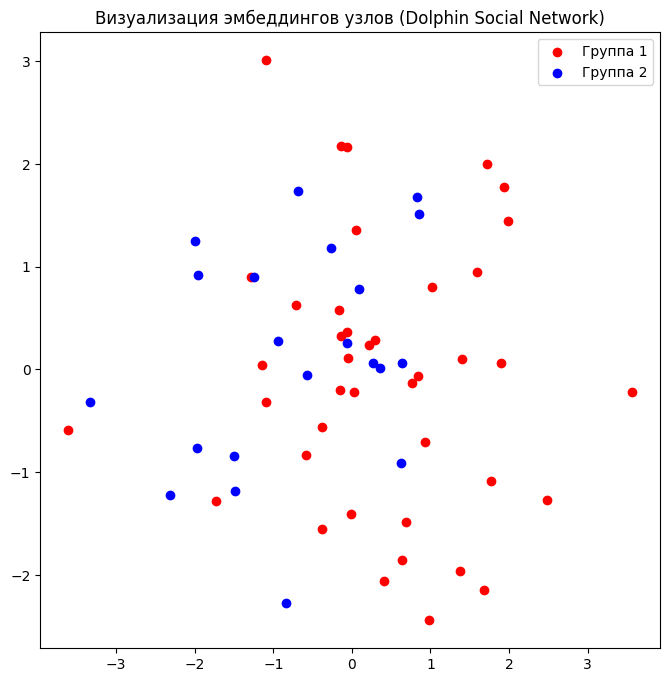

Эпоха 751, Потеря: 0.1914
Эпоха 752, Потеря: 0.1909
Эпоха 753, Потеря: 0.1905
Эпоха 754, Потеря: 0.1900
Эпоха 755, Потеря: 0.1896
Эпоха 756, Потеря: 0.1891
Эпоха 757, Потеря: 0.1887
Эпоха 758, Потеря: 0.1882
Эпоха 759, Потеря: 0.1878
Эпоха 760, Потеря: 0.1873
Эпоха 761, Потеря: 0.1869
Эпоха 762, Потеря: 0.1865
Эпоха 763, Потеря: 0.1860
Эпоха 764, Потеря: 0.1856
Эпоха 765, Потеря: 0.1852
Эпоха 766, Потеря: 0.1847
Эпоха 767, Потеря: 0.1843
Эпоха 768, Потеря: 0.1839
Эпоха 769, Потеря: 0.1834
Эпоха 770, Потеря: 0.1830
Эпоха 771, Потеря: 0.1826
Эпоха 772, Потеря: 0.1822
Эпоха 773, Потеря: 0.1817
Эпоха 774, Потеря: 0.1813
Эпоха 775, Потеря: 0.1809
Эпоха 776, Потеря: 0.1805
Эпоха 777, Потеря: 0.1800
Эпоха 778, Потеря: 0.1796
Эпоха 779, Потеря: 0.1792
Эпоха 780, Потеря: 0.1788
Эпоха 781, Потеря: 0.1784
Эпоха 782, Потеря: 0.1780
Эпоха 783, Потеря: 0.1776
Эпоха 784, Потеря: 0.1771
Эпоха 785, Потеря: 0.1767
Эпоха 786, Потеря: 0.1763
Эпоха 787, Потеря: 0.1759
Эпоха 788, Потеря: 0.1755
Эпоха 789, П

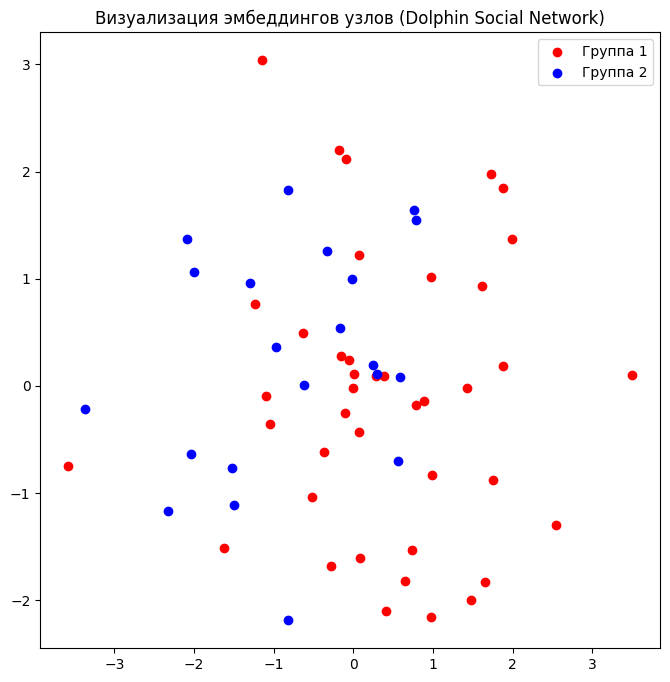

Эпоха 801, Потеря: 0.1704
Эпоха 802, Потеря: 0.1700
Эпоха 803, Потеря: 0.1696
Эпоха 804, Потеря: 0.1692
Эпоха 805, Потеря: 0.1688
Эпоха 806, Потеря: 0.1684
Эпоха 807, Потеря: 0.1680
Эпоха 808, Потеря: 0.1677
Эпоха 809, Потеря: 0.1673
Эпоха 810, Потеря: 0.1669
Эпоха 811, Потеря: 0.1665
Эпоха 812, Потеря: 0.1661
Эпоха 813, Потеря: 0.1658
Эпоха 814, Потеря: 0.1654
Эпоха 815, Потеря: 0.1650
Эпоха 816, Потеря: 0.1646
Эпоха 817, Потеря: 0.1643
Эпоха 818, Потеря: 0.1639
Эпоха 819, Потеря: 0.1635
Эпоха 820, Потеря: 0.1632
Эпоха 821, Потеря: 0.1628
Эпоха 822, Потеря: 0.1624
Эпоха 823, Потеря: 0.1621
Эпоха 824, Потеря: 0.1617
Эпоха 825, Потеря: 0.1613
Эпоха 826, Потеря: 0.1610
Эпоха 827, Потеря: 0.1606
Эпоха 828, Потеря: 0.1603
Эпоха 829, Потеря: 0.1599
Эпоха 830, Потеря: 0.1596
Эпоха 831, Потеря: 0.1592
Эпоха 832, Потеря: 0.1588
Эпоха 833, Потеря: 0.1585
Эпоха 834, Потеря: 0.1581
Эпоха 835, Потеря: 0.1578
Эпоха 836, Потеря: 0.1574
Эпоха 837, Потеря: 0.1571
Эпоха 838, Потеря: 0.1567
Эпоха 839, П

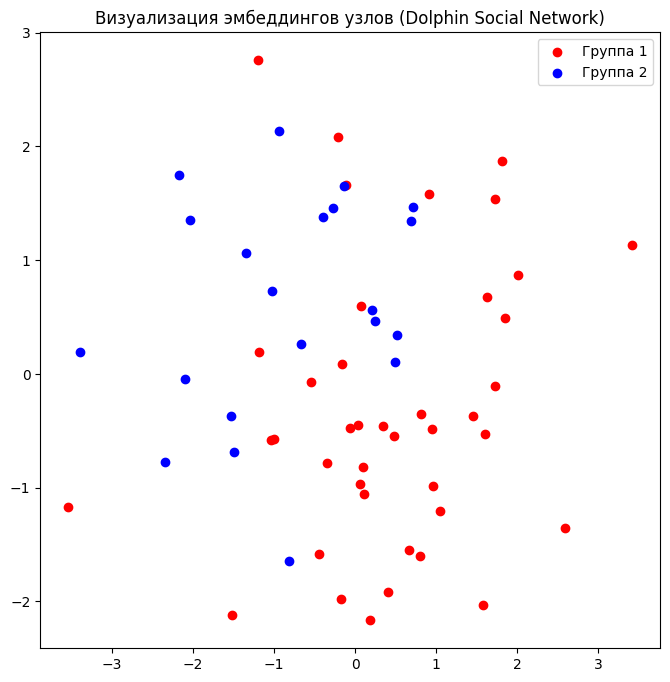

Эпоха 851, Потеря: 0.1523
Эпоха 852, Потеря: 0.1520
Эпоха 853, Потеря: 0.1516
Эпоха 854, Потеря: 0.1513
Эпоха 855, Потеря: 0.1510
Эпоха 856, Потеря: 0.1507
Эпоха 857, Потеря: 0.1503
Эпоха 858, Потеря: 0.1500
Эпоха 859, Потеря: 0.1497
Эпоха 860, Потеря: 0.1494
Эпоха 861, Потеря: 0.1490
Эпоха 862, Потеря: 0.1487
Эпоха 863, Потеря: 0.1484
Эпоха 864, Потеря: 0.1481
Эпоха 865, Потеря: 0.1477
Эпоха 866, Потеря: 0.1474
Эпоха 867, Потеря: 0.1471
Эпоха 868, Потеря: 0.1468
Эпоха 869, Потеря: 0.1465
Эпоха 870, Потеря: 0.1462
Эпоха 871, Потеря: 0.1458
Эпоха 872, Потеря: 0.1455
Эпоха 873, Потеря: 0.1452
Эпоха 874, Потеря: 0.1449
Эпоха 875, Потеря: 0.1446
Эпоха 876, Потеря: 0.1443
Эпоха 877, Потеря: 0.1440
Эпоха 878, Потеря: 0.1437
Эпоха 879, Потеря: 0.1434
Эпоха 880, Потеря: 0.1431
Эпоха 881, Потеря: 0.1428
Эпоха 882, Потеря: 0.1425
Эпоха 883, Потеря: 0.1422
Эпоха 884, Потеря: 0.1419
Эпоха 885, Потеря: 0.1416
Эпоха 886, Потеря: 0.1413
Эпоха 887, Потеря: 0.1410
Эпоха 888, Потеря: 0.1407
Эпоха 889, П

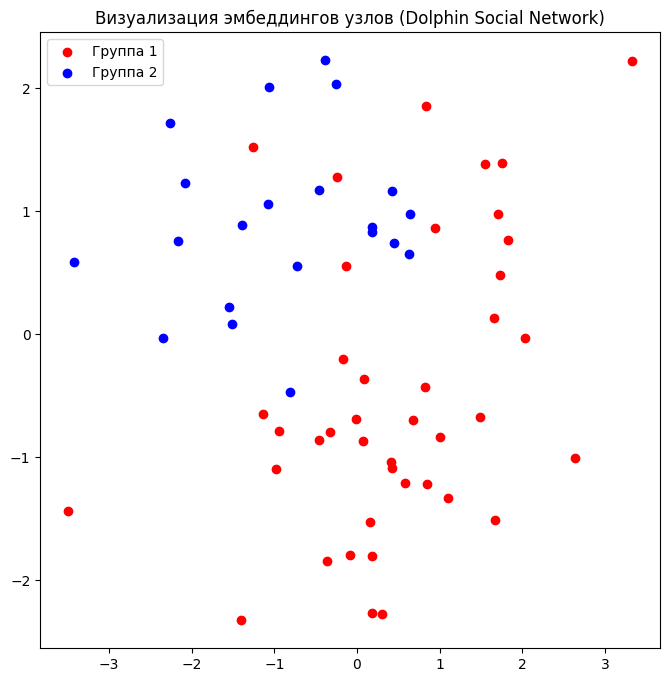

Эпоха 901, Потеря: 0.1369
Эпоха 902, Потеря: 0.1366
Эпоха 903, Потеря: 0.1363
Эпоха 904, Потеря: 0.1360
Эпоха 905, Потеря: 0.1357
Эпоха 906, Потеря: 0.1355
Эпоха 907, Потеря: 0.1352
Эпоха 908, Потеря: 0.1349
Эпоха 909, Потеря: 0.1346
Эпоха 910, Потеря: 0.1343
Эпоха 911, Потеря: 0.1341
Эпоха 912, Потеря: 0.1338
Эпоха 913, Потеря: 0.1335
Эпоха 914, Потеря: 0.1332
Эпоха 915, Потеря: 0.1330
Эпоха 916, Потеря: 0.1327
Эпоха 917, Потеря: 0.1324
Эпоха 918, Потеря: 0.1322
Эпоха 919, Потеря: 0.1319
Эпоха 920, Потеря: 0.1316
Эпоха 921, Потеря: 0.1313
Эпоха 922, Потеря: 0.1311
Эпоха 923, Потеря: 0.1308
Эпоха 924, Потеря: 0.1305
Эпоха 925, Потеря: 0.1303
Эпоха 926, Потеря: 0.1300
Эпоха 927, Потеря: 0.1298
Эпоха 928, Потеря: 0.1295
Эпоха 929, Потеря: 0.1292
Эпоха 930, Потеря: 0.1290
Эпоха 931, Потеря: 0.1287
Эпоха 932, Потеря: 0.1285
Эпоха 933, Потеря: 0.1282
Эпоха 934, Потеря: 0.1279
Эпоха 935, Потеря: 0.1277
Эпоха 936, Потеря: 0.1274
Эпоха 937, Потеря: 0.1272
Эпоха 938, Потеря: 0.1269
Эпоха 939, П

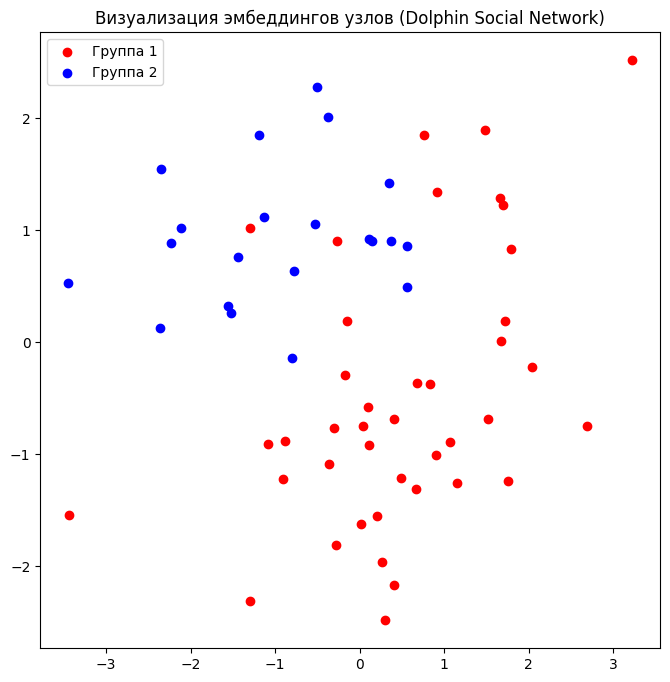

Эпоха 951, Потеря: 0.1237
Эпоха 952, Потеря: 0.1234
Эпоха 953, Потеря: 0.1232
Эпоха 954, Потеря: 0.1230
Эпоха 955, Потеря: 0.1227
Эпоха 956, Потеря: 0.1225
Эпоха 957, Потеря: 0.1222
Эпоха 958, Потеря: 0.1220
Эпоха 959, Потеря: 0.1218
Эпоха 960, Потеря: 0.1215
Эпоха 961, Потеря: 0.1213
Эпоха 962, Потеря: 0.1211
Эпоха 963, Потеря: 0.1208
Эпоха 964, Потеря: 0.1206
Эпоха 965, Потеря: 0.1203
Эпоха 966, Потеря: 0.1201
Эпоха 967, Потеря: 0.1199
Эпоха 968, Потеря: 0.1197
Эпоха 969, Потеря: 0.1194
Эпоха 970, Потеря: 0.1192
Эпоха 971, Потеря: 0.1190
Эпоха 972, Потеря: 0.1187
Эпоха 973, Потеря: 0.1185
Эпоха 974, Потеря: 0.1183
Эпоха 975, Потеря: 0.1181
Эпоха 976, Потеря: 0.1178
Эпоха 977, Потеря: 0.1176
Эпоха 978, Потеря: 0.1174
Эпоха 979, Потеря: 0.1172
Эпоха 980, Потеря: 0.1169
Эпоха 981, Потеря: 0.1167
Эпоха 982, Потеря: 0.1165
Эпоха 983, Потеря: 0.1163
Эпоха 984, Потеря: 0.1161
Эпоха 985, Потеря: 0.1158
Эпоха 986, Потеря: 0.1156
Эпоха 987, Потеря: 0.1154
Эпоха 988, Потеря: 0.1152
Эпоха 989, П

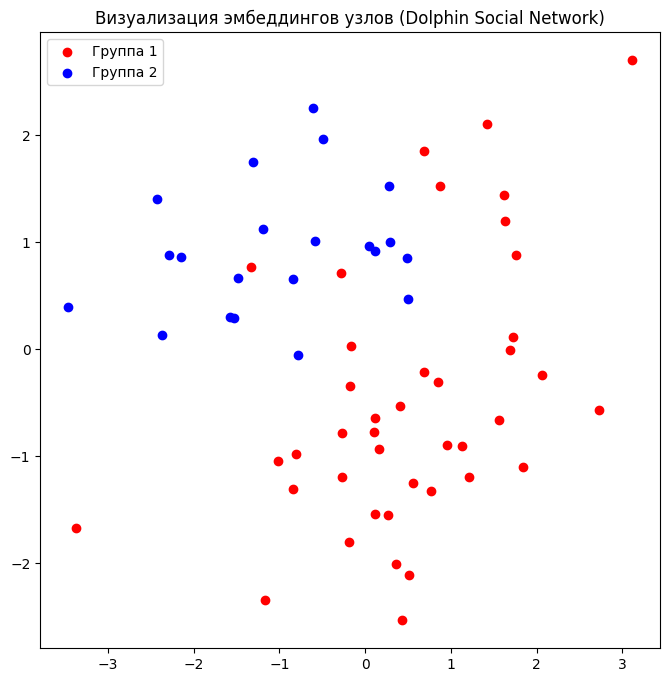

Эпоха 1001, Потеря: 0.1124
Эпоха 1002, Потеря: 0.1122
Эпоха 1003, Потеря: 0.1120
Эпоха 1004, Потеря: 0.1118
Эпоха 1005, Потеря: 0.1116
Эпоха 1006, Потеря: 0.1114
Эпоха 1007, Потеря: 0.1112
Эпоха 1008, Потеря: 0.1110
Эпоха 1009, Потеря: 0.1108
Эпоха 1010, Потеря: 0.1106
Эпоха 1011, Потеря: 0.1104
Эпоха 1012, Потеря: 0.1102
Эпоха 1013, Потеря: 0.1100
Эпоха 1014, Потеря: 0.1098
Эпоха 1015, Потеря: 0.1096
Эпоха 1016, Потеря: 0.1094
Эпоха 1017, Потеря: 0.1092
Эпоха 1018, Потеря: 0.1090
Эпоха 1019, Потеря: 0.1088
Эпоха 1020, Потеря: 0.1086
Эпоха 1021, Потеря: 0.1084
Эпоха 1022, Потеря: 0.1082
Эпоха 1023, Потеря: 0.1080
Эпоха 1024, Потеря: 0.1078
Эпоха 1025, Потеря: 0.1076
Эпоха 1026, Потеря: 0.1074
Эпоха 1027, Потеря: 0.1072
Эпоха 1028, Потеря: 0.1070
Эпоха 1029, Потеря: 0.1068
Эпоха 1030, Потеря: 0.1066
Эпоха 1031, Потеря: 0.1064
Эпоха 1032, Потеря: 0.1063
Эпоха 1033, Потеря: 0.1061
Эпоха 1034, Потеря: 0.1059
Эпоха 1035, Потеря: 0.1057
Эпоха 1036, Потеря: 0.1055
Эпоха 1037, Потеря: 0.1053
Э

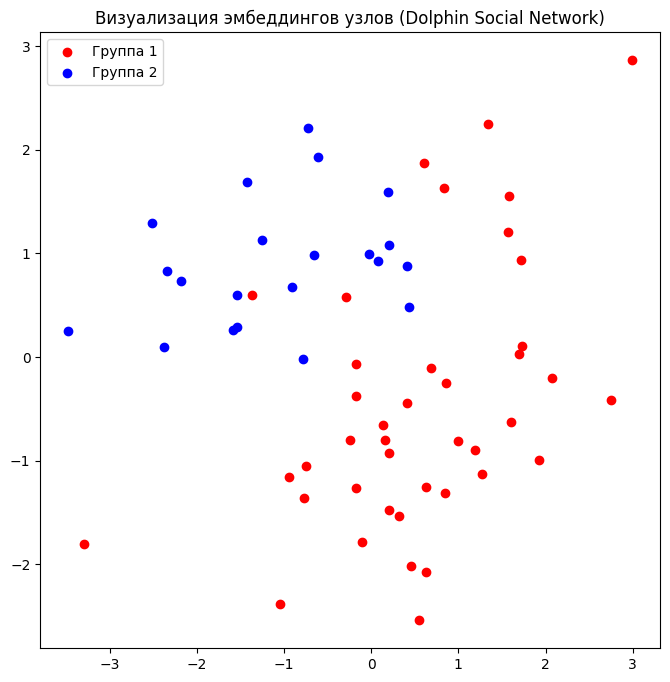

Эпоха 1051, Потеря: 0.1028
Эпоха 1052, Потеря: 0.1026
Эпоха 1053, Потеря: 0.1024
Эпоха 1054, Потеря: 0.1022
Эпоха 1055, Потеря: 0.1021
Эпоха 1056, Потеря: 0.1019
Эпоха 1057, Потеря: 0.1017
Эпоха 1058, Потеря: 0.1015
Эпоха 1059, Потеря: 0.1014
Эпоха 1060, Потеря: 0.1012
Эпоха 1061, Потеря: 0.1010
Эпоха 1062, Потеря: 0.1008
Эпоха 1063, Потеря: 0.1007
Эпоха 1064, Потеря: 0.1005
Эпоха 1065, Потеря: 0.1003
Эпоха 1066, Потеря: 0.1001
Эпоха 1067, Потеря: 0.1000
Эпоха 1068, Потеря: 0.0998
Эпоха 1069, Потеря: 0.0996
Эпоха 1070, Потеря: 0.0995
Эпоха 1071, Потеря: 0.0993
Эпоха 1072, Потеря: 0.0991
Эпоха 1073, Потеря: 0.0990
Эпоха 1074, Потеря: 0.0988
Эпоха 1075, Потеря: 0.0986
Эпоха 1076, Потеря: 0.0985
Эпоха 1077, Потеря: 0.0983
Эпоха 1078, Потеря: 0.0981
Эпоха 1079, Потеря: 0.0980
Эпоха 1080, Потеря: 0.0978
Эпоха 1081, Потеря: 0.0976
Эпоха 1082, Потеря: 0.0975
Эпоха 1083, Потеря: 0.0973
Эпоха 1084, Потеря: 0.0971
Эпоха 1085, Потеря: 0.0970
Эпоха 1086, Потеря: 0.0968
Эпоха 1087, Потеря: 0.0967
Э

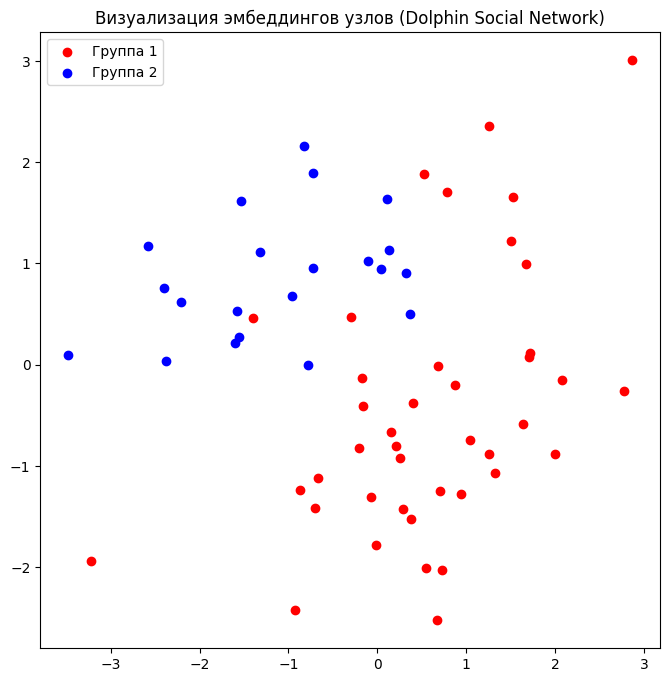

Эпоха 1101, Потеря: 0.0945
Эпоха 1102, Потеря: 0.0943
Эпоха 1103, Потеря: 0.0942
Эпоха 1104, Потеря: 0.0940
Эпоха 1105, Потеря: 0.0939
Эпоха 1106, Потеря: 0.0937
Эпоха 1107, Потеря: 0.0935
Эпоха 1108, Потеря: 0.0934
Эпоха 1109, Потеря: 0.0932
Эпоха 1110, Потеря: 0.0931
Эпоха 1111, Потеря: 0.0929
Эпоха 1112, Потеря: 0.0928
Эпоха 1113, Потеря: 0.0926
Эпоха 1114, Потеря: 0.0925
Эпоха 1115, Потеря: 0.0924
Эпоха 1116, Потеря: 0.0922
Эпоха 1117, Потеря: 0.0921
Эпоха 1118, Потеря: 0.0919
Эпоха 1119, Потеря: 0.0918
Эпоха 1120, Потеря: 0.0916
Эпоха 1121, Потеря: 0.0915
Эпоха 1122, Потеря: 0.0913
Эпоха 1123, Потеря: 0.0912
Эпоха 1124, Потеря: 0.0910
Эпоха 1125, Потеря: 0.0909
Эпоха 1126, Потеря: 0.0907
Эпоха 1127, Потеря: 0.0906
Эпоха 1128, Потеря: 0.0905
Эпоха 1129, Потеря: 0.0903
Эпоха 1130, Потеря: 0.0902
Эпоха 1131, Потеря: 0.0900
Эпоха 1132, Потеря: 0.0899
Эпоха 1133, Потеря: 0.0898
Эпоха 1134, Потеря: 0.0896
Эпоха 1135, Потеря: 0.0895
Эпоха 1136, Потеря: 0.0893
Эпоха 1137, Потеря: 0.0892
Э

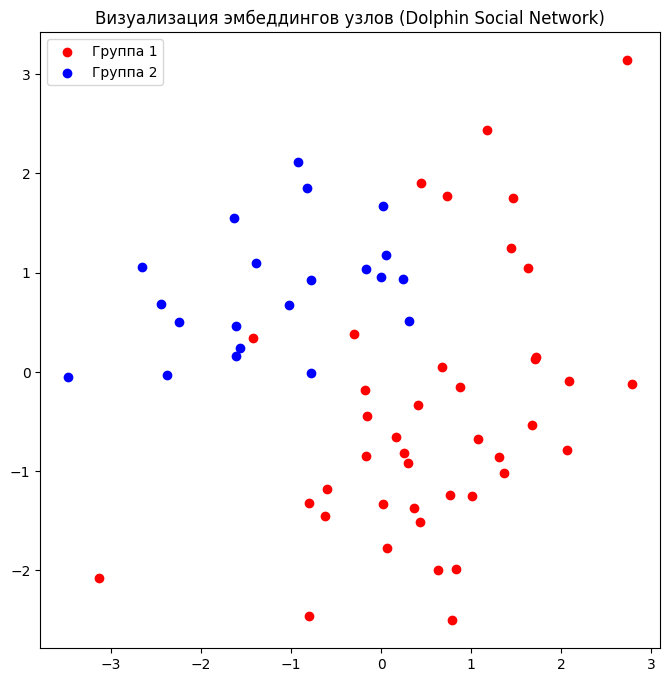

Эпоха 1151, Потеря: 0.0873
Эпоха 1152, Потеря: 0.0872
Эпоха 1153, Потеря: 0.0870
Эпоха 1154, Потеря: 0.0869
Эпоха 1155, Потеря: 0.0868
Эпоха 1156, Потеря: 0.0866
Эпоха 1157, Потеря: 0.0865
Эпоха 1158, Потеря: 0.0864
Эпоха 1159, Потеря: 0.0862
Эпоха 1160, Потеря: 0.0861
Эпоха 1161, Потеря: 0.0860
Эпоха 1162, Потеря: 0.0858
Эпоха 1163, Потеря: 0.0857
Эпоха 1164, Потеря: 0.0856
Эпоха 1165, Потеря: 0.0855
Эпоха 1166, Потеря: 0.0853
Эпоха 1167, Потеря: 0.0852
Эпоха 1168, Потеря: 0.0851
Эпоха 1169, Потеря: 0.0849
Эпоха 1170, Потеря: 0.0848
Эпоха 1171, Потеря: 0.0847
Эпоха 1172, Потеря: 0.0846
Эпоха 1173, Потеря: 0.0844
Эпоха 1174, Потеря: 0.0843
Эпоха 1175, Потеря: 0.0842
Эпоха 1176, Потеря: 0.0841
Эпоха 1177, Потеря: 0.0839
Эпоха 1178, Потеря: 0.0838
Эпоха 1179, Потеря: 0.0837
Эпоха 1180, Потеря: 0.0836
Эпоха 1181, Потеря: 0.0834
Эпоха 1182, Потеря: 0.0833
Эпоха 1183, Потеря: 0.0832
Эпоха 1184, Потеря: 0.0831
Эпоха 1185, Потеря: 0.0829
Эпоха 1186, Потеря: 0.0828
Эпоха 1187, Потеря: 0.0827
Э

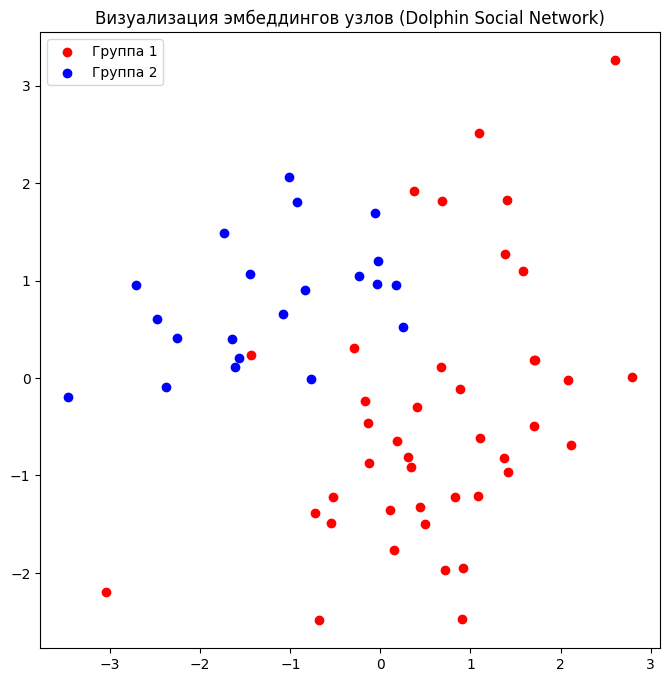

Эпоха 1201, Потеря: 0.0810
Эпоха 1202, Потеря: 0.0809
Эпоха 1203, Потеря: 0.0808
Эпоха 1204, Потеря: 0.0807
Эпоха 1205, Потеря: 0.0806
Эпоха 1206, Потеря: 0.0805
Эпоха 1207, Потеря: 0.0803
Эпоха 1208, Потеря: 0.0802
Эпоха 1209, Потеря: 0.0801
Эпоха 1210, Потеря: 0.0800
Эпоха 1211, Потеря: 0.0799
Эпоха 1212, Потеря: 0.0798
Эпоха 1213, Потеря: 0.0797
Эпоха 1214, Потеря: 0.0795
Эпоха 1215, Потеря: 0.0794
Эпоха 1216, Потеря: 0.0793
Эпоха 1217, Потеря: 0.0792
Эпоха 1218, Потеря: 0.0791
Эпоха 1219, Потеря: 0.0790
Эпоха 1220, Потеря: 0.0789
Эпоха 1221, Потеря: 0.0788
Эпоха 1222, Потеря: 0.0787
Эпоха 1223, Потеря: 0.0785
Эпоха 1224, Потеря: 0.0784
Эпоха 1225, Потеря: 0.0783
Эпоха 1226, Потеря: 0.0782
Эпоха 1227, Потеря: 0.0781
Эпоха 1228, Потеря: 0.0780
Эпоха 1229, Потеря: 0.0779
Эпоха 1230, Потеря: 0.0778
Эпоха 1231, Потеря: 0.0777
Эпоха 1232, Потеря: 0.0776
Эпоха 1233, Потеря: 0.0775
Эпоха 1234, Потеря: 0.0773
Эпоха 1235, Потеря: 0.0772
Эпоха 1236, Потеря: 0.0771
Эпоха 1237, Потеря: 0.0770
Э

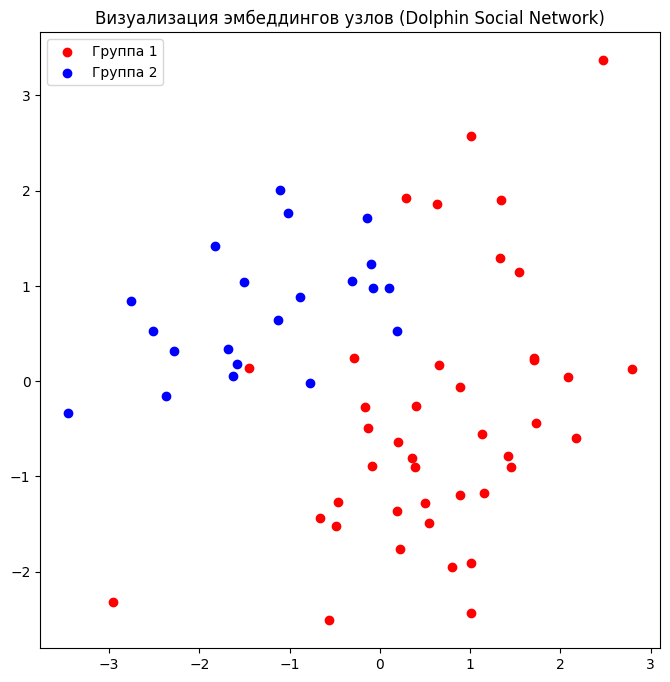

Эпоха 1251, Потеря: 0.0756
Эпоха 1252, Потеря: 0.0755
Эпоха 1253, Потеря: 0.0754
Эпоха 1254, Потеря: 0.0753
Эпоха 1255, Потеря: 0.0751
Эпоха 1256, Потеря: 0.0750
Эпоха 1257, Потеря: 0.0749
Эпоха 1258, Потеря: 0.0748
Эпоха 1259, Потеря: 0.0747
Эпоха 1260, Потеря: 0.0746
Эпоха 1261, Потеря: 0.0745
Эпоха 1262, Потеря: 0.0744
Эпоха 1263, Потеря: 0.0743
Эпоха 1264, Потеря: 0.0742
Эпоха 1265, Потеря: 0.0741
Эпоха 1266, Потеря: 0.0740
Эпоха 1267, Потеря: 0.0739
Эпоха 1268, Потеря: 0.0738
Эпоха 1269, Потеря: 0.0737
Эпоха 1270, Потеря: 0.0736
Эпоха 1271, Потеря: 0.0736
Эпоха 1272, Потеря: 0.0735
Эпоха 1273, Потеря: 0.0734
Эпоха 1274, Потеря: 0.0733
Эпоха 1275, Потеря: 0.0732
Эпоха 1276, Потеря: 0.0731
Эпоха 1277, Потеря: 0.0730
Эпоха 1278, Потеря: 0.0729
Эпоха 1279, Потеря: 0.0728
Эпоха 1280, Потеря: 0.0727
Эпоха 1281, Потеря: 0.0726
Эпоха 1282, Потеря: 0.0725
Эпоха 1283, Потеря: 0.0724
Эпоха 1284, Потеря: 0.0723
Эпоха 1285, Потеря: 0.0722
Эпоха 1286, Потеря: 0.0721
Эпоха 1287, Потеря: 0.0720
Э

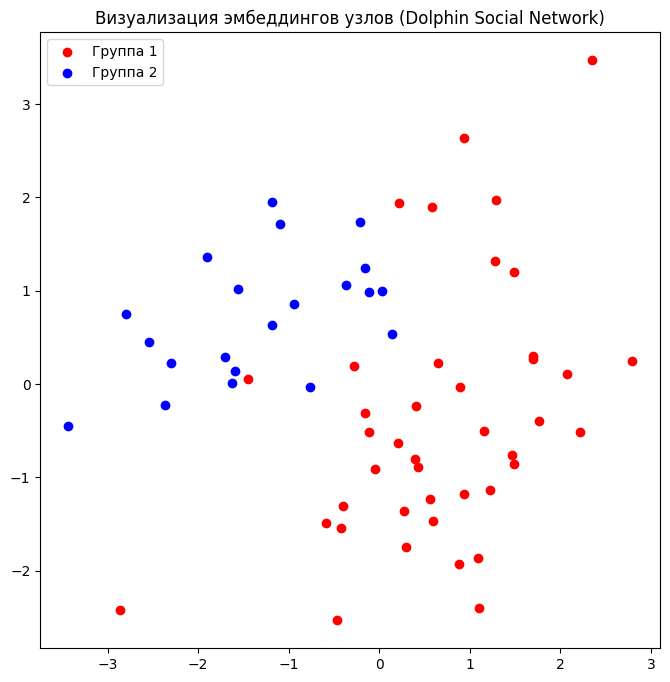

Эпоха 1301, Потеря: 0.0707
Эпоха 1302, Потеря: 0.0706
Эпоха 1303, Потеря: 0.0705
Эпоха 1304, Потеря: 0.0704
Эпоха 1305, Потеря: 0.0704
Эпоха 1306, Потеря: 0.0703
Эпоха 1307, Потеря: 0.0702
Эпоха 1308, Потеря: 0.0701
Эпоха 1309, Потеря: 0.0700
Эпоха 1310, Потеря: 0.0699
Эпоха 1311, Потеря: 0.0698
Эпоха 1312, Потеря: 0.0697
Эпоха 1313, Потеря: 0.0696
Эпоха 1314, Потеря: 0.0696
Эпоха 1315, Потеря: 0.0695
Эпоха 1316, Потеря: 0.0694
Эпоха 1317, Потеря: 0.0693
Эпоха 1318, Потеря: 0.0692
Эпоха 1319, Потеря: 0.0691
Эпоха 1320, Потеря: 0.0690
Эпоха 1321, Потеря: 0.0689
Эпоха 1322, Потеря: 0.0689
Эпоха 1323, Потеря: 0.0688
Эпоха 1324, Потеря: 0.0687
Эпоха 1325, Потеря: 0.0686
Эпоха 1326, Потеря: 0.0685
Эпоха 1327, Потеря: 0.0684
Эпоха 1328, Потеря: 0.0683
Эпоха 1329, Потеря: 0.0682
Эпоха 1330, Потеря: 0.0682
Эпоха 1331, Потеря: 0.0681
Эпоха 1332, Потеря: 0.0680
Эпоха 1333, Потеря: 0.0679
Эпоха 1334, Потеря: 0.0678
Эпоха 1335, Потеря: 0.0677
Эпоха 1336, Потеря: 0.0677
Эпоха 1337, Потеря: 0.0676
Э

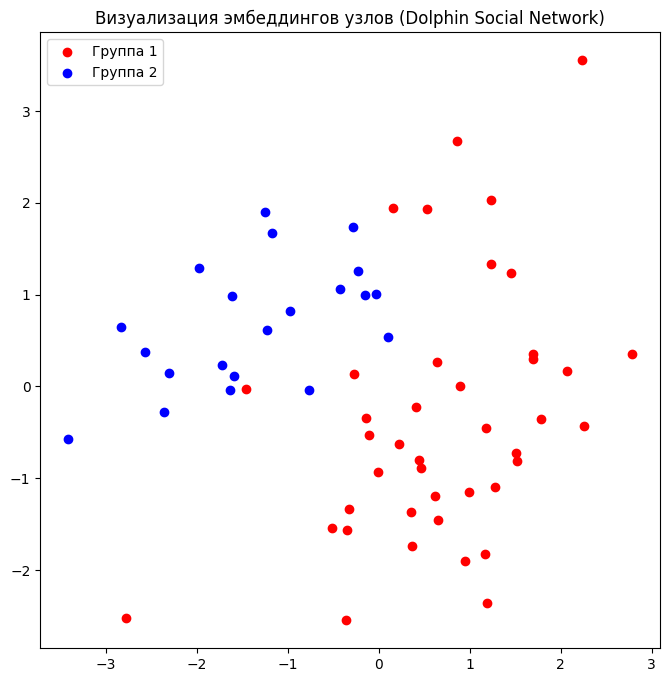

Эпоха 1351, Потеря: 0.0664
Эпоха 1352, Потеря: 0.0663
Эпоха 1353, Потеря: 0.0663
Эпоха 1354, Потеря: 0.0662
Эпоха 1355, Потеря: 0.0661
Эпоха 1356, Потеря: 0.0660
Эпоха 1357, Потеря: 0.0659
Эпоха 1358, Потеря: 0.0659
Эпоха 1359, Потеря: 0.0658
Эпоха 1360, Потеря: 0.0657
Эпоха 1361, Потеря: 0.0656
Эпоха 1362, Потеря: 0.0655
Эпоха 1363, Потеря: 0.0655
Эпоха 1364, Потеря: 0.0654
Эпоха 1365, Потеря: 0.0653
Эпоха 1366, Потеря: 0.0652
Эпоха 1367, Потеря: 0.0651
Эпоха 1368, Потеря: 0.0651
Эпоха 1369, Потеря: 0.0650
Эпоха 1370, Потеря: 0.0649
Эпоха 1371, Потеря: 0.0648
Эпоха 1372, Потеря: 0.0648
Эпоха 1373, Потеря: 0.0647
Эпоха 1374, Потеря: 0.0646
Эпоха 1375, Потеря: 0.0645
Эпоха 1376, Потеря: 0.0644
Эпоха 1377, Потеря: 0.0644
Эпоха 1378, Потеря: 0.0643
Эпоха 1379, Потеря: 0.0642
Эпоха 1380, Потеря: 0.0641
Эпоха 1381, Потеря: 0.0641
Эпоха 1382, Потеря: 0.0640
Эпоха 1383, Потеря: 0.0639
Эпоха 1384, Потеря: 0.0638
Эпоха 1385, Потеря: 0.0638
Эпоха 1386, Потеря: 0.0637
Эпоха 1387, Потеря: 0.0636
Э

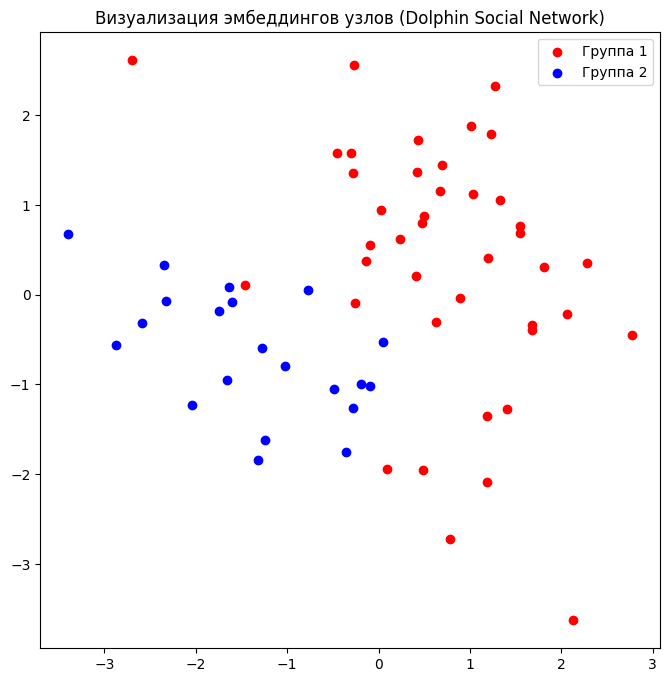

Эпоха 1401, Потеря: 0.0626
Эпоха 1402, Потеря: 0.0625
Эпоха 1403, Потеря: 0.0624
Эпоха 1404, Потеря: 0.0624
Эпоха 1405, Потеря: 0.0623
Эпоха 1406, Потеря: 0.0622
Эпоха 1407, Потеря: 0.0621
Эпоха 1408, Потеря: 0.0621
Эпоха 1409, Потеря: 0.0620
Эпоха 1410, Потеря: 0.0619
Эпоха 1411, Потеря: 0.0619
Эпоха 1412, Потеря: 0.0618
Эпоха 1413, Потеря: 0.0617
Эпоха 1414, Потеря: 0.0616
Эпоха 1415, Потеря: 0.0616
Эпоха 1416, Потеря: 0.0615
Эпоха 1417, Потеря: 0.0614
Эпоха 1418, Потеря: 0.0614
Эпоха 1419, Потеря: 0.0613
Эпоха 1420, Потеря: 0.0612
Эпоха 1421, Потеря: 0.0611
Эпоха 1422, Потеря: 0.0611
Эпоха 1423, Потеря: 0.0610
Эпоха 1424, Потеря: 0.0609
Эпоха 1425, Потеря: 0.0609
Эпоха 1426, Потеря: 0.0608
Эпоха 1427, Потеря: 0.0607
Эпоха 1428, Потеря: 0.0607
Эпоха 1429, Потеря: 0.0606
Эпоха 1430, Потеря: 0.0605
Эпоха 1431, Потеря: 0.0605
Эпоха 1432, Потеря: 0.0604
Эпоха 1433, Потеря: 0.0603
Эпоха 1434, Потеря: 0.0602
Эпоха 1435, Потеря: 0.0602
Эпоха 1436, Потеря: 0.0601
Эпоха 1437, Потеря: 0.0600
Э

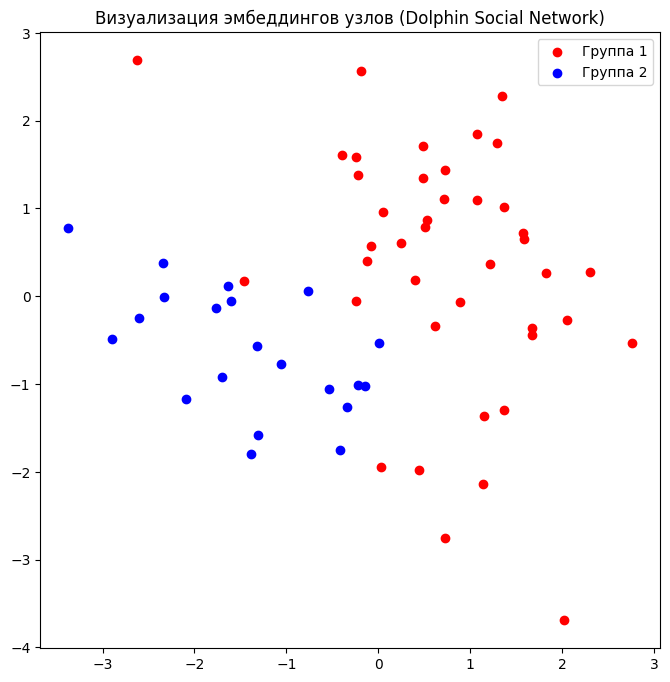

Эпоха 1451, Потеря: 0.0591
Эпоха 1452, Потеря: 0.0590
Эпоха 1453, Потеря: 0.0590
Эпоха 1454, Потеря: 0.0589
Эпоха 1455, Потеря: 0.0589
Эпоха 1456, Потеря: 0.0588
Эпоха 1457, Потеря: 0.0587
Эпоха 1458, Потеря: 0.0587
Эпоха 1459, Потеря: 0.0586
Эпоха 1460, Потеря: 0.0585
Эпоха 1461, Потеря: 0.0585
Эпоха 1462, Потеря: 0.0584
Эпоха 1463, Потеря: 0.0583
Эпоха 1464, Потеря: 0.0583
Эпоха 1465, Потеря: 0.0582
Эпоха 1466, Потеря: 0.0581
Эпоха 1467, Потеря: 0.0581
Эпоха 1468, Потеря: 0.0580
Эпоха 1469, Потеря: 0.0580
Эпоха 1470, Потеря: 0.0579
Эпоха 1471, Потеря: 0.0578
Эпоха 1472, Потеря: 0.0578
Эпоха 1473, Потеря: 0.0577
Эпоха 1474, Потеря: 0.0576
Эпоха 1475, Потеря: 0.0576
Эпоха 1476, Потеря: 0.0575
Эпоха 1477, Потеря: 0.0574
Эпоха 1478, Потеря: 0.0574
Эпоха 1479, Потеря: 0.0573
Эпоха 1480, Потеря: 0.0573
Эпоха 1481, Потеря: 0.0572
Эпоха 1482, Потеря: 0.0571
Эпоха 1483, Потеря: 0.0571
Эпоха 1484, Потеря: 0.0570
Эпоха 1485, Потеря: 0.0570
Эпоха 1486, Потеря: 0.0569
Эпоха 1487, Потеря: 0.0568
Э

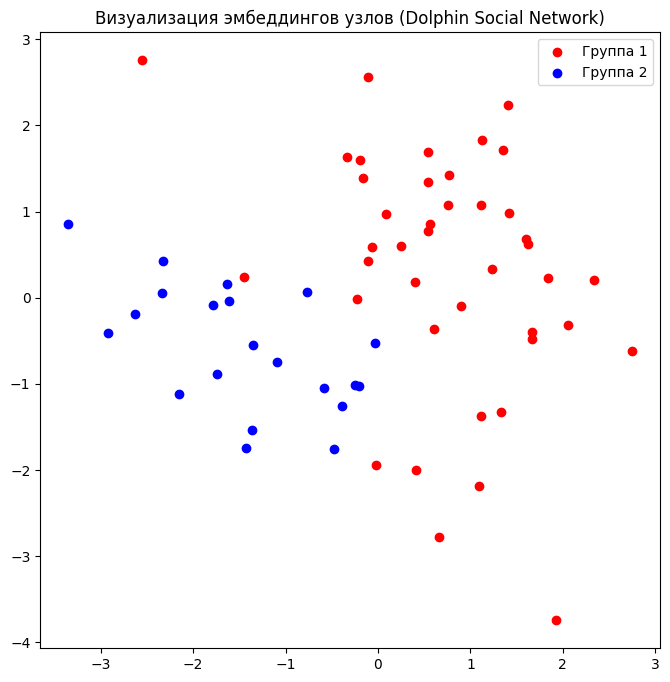

Эпоха 1501, Потеря: 0.0560
Эпоха 1502, Потеря: 0.0559
Эпоха 1503, Потеря: 0.0559
Эпоха 1504, Потеря: 0.0558
Эпоха 1505, Потеря: 0.0558
Эпоха 1506, Потеря: 0.0557
Эпоха 1507, Потеря: 0.0556
Эпоха 1508, Потеря: 0.0556
Эпоха 1509, Потеря: 0.0555
Эпоха 1510, Потеря: 0.0555
Эпоха 1511, Потеря: 0.0554
Эпоха 1512, Потеря: 0.0553
Эпоха 1513, Потеря: 0.0553
Эпоха 1514, Потеря: 0.0552
Эпоха 1515, Потеря: 0.0552
Эпоха 1516, Потеря: 0.0551
Эпоха 1517, Потеря: 0.0551
Эпоха 1518, Потеря: 0.0550
Эпоха 1519, Потеря: 0.0549
Эпоха 1520, Потеря: 0.0549
Эпоха 1521, Потеря: 0.0548
Эпоха 1522, Потеря: 0.0548
Эпоха 1523, Потеря: 0.0547
Эпоха 1524, Потеря: 0.0547
Эпоха 1525, Потеря: 0.0546
Эпоха 1526, Потеря: 0.0545
Эпоха 1527, Потеря: 0.0545
Эпоха 1528, Потеря: 0.0544
Эпоха 1529, Потеря: 0.0544
Эпоха 1530, Потеря: 0.0543
Эпоха 1531, Потеря: 0.0543
Эпоха 1532, Потеря: 0.0542
Эпоха 1533, Потеря: 0.0541
Эпоха 1534, Потеря: 0.0541
Эпоха 1535, Потеря: 0.0540
Эпоха 1536, Потеря: 0.0540
Эпоха 1537, Потеря: 0.0539
Э

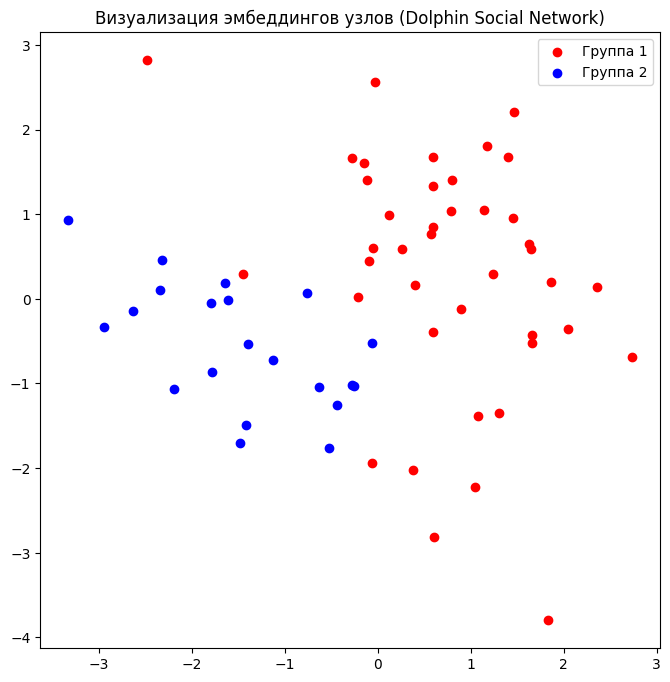

Эпоха 1551, Потеря: 0.0532
Эпоха 1552, Потеря: 0.0531
Эпоха 1553, Потеря: 0.0530
Эпоха 1554, Потеря: 0.0530
Эпоха 1555, Потеря: 0.0529
Эпоха 1556, Потеря: 0.0529
Эпоха 1557, Потеря: 0.0528
Эпоха 1558, Потеря: 0.0528
Эпоха 1559, Потеря: 0.0527
Эпоха 1560, Потеря: 0.0527
Эпоха 1561, Потеря: 0.0526
Эпоха 1562, Потеря: 0.0526
Эпоха 1563, Потеря: 0.0525
Эпоха 1564, Потеря: 0.0525
Эпоха 1565, Потеря: 0.0524
Эпоха 1566, Потеря: 0.0524
Эпоха 1567, Потеря: 0.0523
Эпоха 1568, Потеря: 0.0522
Эпоха 1569, Потеря: 0.0522
Эпоха 1570, Потеря: 0.0521
Эпоха 1571, Потеря: 0.0521
Эпоха 1572, Потеря: 0.0520
Эпоха 1573, Потеря: 0.0520
Эпоха 1574, Потеря: 0.0519
Эпоха 1575, Потеря: 0.0519
Эпоха 1576, Потеря: 0.0518
Эпоха 1577, Потеря: 0.0518
Эпоха 1578, Потеря: 0.0517
Эпоха 1579, Потеря: 0.0517
Эпоха 1580, Потеря: 0.0516
Эпоха 1581, Потеря: 0.0516
Эпоха 1582, Потеря: 0.0515
Эпоха 1583, Потеря: 0.0515
Эпоха 1584, Потеря: 0.0514
Эпоха 1585, Потеря: 0.0514
Эпоха 1586, Потеря: 0.0513
Эпоха 1587, Потеря: 0.0513
Э

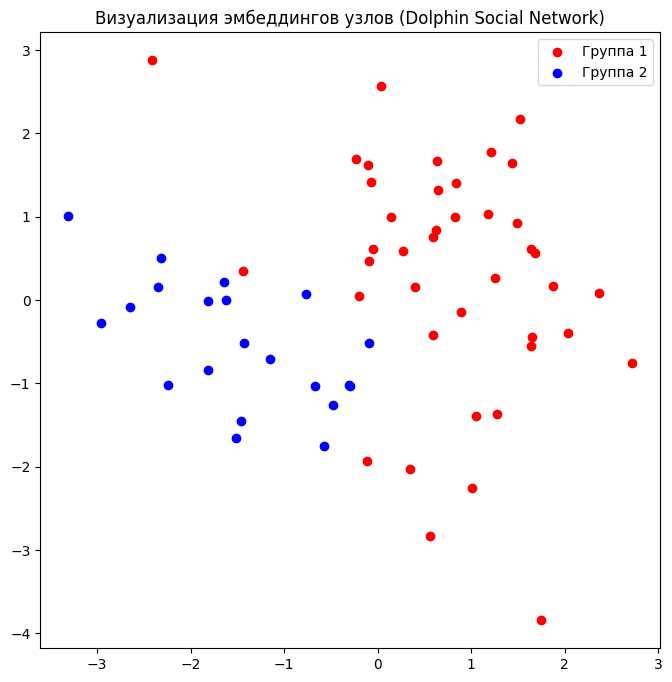

Эпоха 1601, Потеря: 0.0506
Эпоха 1602, Потеря: 0.0505
Эпоха 1603, Потеря: 0.0505
Эпоха 1604, Потеря: 0.0504
Эпоха 1605, Потеря: 0.0504
Эпоха 1606, Потеря: 0.0503
Эпоха 1607, Потеря: 0.0503
Эпоха 1608, Потеря: 0.0502
Эпоха 1609, Потеря: 0.0502
Эпоха 1610, Потеря: 0.0501
Эпоха 1611, Потеря: 0.0501
Эпоха 1612, Потеря: 0.0500
Эпоха 1613, Потеря: 0.0500
Эпоха 1614, Потеря: 0.0499
Эпоха 1615, Потеря: 0.0499
Эпоха 1616, Потеря: 0.0498
Эпоха 1617, Потеря: 0.0498
Эпоха 1618, Потеря: 0.0497
Эпоха 1619, Потеря: 0.0497
Эпоха 1620, Потеря: 0.0496
Эпоха 1621, Потеря: 0.0496
Эпоха 1622, Потеря: 0.0495
Эпоха 1623, Потеря: 0.0495
Эпоха 1624, Потеря: 0.0495
Эпоха 1625, Потеря: 0.0494
Эпоха 1626, Потеря: 0.0494
Эпоха 1627, Потеря: 0.0493
Эпоха 1628, Потеря: 0.0493
Эпоха 1629, Потеря: 0.0492
Эпоха 1630, Потеря: 0.0492
Эпоха 1631, Потеря: 0.0491
Эпоха 1632, Потеря: 0.0491
Эпоха 1633, Потеря: 0.0490
Эпоха 1634, Потеря: 0.0490
Эпоха 1635, Потеря: 0.0489
Эпоха 1636, Потеря: 0.0489
Эпоха 1637, Потеря: 0.0488
Э

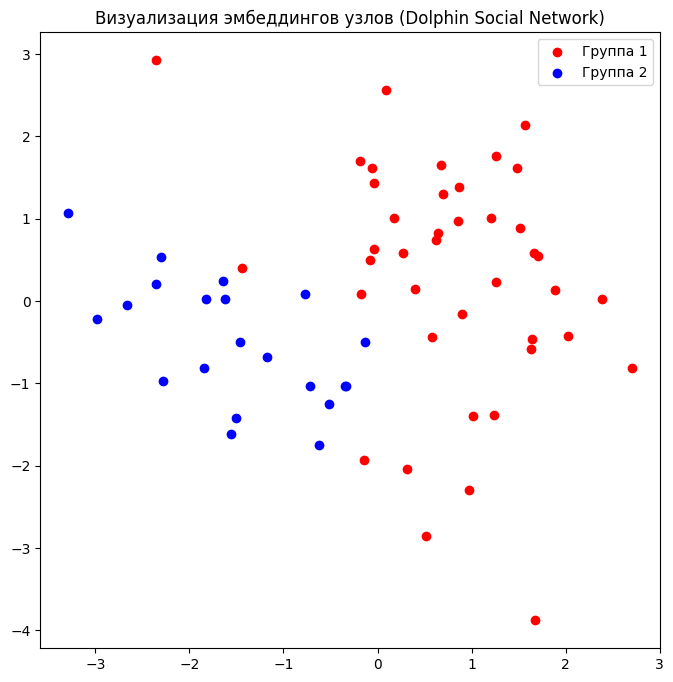

Эпоха 1651, Потеря: 0.0482
Эпоха 1652, Потеря: 0.0482
Эпоха 1653, Потеря: 0.0481
Эпоха 1654, Потеря: 0.0481
Эпоха 1655, Потеря: 0.0480
Эпоха 1656, Потеря: 0.0480
Эпоха 1657, Потеря: 0.0479
Эпоха 1658, Потеря: 0.0479
Эпоха 1659, Потеря: 0.0478
Эпоха 1660, Потеря: 0.0478
Эпоха 1661, Потеря: 0.0478
Эпоха 1662, Потеря: 0.0477
Эпоха 1663, Потеря: 0.0477
Эпоха 1664, Потеря: 0.0476
Эпоха 1665, Потеря: 0.0476
Эпоха 1666, Потеря: 0.0475
Эпоха 1667, Потеря: 0.0475
Эпоха 1668, Потеря: 0.0474
Эпоха 1669, Потеря: 0.0474
Эпоха 1670, Потеря: 0.0474
Эпоха 1671, Потеря: 0.0473
Эпоха 1672, Потеря: 0.0473
Эпоха 1673, Потеря: 0.0472
Эпоха 1674, Потеря: 0.0472
Эпоха 1675, Потеря: 0.0471
Эпоха 1676, Потеря: 0.0471
Эпоха 1677, Потеря: 0.0471
Эпоха 1678, Потеря: 0.0470
Эпоха 1679, Потеря: 0.0470
Эпоха 1680, Потеря: 0.0469
Эпоха 1681, Потеря: 0.0469
Эпоха 1682, Потеря: 0.0468
Эпоха 1683, Потеря: 0.0468
Эпоха 1684, Потеря: 0.0467
Эпоха 1685, Потеря: 0.0467
Эпоха 1686, Потеря: 0.0467
Эпоха 1687, Потеря: 0.0466
Э

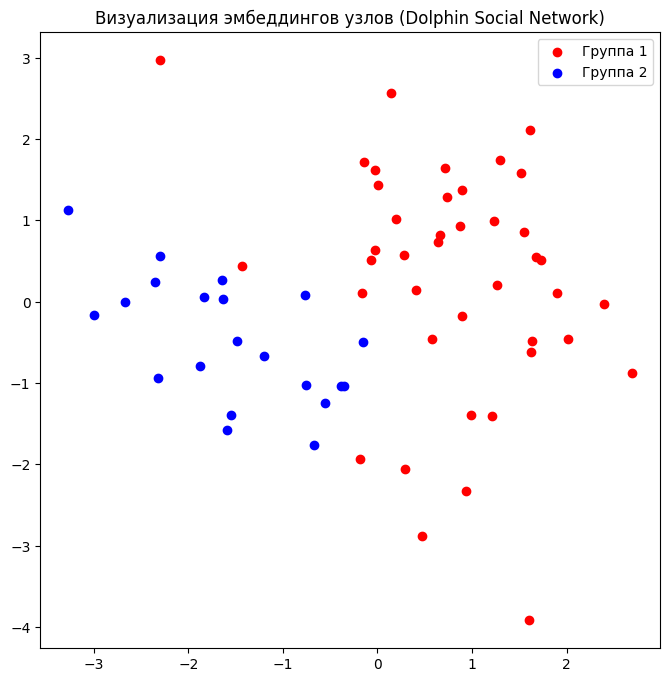

Эпоха 1701, Потеря: 0.0460
Эпоха 1702, Потеря: 0.0460
Эпоха 1703, Потеря: 0.0459
Эпоха 1704, Потеря: 0.0459
Эпоха 1705, Потеря: 0.0459
Эпоха 1706, Потеря: 0.0458
Эпоха 1707, Потеря: 0.0458
Эпоха 1708, Потеря: 0.0457
Эпоха 1709, Потеря: 0.0457
Эпоха 1710, Потеря: 0.0457
Эпоха 1711, Потеря: 0.0456
Эпоха 1712, Потеря: 0.0456
Эпоха 1713, Потеря: 0.0455
Эпоха 1714, Потеря: 0.0455
Эпоха 1715, Потеря: 0.0455
Эпоха 1716, Потеря: 0.0454
Эпоха 1717, Потеря: 0.0454
Эпоха 1718, Потеря: 0.0453
Эпоха 1719, Потеря: 0.0453
Эпоха 1720, Потеря: 0.0453
Эпоха 1721, Потеря: 0.0452
Эпоха 1722, Потеря: 0.0452
Эпоха 1723, Потеря: 0.0451
Эпоха 1724, Потеря: 0.0451
Эпоха 1725, Потеря: 0.0451
Эпоха 1726, Потеря: 0.0450
Эпоха 1727, Потеря: 0.0450
Эпоха 1728, Потеря: 0.0449
Эпоха 1729, Потеря: 0.0449
Эпоха 1730, Потеря: 0.0449
Эпоха 1731, Потеря: 0.0448
Эпоха 1732, Потеря: 0.0448
Эпоха 1733, Потеря: 0.0447
Эпоха 1734, Потеря: 0.0447
Эпоха 1735, Потеря: 0.0447
Эпоха 1736, Потеря: 0.0446
Эпоха 1737, Потеря: 0.0446
Э

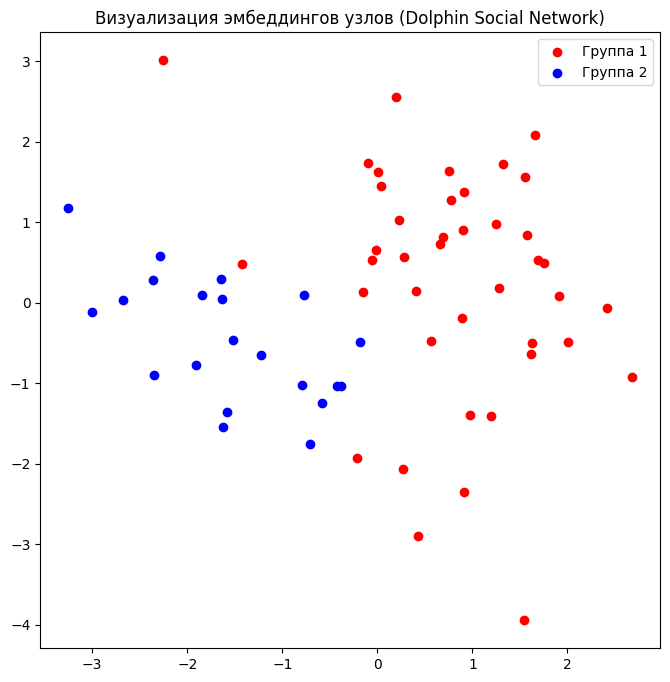

Эпоха 1751, Потеря: 0.0440
Эпоха 1752, Потеря: 0.0440
Эпоха 1753, Потеря: 0.0440
Эпоха 1754, Потеря: 0.0439
Эпоха 1755, Потеря: 0.0439
Эпоха 1756, Потеря: 0.0438
Эпоха 1757, Потеря: 0.0438
Эпоха 1758, Потеря: 0.0438
Эпоха 1759, Потеря: 0.0437
Эпоха 1760, Потеря: 0.0437
Эпоха 1761, Потеря: 0.0436
Эпоха 1762, Потеря: 0.0436
Эпоха 1763, Потеря: 0.0436
Эпоха 1764, Потеря: 0.0435
Эпоха 1765, Потеря: 0.0435
Эпоха 1766, Потеря: 0.0435
Эпоха 1767, Потеря: 0.0434
Эпоха 1768, Потеря: 0.0434
Эпоха 1769, Потеря: 0.0433
Эпоха 1770, Потеря: 0.0433
Эпоха 1771, Потеря: 0.0433
Эпоха 1772, Потеря: 0.0432
Эпоха 1773, Потеря: 0.0432
Эпоха 1774, Потеря: 0.0432
Эпоха 1775, Потеря: 0.0431
Эпоха 1776, Потеря: 0.0431
Эпоха 1777, Потеря: 0.0431
Эпоха 1778, Потеря: 0.0430
Эпоха 1779, Потеря: 0.0430
Эпоха 1780, Потеря: 0.0429
Эпоха 1781, Потеря: 0.0429
Эпоха 1782, Потеря: 0.0429
Эпоха 1783, Потеря: 0.0428
Эпоха 1784, Потеря: 0.0428
Эпоха 1785, Потеря: 0.0428
Эпоха 1786, Потеря: 0.0427
Эпоха 1787, Потеря: 0.0427
Э

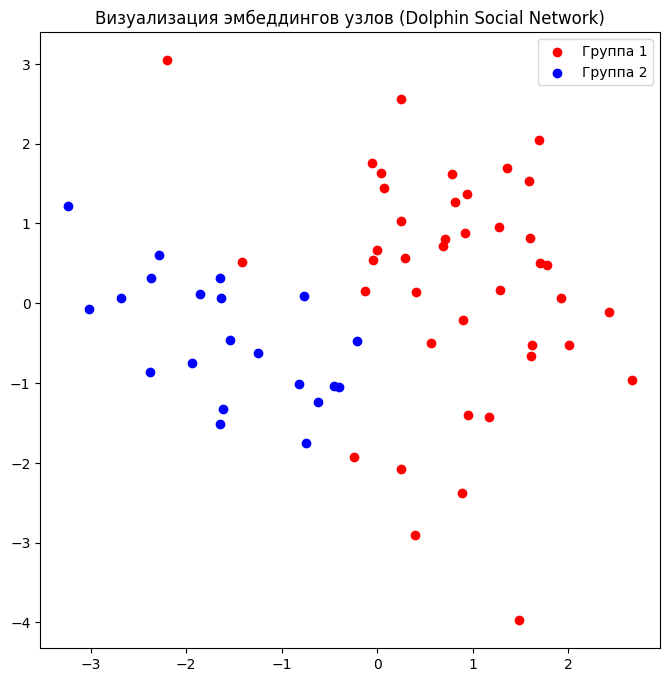

Эпоха 1801, Потеря: 0.0422
Эпоха 1802, Потеря: 0.0421
Эпоха 1803, Потеря: 0.0421
Эпоха 1804, Потеря: 0.0421
Эпоха 1805, Потеря: 0.0420
Эпоха 1806, Потеря: 0.0420
Эпоха 1807, Потеря: 0.0420
Эпоха 1808, Потеря: 0.0419
Эпоха 1809, Потеря: 0.0419
Эпоха 1810, Потеря: 0.0419
Эпоха 1811, Потеря: 0.0418
Эпоха 1812, Потеря: 0.0418
Эпоха 1813, Потеря: 0.0418
Эпоха 1814, Потеря: 0.0417
Эпоха 1815, Потеря: 0.0417
Эпоха 1816, Потеря: 0.0417
Эпоха 1817, Потеря: 0.0416
Эпоха 1818, Потеря: 0.0416
Эпоха 1819, Потеря: 0.0416
Эпоха 1820, Потеря: 0.0415
Эпоха 1821, Потеря: 0.0415
Эпоха 1822, Потеря: 0.0414
Эпоха 1823, Потеря: 0.0414
Эпоха 1824, Потеря: 0.0414
Эпоха 1825, Потеря: 0.0413
Эпоха 1826, Потеря: 0.0413
Эпоха 1827, Потеря: 0.0413
Эпоха 1828, Потеря: 0.0412
Эпоха 1829, Потеря: 0.0412
Эпоха 1830, Потеря: 0.0412
Эпоха 1831, Потеря: 0.0411
Эпоха 1832, Потеря: 0.0411
Эпоха 1833, Потеря: 0.0411
Эпоха 1834, Потеря: 0.0410
Эпоха 1835, Потеря: 0.0410
Эпоха 1836, Потеря: 0.0410
Эпоха 1837, Потеря: 0.0409
Э

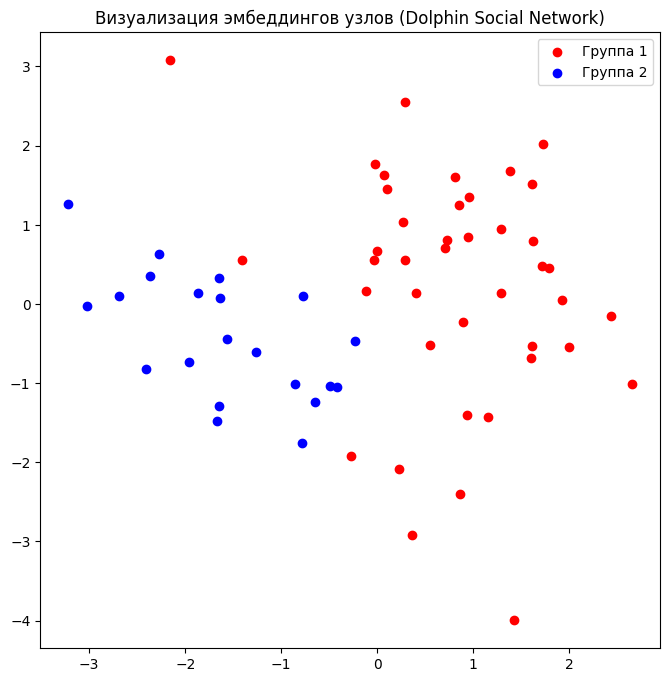

Эпоха 1851, Потеря: 0.0405
Эпоха 1852, Потеря: 0.0404
Эпоха 1853, Потеря: 0.0404
Эпоха 1854, Потеря: 0.0404
Эпоха 1855, Потеря: 0.0403
Эпоха 1856, Потеря: 0.0403
Эпоха 1857, Потеря: 0.0403
Эпоха 1858, Потеря: 0.0402
Эпоха 1859, Потеря: 0.0402
Эпоха 1860, Потеря: 0.0402
Эпоха 1861, Потеря: 0.0401
Эпоха 1862, Потеря: 0.0401
Эпоха 1863, Потеря: 0.0401
Эпоха 1864, Потеря: 0.0400
Эпоха 1865, Потеря: 0.0400
Эпоха 1866, Потеря: 0.0400
Эпоха 1867, Потеря: 0.0400
Эпоха 1868, Потеря: 0.0399
Эпоха 1869, Потеря: 0.0399
Эпоха 1870, Потеря: 0.0399
Эпоха 1871, Потеря: 0.0398
Эпоха 1872, Потеря: 0.0398
Эпоха 1873, Потеря: 0.0398
Эпоха 1874, Потеря: 0.0397
Эпоха 1875, Потеря: 0.0397
Эпоха 1876, Потеря: 0.0397
Эпоха 1877, Потеря: 0.0396
Эпоха 1878, Потеря: 0.0396
Эпоха 1879, Потеря: 0.0396
Эпоха 1880, Потеря: 0.0395
Эпоха 1881, Потеря: 0.0395
Эпоха 1882, Потеря: 0.0395
Эпоха 1883, Потеря: 0.0394
Эпоха 1884, Потеря: 0.0394
Эпоха 1885, Потеря: 0.0394
Эпоха 1886, Потеря: 0.0393
Эпоха 1887, Потеря: 0.0393
Э

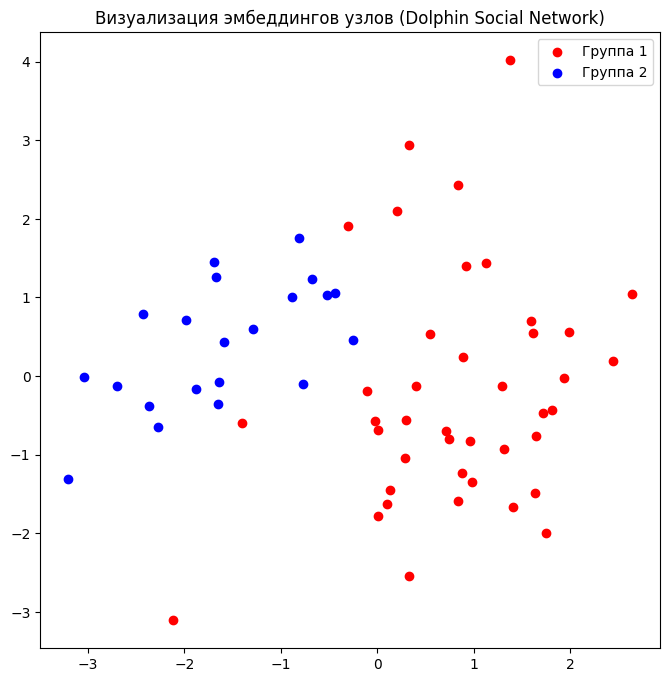

Эпоха 1901, Потеря: 0.0389
Эпоха 1902, Потеря: 0.0389
Эпоха 1903, Потеря: 0.0388
Эпоха 1904, Потеря: 0.0388
Эпоха 1905, Потеря: 0.0388
Эпоха 1906, Потеря: 0.0387
Эпоха 1907, Потеря: 0.0387
Эпоха 1908, Потеря: 0.0387
Эпоха 1909, Потеря: 0.0386
Эпоха 1910, Потеря: 0.0386
Эпоха 1911, Потеря: 0.0386
Эпоха 1912, Потеря: 0.0385
Эпоха 1913, Потеря: 0.0385
Эпоха 1914, Потеря: 0.0385
Эпоха 1915, Потеря: 0.0385
Эпоха 1916, Потеря: 0.0384
Эпоха 1917, Потеря: 0.0384
Эпоха 1918, Потеря: 0.0384
Эпоха 1919, Потеря: 0.0383
Эпоха 1920, Потеря: 0.0383
Эпоха 1921, Потеря: 0.0383
Эпоха 1922, Потеря: 0.0382
Эпоха 1923, Потеря: 0.0382
Эпоха 1924, Потеря: 0.0382
Эпоха 1925, Потеря: 0.0382
Эпоха 1926, Потеря: 0.0381
Эпоха 1927, Потеря: 0.0381
Эпоха 1928, Потеря: 0.0381
Эпоха 1929, Потеря: 0.0380
Эпоха 1930, Потеря: 0.0380
Эпоха 1931, Потеря: 0.0380
Эпоха 1932, Потеря: 0.0380
Эпоха 1933, Потеря: 0.0379
Эпоха 1934, Потеря: 0.0379
Эпоха 1935, Потеря: 0.0379
Эпоха 1936, Потеря: 0.0378
Эпоха 1937, Потеря: 0.0378
Э

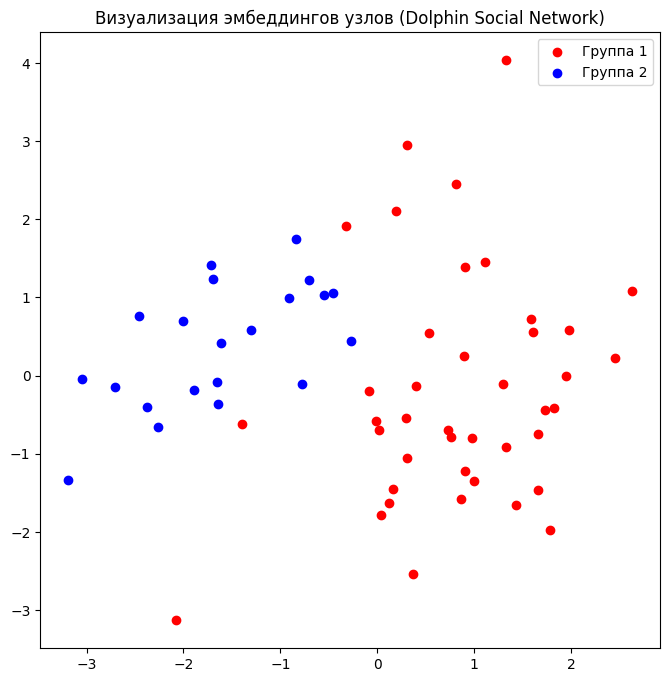

Эпоха 1951, Потеря: 0.0374
Эпоха 1952, Потеря: 0.0374
Эпоха 1953, Потеря: 0.0373
Эпоха 1954, Потеря: 0.0373
Эпоха 1955, Потеря: 0.0373
Эпоха 1956, Потеря: 0.0373
Эпоха 1957, Потеря: 0.0372
Эпоха 1958, Потеря: 0.0372
Эпоха 1959, Потеря: 0.0372
Эпоха 1960, Потеря: 0.0371
Эпоха 1961, Потеря: 0.0371
Эпоха 1962, Потеря: 0.0371
Эпоха 1963, Потеря: 0.0371
Эпоха 1964, Потеря: 0.0370
Эпоха 1965, Потеря: 0.0370
Эпоха 1966, Потеря: 0.0370
Эпоха 1967, Потеря: 0.0370
Эпоха 1968, Потеря: 0.0369
Эпоха 1969, Потеря: 0.0369
Эпоха 1970, Потеря: 0.0369
Эпоха 1971, Потеря: 0.0368
Эпоха 1972, Потеря: 0.0368
Эпоха 1973, Потеря: 0.0368
Эпоха 1974, Потеря: 0.0368
Эпоха 1975, Потеря: 0.0367
Эпоха 1976, Потеря: 0.0367
Эпоха 1977, Потеря: 0.0367
Эпоха 1978, Потеря: 0.0366
Эпоха 1979, Потеря: 0.0366
Эпоха 1980, Потеря: 0.0366
Эпоха 1981, Потеря: 0.0366
Эпоха 1982, Потеря: 0.0365
Эпоха 1983, Потеря: 0.0365
Эпоха 1984, Потеря: 0.0365
Эпоха 1985, Потеря: 0.0365
Эпоха 1986, Потеря: 0.0364
Эпоха 1987, Потеря: 0.0364
Э

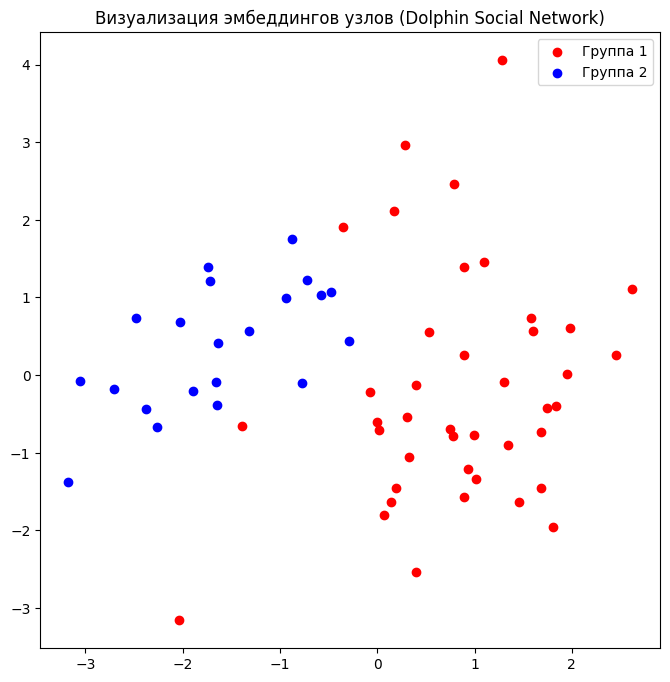

Эпоха 2001, Потеря: 0.0360
Эпоха 2002, Потеря: 0.0360
Эпоха 2003, Потеря: 0.0360
Эпоха 2004, Потеря: 0.0359
Эпоха 2005, Потеря: 0.0359
Эпоха 2006, Потеря: 0.0359
Эпоха 2007, Потеря: 0.0359
Эпоха 2008, Потеря: 0.0358
Эпоха 2009, Потеря: 0.0358
Эпоха 2010, Потеря: 0.0358
Эпоха 2011, Потеря: 0.0358
Эпоха 2012, Потеря: 0.0357
Эпоха 2013, Потеря: 0.0357
Эпоха 2014, Потеря: 0.0357
Эпоха 2015, Потеря: 0.0357
Эпоха 2016, Потеря: 0.0356
Эпоха 2017, Потеря: 0.0356
Эпоха 2018, Потеря: 0.0356
Эпоха 2019, Потеря: 0.0356
Эпоха 2020, Потеря: 0.0355
Эпоха 2021, Потеря: 0.0355
Эпоха 2022, Потеря: 0.0355
Эпоха 2023, Потеря: 0.0354
Эпоха 2024, Потеря: 0.0354
Эпоха 2025, Потеря: 0.0354
Эпоха 2026, Потеря: 0.0354
Эпоха 2027, Потеря: 0.0353
Эпоха 2028, Потеря: 0.0353
Эпоха 2029, Потеря: 0.0353
Эпоха 2030, Потеря: 0.0353
Эпоха 2031, Потеря: 0.0352
Эпоха 2032, Потеря: 0.0352
Эпоха 2033, Потеря: 0.0352
Эпоха 2034, Потеря: 0.0352
Эпоха 2035, Потеря: 0.0351
Эпоха 2036, Потеря: 0.0351
Эпоха 2037, Потеря: 0.0351
Э

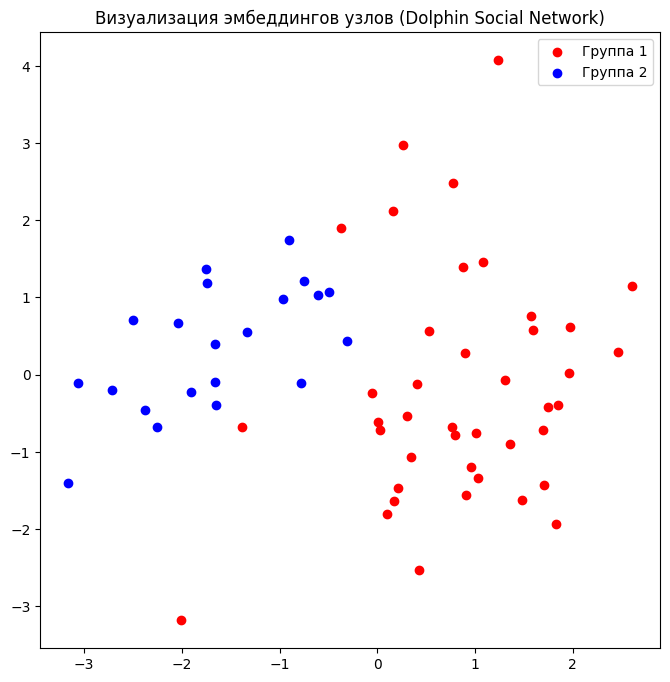

Эпоха 2051, Потеря: 0.0347
Эпоха 2052, Потеря: 0.0347
Эпоха 2053, Потеря: 0.0347
Эпоха 2054, Потеря: 0.0347
Эпоха 2055, Потеря: 0.0346
Эпоха 2056, Потеря: 0.0346
Эпоха 2057, Потеря: 0.0346
Эпоха 2058, Потеря: 0.0346
Эпоха 2059, Потеря: 0.0345
Эпоха 2060, Потеря: 0.0345
Эпоха 2061, Потеря: 0.0345
Эпоха 2062, Потеря: 0.0345
Эпоха 2063, Потеря: 0.0344
Эпоха 2064, Потеря: 0.0344
Эпоха 2065, Потеря: 0.0344
Эпоха 2066, Потеря: 0.0344
Эпоха 2067, Потеря: 0.0343
Эпоха 2068, Потеря: 0.0343
Эпоха 2069, Потеря: 0.0343
Эпоха 2070, Потеря: 0.0343
Эпоха 2071, Потеря: 0.0342
Эпоха 2072, Потеря: 0.0342
Эпоха 2073, Потеря: 0.0342
Эпоха 2074, Потеря: 0.0342
Эпоха 2075, Потеря: 0.0341
Эпоха 2076, Потеря: 0.0341
Эпоха 2077, Потеря: 0.0341
Эпоха 2078, Потеря: 0.0341
Эпоха 2079, Потеря: 0.0340
Эпоха 2080, Потеря: 0.0340
Эпоха 2081, Потеря: 0.0340
Эпоха 2082, Потеря: 0.0340
Эпоха 2083, Потеря: 0.0340
Эпоха 2084, Потеря: 0.0339
Эпоха 2085, Потеря: 0.0339
Эпоха 2086, Потеря: 0.0339
Эпоха 2087, Потеря: 0.0339
Э

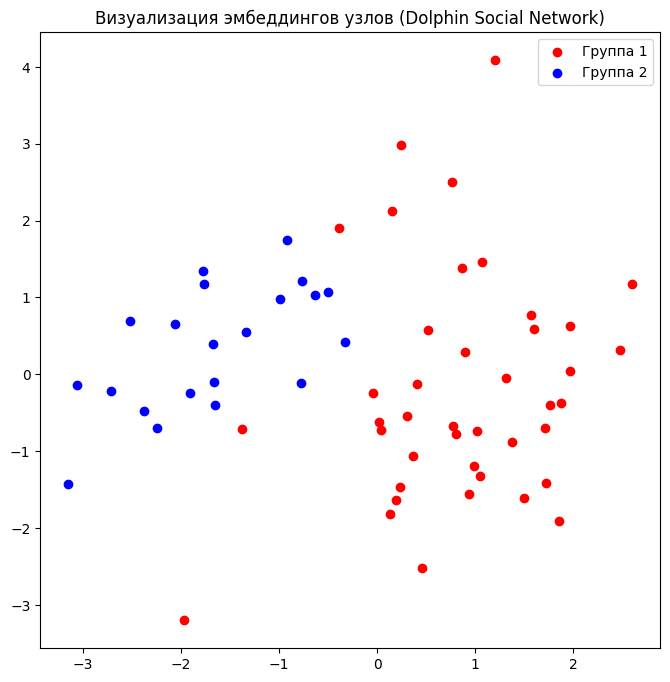

Эпоха 2101, Потеря: 0.0335
Эпоха 2102, Потеря: 0.0335
Эпоха 2103, Потеря: 0.0335
Эпоха 2104, Потеря: 0.0335
Эпоха 2105, Потеря: 0.0334
Эпоха 2106, Потеря: 0.0334
Эпоха 2107, Потеря: 0.0334
Эпоха 2108, Потеря: 0.0334
Эпоха 2109, Потеря: 0.0333
Эпоха 2110, Потеря: 0.0333
Эпоха 2111, Потеря: 0.0333
Эпоха 2112, Потеря: 0.0333
Эпоха 2113, Потеря: 0.0332
Эпоха 2114, Потеря: 0.0332
Эпоха 2115, Потеря: 0.0332
Эпоха 2116, Потеря: 0.0332
Эпоха 2117, Потеря: 0.0332
Эпоха 2118, Потеря: 0.0331
Эпоха 2119, Потеря: 0.0331
Эпоха 2120, Потеря: 0.0331
Эпоха 2121, Потеря: 0.0331
Эпоха 2122, Потеря: 0.0330
Эпоха 2123, Потеря: 0.0330
Эпоха 2124, Потеря: 0.0330
Эпоха 2125, Потеря: 0.0330
Эпоха 2126, Потеря: 0.0330
Эпоха 2127, Потеря: 0.0329
Эпоха 2128, Потеря: 0.0329
Эпоха 2129, Потеря: 0.0329
Эпоха 2130, Потеря: 0.0329
Эпоха 2131, Потеря: 0.0328
Эпоха 2132, Потеря: 0.0328
Эпоха 2133, Потеря: 0.0328
Эпоха 2134, Потеря: 0.0328
Эпоха 2135, Потеря: 0.0327
Эпоха 2136, Потеря: 0.0327
Эпоха 2137, Потеря: 0.0327
Э

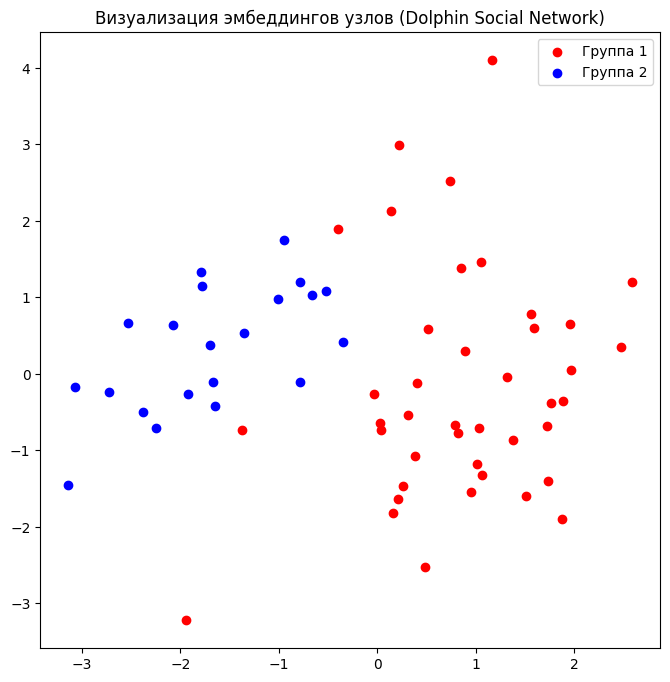

Эпоха 2151, Потеря: 0.0324
Эпоха 2152, Потеря: 0.0324
Эпоха 2153, Потеря: 0.0323
Эпоха 2154, Потеря: 0.0323
Эпоха 2155, Потеря: 0.0323
Эпоха 2156, Потеря: 0.0323
Эпоха 2157, Потеря: 0.0323
Эпоха 2158, Потеря: 0.0322
Эпоха 2159, Потеря: 0.0322
Эпоха 2160, Потеря: 0.0322
Эпоха 2161, Потеря: 0.0322
Эпоха 2162, Потеря: 0.0322
Эпоха 2163, Потеря: 0.0321
Эпоха 2164, Потеря: 0.0321
Эпоха 2165, Потеря: 0.0321
Эпоха 2166, Потеря: 0.0321
Эпоха 2167, Потеря: 0.0320
Эпоха 2168, Потеря: 0.0320
Эпоха 2169, Потеря: 0.0320
Эпоха 2170, Потеря: 0.0320
Эпоха 2171, Потеря: 0.0320
Эпоха 2172, Потеря: 0.0319
Эпоха 2173, Потеря: 0.0319
Эпоха 2174, Потеря: 0.0319
Эпоха 2175, Потеря: 0.0319
Эпоха 2176, Потеря: 0.0319
Эпоха 2177, Потеря: 0.0318
Эпоха 2178, Потеря: 0.0318
Эпоха 2179, Потеря: 0.0318
Эпоха 2180, Потеря: 0.0318
Эпоха 2181, Потеря: 0.0317
Эпоха 2182, Потеря: 0.0317
Эпоха 2183, Потеря: 0.0317
Эпоха 2184, Потеря: 0.0317
Эпоха 2185, Потеря: 0.0317
Эпоха 2186, Потеря: 0.0316
Эпоха 2187, Потеря: 0.0316
Э

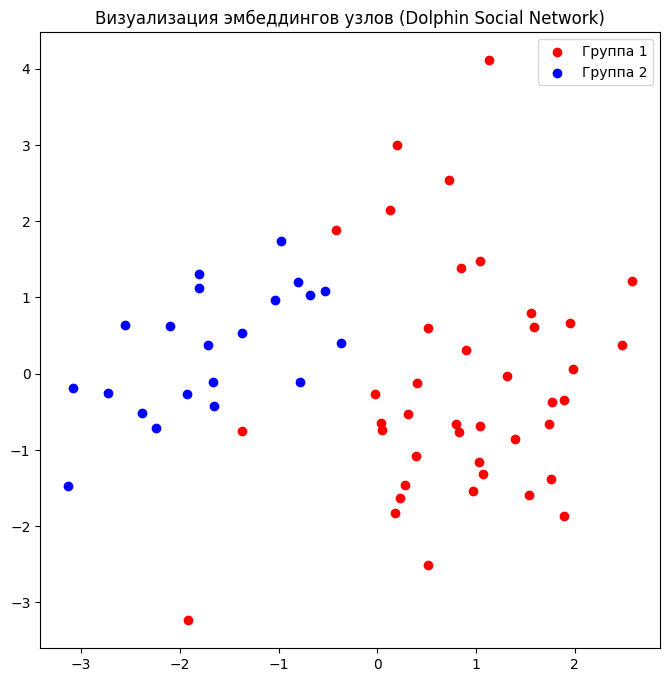

Эпоха 2201, Потеря: 0.0313
Эпоха 2202, Потеря: 0.0313
Эпоха 2203, Потеря: 0.0313
Эпоха 2204, Потеря: 0.0313
Эпоха 2205, Потеря: 0.0312
Эпоха 2206, Потеря: 0.0312
Эпоха 2207, Потеря: 0.0312
Эпоха 2208, Потеря: 0.0312
Эпоха 2209, Потеря: 0.0312
Эпоха 2210, Потеря: 0.0311
Эпоха 2211, Потеря: 0.0311
Эпоха 2212, Потеря: 0.0311
Эпоха 2213, Потеря: 0.0311
Эпоха 2214, Потеря: 0.0311
Эпоха 2215, Потеря: 0.0310
Эпоха 2216, Потеря: 0.0310
Эпоха 2217, Потеря: 0.0310
Эпоха 2218, Потеря: 0.0310
Эпоха 2219, Потеря: 0.0310
Эпоха 2220, Потеря: 0.0309
Эпоха 2221, Потеря: 0.0309
Эпоха 2222, Потеря: 0.0309
Эпоха 2223, Потеря: 0.0309
Эпоха 2224, Потеря: 0.0309
Эпоха 2225, Потеря: 0.0308
Эпоха 2226, Потеря: 0.0308
Эпоха 2227, Потеря: 0.0308
Эпоха 2228, Потеря: 0.0308
Эпоха 2229, Потеря: 0.0308
Эпоха 2230, Потеря: 0.0307
Эпоха 2231, Потеря: 0.0307
Эпоха 2232, Потеря: 0.0307
Эпоха 2233, Потеря: 0.0307
Эпоха 2234, Потеря: 0.0307
Эпоха 2235, Потеря: 0.0306
Эпоха 2236, Потеря: 0.0306
Эпоха 2237, Потеря: 0.0306
Э

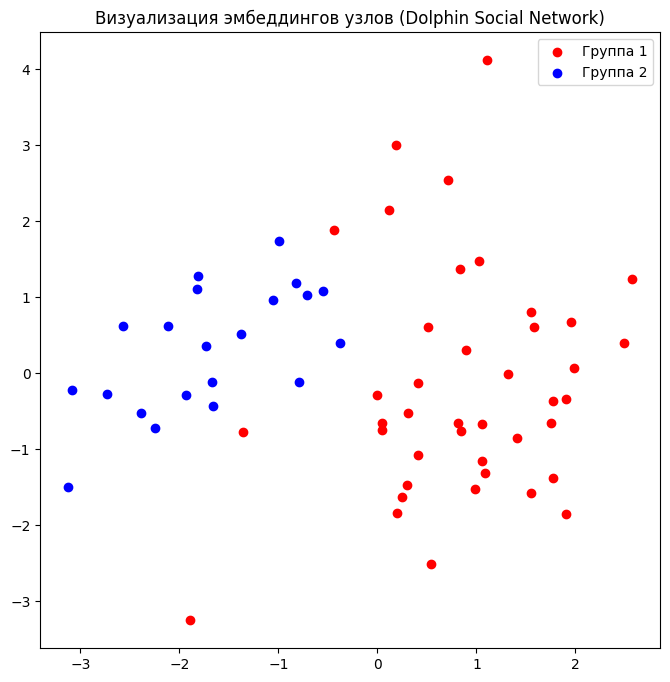

Эпоха 2251, Потеря: 0.0303
Эпоха 2252, Потеря: 0.0303
Эпоха 2253, Потеря: 0.0303
Эпоха 2254, Потеря: 0.0303
Эпоха 2255, Потеря: 0.0302
Эпоха 2256, Потеря: 0.0302
Эпоха 2257, Потеря: 0.0302
Эпоха 2258, Потеря: 0.0302
Эпоха 2259, Потеря: 0.0302
Эпоха 2260, Потеря: 0.0301
Эпоха 2261, Потеря: 0.0301
Эпоха 2262, Потеря: 0.0301
Эпоха 2263, Потеря: 0.0301
Эпоха 2264, Потеря: 0.0301
Эпоха 2265, Потеря: 0.0301
Эпоха 2266, Потеря: 0.0300
Эпоха 2267, Потеря: 0.0300
Эпоха 2268, Потеря: 0.0300
Эпоха 2269, Потеря: 0.0300
Эпоха 2270, Потеря: 0.0300
Эпоха 2271, Потеря: 0.0299
Эпоха 2272, Потеря: 0.0299
Эпоха 2273, Потеря: 0.0299
Эпоха 2274, Потеря: 0.0299
Эпоха 2275, Потеря: 0.0299
Эпоха 2276, Потеря: 0.0298
Эпоха 2277, Потеря: 0.0298
Эпоха 2278, Потеря: 0.0298
Эпоха 2279, Потеря: 0.0298
Эпоха 2280, Потеря: 0.0298
Эпоха 2281, Потеря: 0.0297
Эпоха 2282, Потеря: 0.0297
Эпоха 2283, Потеря: 0.0297
Эпоха 2284, Потеря: 0.0297
Эпоха 2285, Потеря: 0.0297
Эпоха 2286, Потеря: 0.0297
Эпоха 2287, Потеря: 0.0296
Э

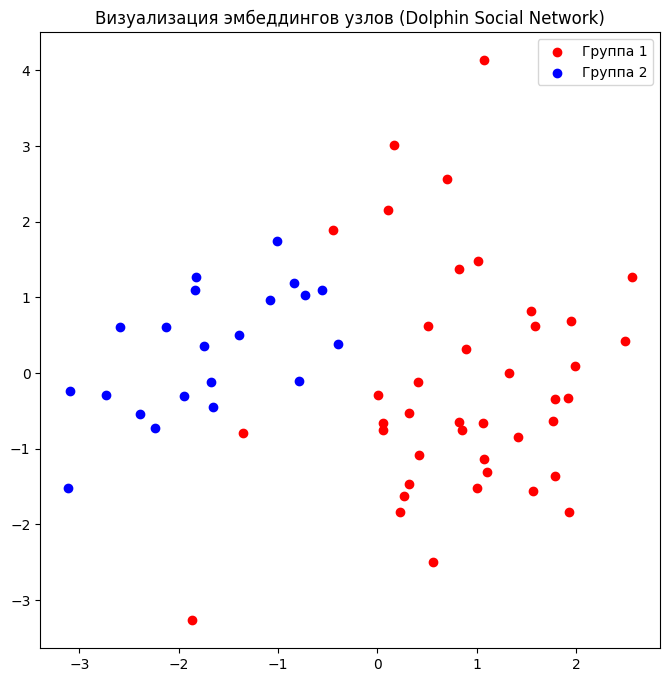

Эпоха 2301, Потеря: 0.0294
Эпоха 2302, Потеря: 0.0294
Эпоха 2303, Потеря: 0.0293
Эпоха 2304, Потеря: 0.0293
Эпоха 2305, Потеря: 0.0293
Эпоха 2306, Потеря: 0.0293
Эпоха 2307, Потеря: 0.0293
Эпоха 2308, Потеря: 0.0292
Эпоха 2309, Потеря: 0.0292
Эпоха 2310, Потеря: 0.0292
Эпоха 2311, Потеря: 0.0292
Эпоха 2312, Потеря: 0.0292
Эпоха 2313, Потеря: 0.0292
Эпоха 2314, Потеря: 0.0291
Эпоха 2315, Потеря: 0.0291
Эпоха 2316, Потеря: 0.0291
Эпоха 2317, Потеря: 0.0291
Эпоха 2318, Потеря: 0.0291
Эпоха 2319, Потеря: 0.0290
Эпоха 2320, Потеря: 0.0290
Эпоха 2321, Потеря: 0.0290
Эпоха 2322, Потеря: 0.0290
Эпоха 2323, Потеря: 0.0290
Эпоха 2324, Потеря: 0.0290
Эпоха 2325, Потеря: 0.0289
Эпоха 2326, Потеря: 0.0289
Эпоха 2327, Потеря: 0.0289
Эпоха 2328, Потеря: 0.0289
Эпоха 2329, Потеря: 0.0289
Эпоха 2330, Потеря: 0.0288
Эпоха 2331, Потеря: 0.0288
Эпоха 2332, Потеря: 0.0288
Эпоха 2333, Потеря: 0.0288
Эпоха 2334, Потеря: 0.0288
Эпоха 2335, Потеря: 0.0288
Эпоха 2336, Потеря: 0.0287
Эпоха 2337, Потеря: 0.0287
Э

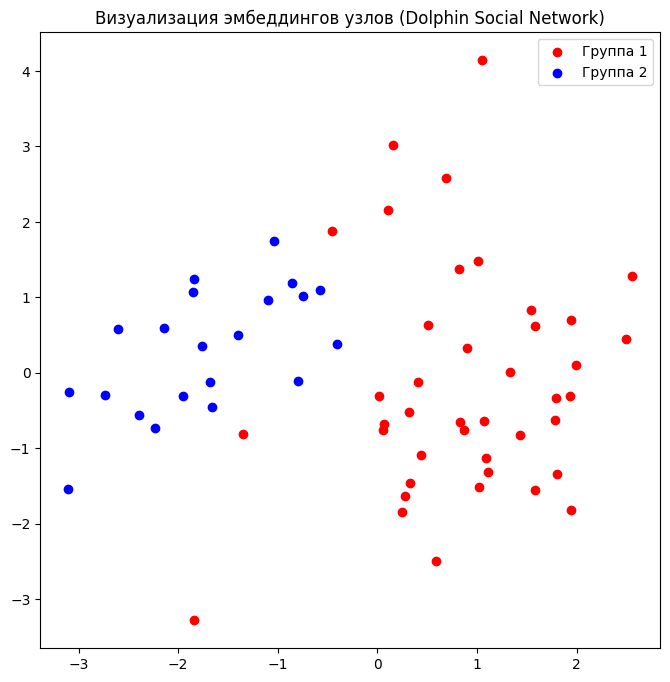

Эпоха 2351, Потеря: 0.0285
Эпоха 2352, Потеря: 0.0285
Эпоха 2353, Потеря: 0.0284
Эпоха 2354, Потеря: 0.0284
Эпоха 2355, Потеря: 0.0284
Эпоха 2356, Потеря: 0.0284
Эпоха 2357, Потеря: 0.0284
Эпоха 2358, Потеря: 0.0284
Эпоха 2359, Потеря: 0.0283
Эпоха 2360, Потеря: 0.0283
Эпоха 2361, Потеря: 0.0283
Эпоха 2362, Потеря: 0.0283
Эпоха 2363, Потеря: 0.0283
Эпоха 2364, Потеря: 0.0283
Эпоха 2365, Потеря: 0.0282
Эпоха 2366, Потеря: 0.0282
Эпоха 2367, Потеря: 0.0282
Эпоха 2368, Потеря: 0.0282
Эпоха 2369, Потеря: 0.0282
Эпоха 2370, Потеря: 0.0282
Эпоха 2371, Потеря: 0.0281
Эпоха 2372, Потеря: 0.0281
Эпоха 2373, Потеря: 0.0281
Эпоха 2374, Потеря: 0.0281
Эпоха 2375, Потеря: 0.0281
Эпоха 2376, Потеря: 0.0281
Эпоха 2377, Потеря: 0.0280
Эпоха 2378, Потеря: 0.0280
Эпоха 2379, Потеря: 0.0280
Эпоха 2380, Потеря: 0.0280
Эпоха 2381, Потеря: 0.0280
Эпоха 2382, Потеря: 0.0280
Эпоха 2383, Потеря: 0.0279
Эпоха 2384, Потеря: 0.0279
Эпоха 2385, Потеря: 0.0279
Эпоха 2386, Потеря: 0.0279
Эпоха 2387, Потеря: 0.0279
Э

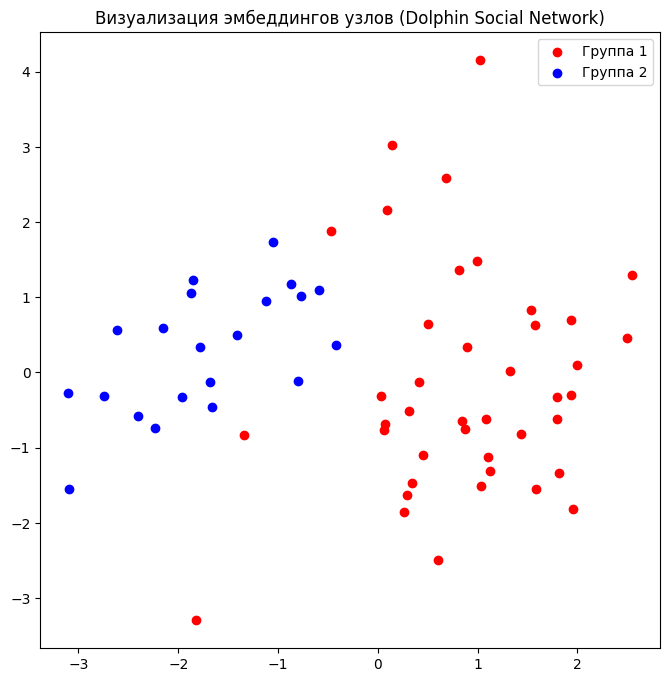

Эпоха 2401, Потеря: 0.0276
Эпоха 2402, Потеря: 0.0276
Эпоха 2403, Потеря: 0.0276
Эпоха 2404, Потеря: 0.0276
Эпоха 2405, Потеря: 0.0276
Эпоха 2406, Потеря: 0.0276
Эпоха 2407, Потеря: 0.0275
Эпоха 2408, Потеря: 0.0275
Эпоха 2409, Потеря: 0.0275
Эпоха 2410, Потеря: 0.0275
Эпоха 2411, Потеря: 0.0275
Эпоха 2412, Потеря: 0.0275
Эпоха 2413, Потеря: 0.0274
Эпоха 2414, Потеря: 0.0274
Эпоха 2415, Потеря: 0.0274
Эпоха 2416, Потеря: 0.0274
Эпоха 2417, Потеря: 0.0274
Эпоха 2418, Потеря: 0.0274
Эпоха 2419, Потеря: 0.0273
Эпоха 2420, Потеря: 0.0273
Эпоха 2421, Потеря: 0.0273
Эпоха 2422, Потеря: 0.0273
Эпоха 2423, Потеря: 0.0273
Эпоха 2424, Потеря: 0.0273
Эпоха 2425, Потеря: 0.0272
Эпоха 2426, Потеря: 0.0272
Эпоха 2427, Потеря: 0.0272
Эпоха 2428, Потеря: 0.0272
Эпоха 2429, Потеря: 0.0272
Эпоха 2430, Потеря: 0.0272
Эпоха 2431, Потеря: 0.0271
Эпоха 2432, Потеря: 0.0271
Эпоха 2433, Потеря: 0.0271
Эпоха 2434, Потеря: 0.0271
Эпоха 2435, Потеря: 0.0271
Эпоха 2436, Потеря: 0.0271
Эпоха 2437, Потеря: 0.0271
Э

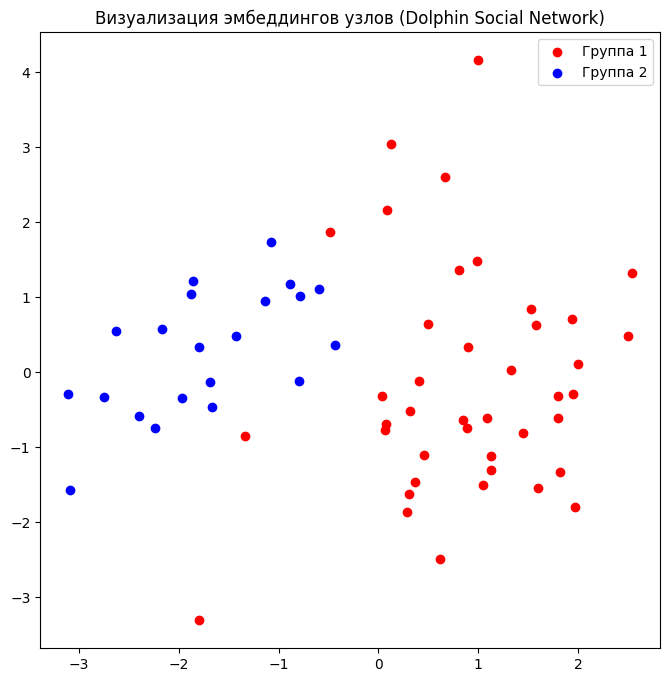

Эпоха 2451, Потеря: 0.0268
Эпоха 2452, Потеря: 0.0268
Эпоха 2453, Потеря: 0.0268
Эпоха 2454, Потеря: 0.0268
Эпоха 2455, Потеря: 0.0268
Эпоха 2456, Потеря: 0.0268
Эпоха 2457, Потеря: 0.0267
Эпоха 2458, Потеря: 0.0267
Эпоха 2459, Потеря: 0.0267
Эпоха 2460, Потеря: 0.0267
Эпоха 2461, Потеря: 0.0267
Эпоха 2462, Потеря: 0.0267
Эпоха 2463, Потеря: 0.0266
Эпоха 2464, Потеря: 0.0266
Эпоха 2465, Потеря: 0.0266
Эпоха 2466, Потеря: 0.0266
Эпоха 2467, Потеря: 0.0266
Эпоха 2468, Потеря: 0.0266
Эпоха 2469, Потеря: 0.0266
Эпоха 2470, Потеря: 0.0265
Эпоха 2471, Потеря: 0.0265
Эпоха 2472, Потеря: 0.0265
Эпоха 2473, Потеря: 0.0265
Эпоха 2474, Потеря: 0.0265
Эпоха 2475, Потеря: 0.0265
Эпоха 2476, Потеря: 0.0264
Эпоха 2477, Потеря: 0.0264
Эпоха 2478, Потеря: 0.0264
Эпоха 2479, Потеря: 0.0264
Эпоха 2480, Потеря: 0.0264
Эпоха 2481, Потеря: 0.0264
Эпоха 2482, Потеря: 0.0264
Эпоха 2483, Потеря: 0.0263
Эпоха 2484, Потеря: 0.0263
Эпоха 2485, Потеря: 0.0263
Эпоха 2486, Потеря: 0.0263
Эпоха 2487, Потеря: 0.0263
Э

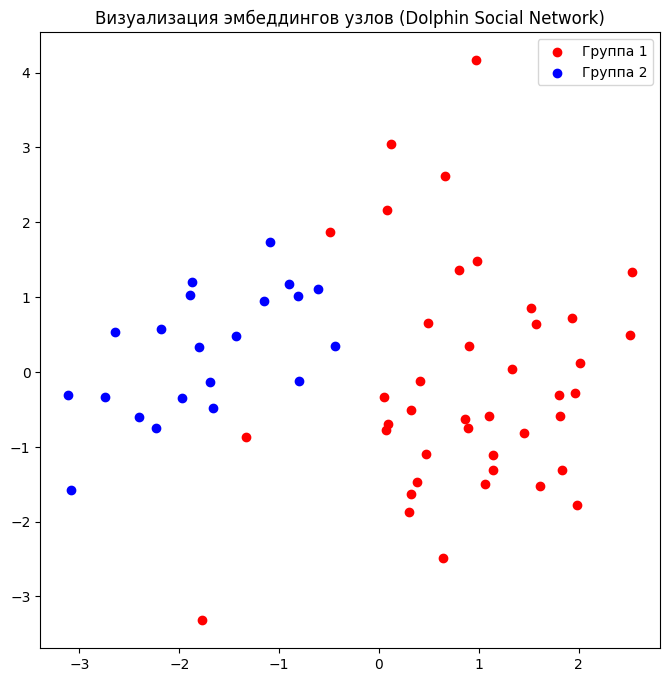

Эпоха 2501, Потеря: 0.0261
Эпоха 2502, Потеря: 0.0261
Эпоха 2503, Потеря: 0.0260
Эпоха 2504, Потеря: 0.0260
Эпоха 2505, Потеря: 0.0260
Эпоха 2506, Потеря: 0.0260
Эпоха 2507, Потеря: 0.0260
Эпоха 2508, Потеря: 0.0260
Эпоха 2509, Потеря: 0.0260
Эпоха 2510, Потеря: 0.0259
Эпоха 2511, Потеря: 0.0259
Эпоха 2512, Потеря: 0.0259
Эпоха 2513, Потеря: 0.0259
Эпоха 2514, Потеря: 0.0259
Эпоха 2515, Потеря: 0.0259
Эпоха 2516, Потеря: 0.0259
Эпоха 2517, Потеря: 0.0258
Эпоха 2518, Потеря: 0.0258
Эпоха 2519, Потеря: 0.0258
Эпоха 2520, Потеря: 0.0258
Эпоха 2521, Потеря: 0.0258
Эпоха 2522, Потеря: 0.0258
Эпоха 2523, Потеря: 0.0258
Эпоха 2524, Потеря: 0.0257
Эпоха 2525, Потеря: 0.0257
Эпоха 2526, Потеря: 0.0257
Эпоха 2527, Потеря: 0.0257
Эпоха 2528, Потеря: 0.0257
Эпоха 2529, Потеря: 0.0257
Эпоха 2530, Потеря: 0.0256
Эпоха 2531, Потеря: 0.0256
Эпоха 2532, Потеря: 0.0256
Эпоха 2533, Потеря: 0.0256
Эпоха 2534, Потеря: 0.0256
Эпоха 2535, Потеря: 0.0256
Эпоха 2536, Потеря: 0.0256
Эпоха 2537, Потеря: 0.0255
Э

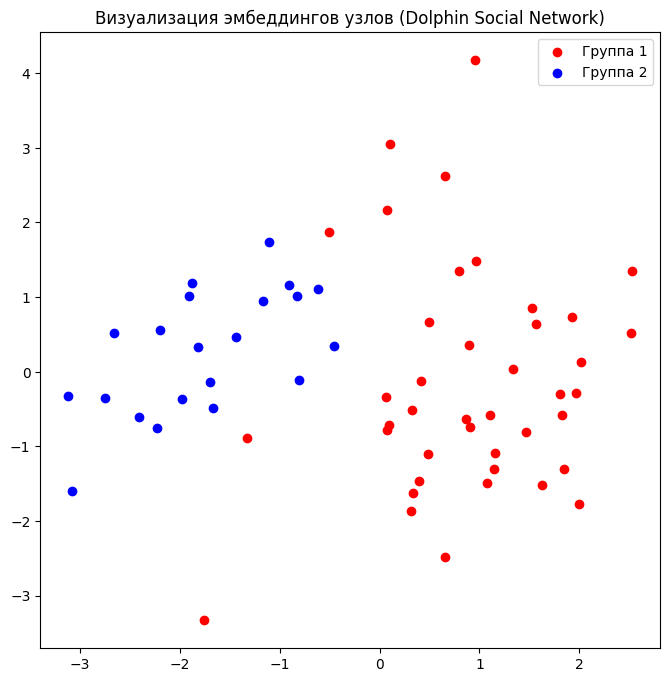

Эпоха 2551, Потеря: 0.0254
Эпоха 2552, Потеря: 0.0253
Эпоха 2553, Потеря: 0.0253
Эпоха 2554, Потеря: 0.0253
Эпоха 2555, Потеря: 0.0253
Эпоха 2556, Потеря: 0.0253
Эпоха 2557, Потеря: 0.0253
Эпоха 2558, Потеря: 0.0253
Эпоха 2559, Потеря: 0.0252
Эпоха 2560, Потеря: 0.0252
Эпоха 2561, Потеря: 0.0252
Эпоха 2562, Потеря: 0.0252
Эпоха 2563, Потеря: 0.0252
Эпоха 2564, Потеря: 0.0252
Эпоха 2565, Потеря: 0.0252
Эпоха 2566, Потеря: 0.0251
Эпоха 2567, Потеря: 0.0251
Эпоха 2568, Потеря: 0.0251
Эпоха 2569, Потеря: 0.0251
Эпоха 2570, Потеря: 0.0251
Эпоха 2571, Потеря: 0.0251
Эпоха 2572, Потеря: 0.0251
Эпоха 2573, Потеря: 0.0250
Эпоха 2574, Потеря: 0.0250
Эпоха 2575, Потеря: 0.0250
Эпоха 2576, Потеря: 0.0250
Эпоха 2577, Потеря: 0.0250
Эпоха 2578, Потеря: 0.0250
Эпоха 2579, Потеря: 0.0250
Эпоха 2580, Потеря: 0.0249
Эпоха 2581, Потеря: 0.0249
Эпоха 2582, Потеря: 0.0249
Эпоха 2583, Потеря: 0.0249
Эпоха 2584, Потеря: 0.0249
Эпоха 2585, Потеря: 0.0249
Эпоха 2586, Потеря: 0.0249
Эпоха 2587, Потеря: 0.0249
Э

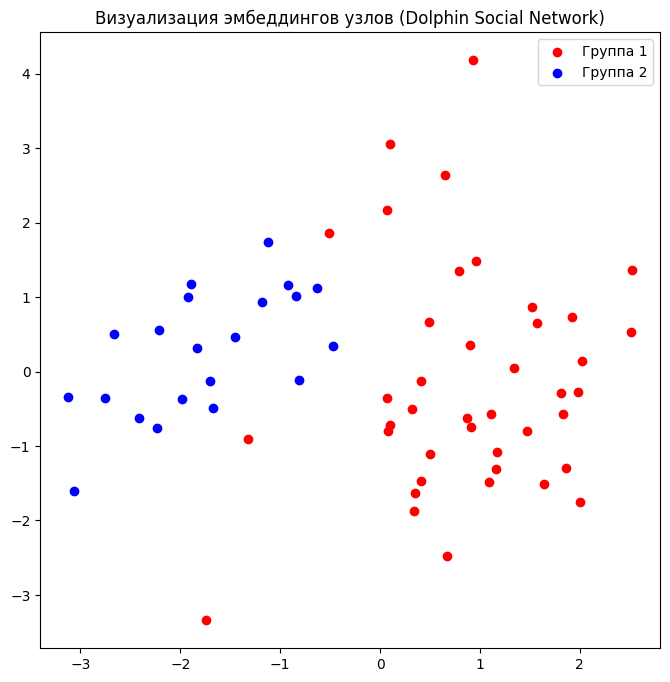

Эпоха 2601, Потеря: 0.0247
Эпоха 2602, Потеря: 0.0247
Эпоха 2603, Потеря: 0.0246
Эпоха 2604, Потеря: 0.0246
Эпоха 2605, Потеря: 0.0246
Эпоха 2606, Потеря: 0.0246
Эпоха 2607, Потеря: 0.0246
Эпоха 2608, Потеря: 0.0246
Эпоха 2609, Потеря: 0.0246
Эпоха 2610, Потеря: 0.0245
Эпоха 2611, Потеря: 0.0245
Эпоха 2612, Потеря: 0.0245
Эпоха 2613, Потеря: 0.0245
Эпоха 2614, Потеря: 0.0245
Эпоха 2615, Потеря: 0.0245
Эпоха 2616, Потеря: 0.0245
Эпоха 2617, Потеря: 0.0245
Эпоха 2618, Потеря: 0.0244
Эпоха 2619, Потеря: 0.0244
Эпоха 2620, Потеря: 0.0244
Эпоха 2621, Потеря: 0.0244
Эпоха 2622, Потеря: 0.0244
Эпоха 2623, Потеря: 0.0244
Эпоха 2624, Потеря: 0.0244
Эпоха 2625, Потеря: 0.0243
Эпоха 2626, Потеря: 0.0243
Эпоха 2627, Потеря: 0.0243
Эпоха 2628, Потеря: 0.0243
Эпоха 2629, Потеря: 0.0243
Эпоха 2630, Потеря: 0.0243
Эпоха 2631, Потеря: 0.0243
Эпоха 2632, Потеря: 0.0243
Эпоха 2633, Потеря: 0.0242
Эпоха 2634, Потеря: 0.0242
Эпоха 2635, Потеря: 0.0242
Эпоха 2636, Потеря: 0.0242
Эпоха 2637, Потеря: 0.0242
Э

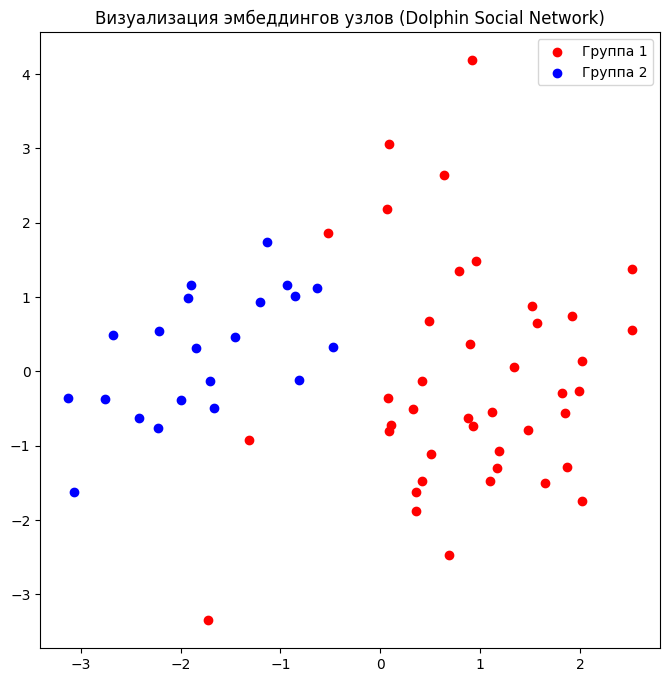

Эпоха 2651, Потеря: 0.0240
Эпоха 2652, Потеря: 0.0240
Эпоха 2653, Потеря: 0.0240
Эпоха 2654, Потеря: 0.0240
Эпоха 2655, Потеря: 0.0240
Эпоха 2656, Потеря: 0.0239
Эпоха 2657, Потеря: 0.0239
Эпоха 2658, Потеря: 0.0239
Эпоха 2659, Потеря: 0.0239
Эпоха 2660, Потеря: 0.0239
Эпоха 2661, Потеря: 0.0239
Эпоха 2662, Потеря: 0.0239
Эпоха 2663, Потеря: 0.0239
Эпоха 2664, Потеря: 0.0238
Эпоха 2665, Потеря: 0.0238
Эпоха 2666, Потеря: 0.0238
Эпоха 2667, Потеря: 0.0238
Эпоха 2668, Потеря: 0.0238
Эпоха 2669, Потеря: 0.0238
Эпоха 2670, Потеря: 0.0238
Эпоха 2671, Потеря: 0.0238
Эпоха 2672, Потеря: 0.0237
Эпоха 2673, Потеря: 0.0237
Эпоха 2674, Потеря: 0.0237
Эпоха 2675, Потеря: 0.0237
Эпоха 2676, Потеря: 0.0237
Эпоха 2677, Потеря: 0.0237
Эпоха 2678, Потеря: 0.0237
Эпоха 2679, Потеря: 0.0237
Эпоха 2680, Потеря: 0.0236
Эпоха 2681, Потеря: 0.0236
Эпоха 2682, Потеря: 0.0236
Эпоха 2683, Потеря: 0.0236
Эпоха 2684, Потеря: 0.0236
Эпоха 2685, Потеря: 0.0236
Эпоха 2686, Потеря: 0.0236
Эпоха 2687, Потеря: 0.0236
Э

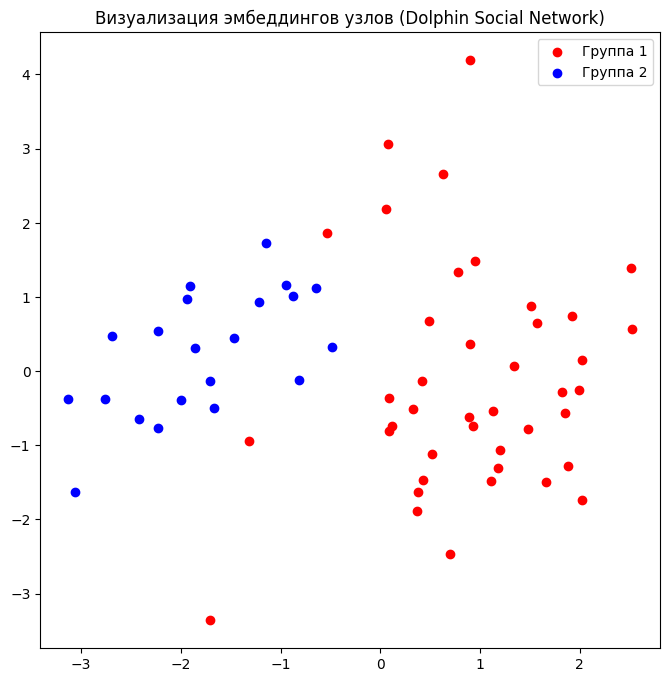

Эпоха 2701, Потеря: 0.0234
Эпоха 2702, Потеря: 0.0234
Эпоха 2703, Потеря: 0.0234
Эпоха 2704, Потеря: 0.0234
Эпоха 2705, Потеря: 0.0233
Эпоха 2706, Потеря: 0.0233
Эпоха 2707, Потеря: 0.0233
Эпоха 2708, Потеря: 0.0233
Эпоха 2709, Потеря: 0.0233
Эпоха 2710, Потеря: 0.0233
Эпоха 2711, Потеря: 0.0233
Эпоха 2712, Потеря: 0.0233
Эпоха 2713, Потеря: 0.0232
Эпоха 2714, Потеря: 0.0232
Эпоха 2715, Потеря: 0.0232
Эпоха 2716, Потеря: 0.0232
Эпоха 2717, Потеря: 0.0232
Эпоха 2718, Потеря: 0.0232
Эпоха 2719, Потеря: 0.0232
Эпоха 2720, Потеря: 0.0232
Эпоха 2721, Потеря: 0.0231
Эпоха 2722, Потеря: 0.0231
Эпоха 2723, Потеря: 0.0231
Эпоха 2724, Потеря: 0.0231
Эпоха 2725, Потеря: 0.0231
Эпоха 2726, Потеря: 0.0231
Эпоха 2727, Потеря: 0.0231
Эпоха 2728, Потеря: 0.0231
Эпоха 2729, Потеря: 0.0231
Эпоха 2730, Потеря: 0.0230
Эпоха 2731, Потеря: 0.0230
Эпоха 2732, Потеря: 0.0230
Эпоха 2733, Потеря: 0.0230
Эпоха 2734, Потеря: 0.0230
Эпоха 2735, Потеря: 0.0230
Эпоха 2736, Потеря: 0.0230
Эпоха 2737, Потеря: 0.0230
Э

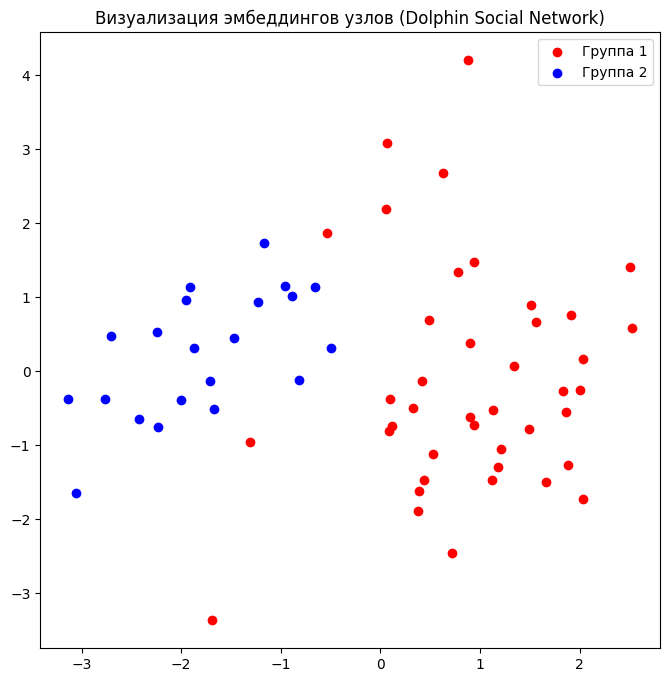

Эпоха 2751, Потеря: 0.0228
Эпоха 2752, Потеря: 0.0228
Эпоха 2753, Потеря: 0.0228
Эпоха 2754, Потеря: 0.0228
Эпоха 2755, Потеря: 0.0228
Эпоха 2756, Потеря: 0.0227
Эпоха 2757, Потеря: 0.0227
Эпоха 2758, Потеря: 0.0227
Эпоха 2759, Потеря: 0.0227
Эпоха 2760, Потеря: 0.0227
Эпоха 2761, Потеря: 0.0227
Эпоха 2762, Потеря: 0.0227
Эпоха 2763, Потеря: 0.0227
Эпоха 2764, Потеря: 0.0226
Эпоха 2765, Потеря: 0.0226
Эпоха 2766, Потеря: 0.0226
Эпоха 2767, Потеря: 0.0226
Эпоха 2768, Потеря: 0.0226
Эпоха 2769, Потеря: 0.0226
Эпоха 2770, Потеря: 0.0226
Эпоха 2771, Потеря: 0.0226
Эпоха 2772, Потеря: 0.0226
Эпоха 2773, Потеря: 0.0225
Эпоха 2774, Потеря: 0.0225
Эпоха 2775, Потеря: 0.0225
Эпоха 2776, Потеря: 0.0225
Эпоха 2777, Потеря: 0.0225
Эпоха 2778, Потеря: 0.0225
Эпоха 2779, Потеря: 0.0225
Эпоха 2780, Потеря: 0.0225
Эпоха 2781, Потеря: 0.0225
Эпоха 2782, Потеря: 0.0224
Эпоха 2783, Потеря: 0.0224
Эпоха 2784, Потеря: 0.0224
Эпоха 2785, Потеря: 0.0224
Эпоха 2786, Потеря: 0.0224
Эпоха 2787, Потеря: 0.0224
Э

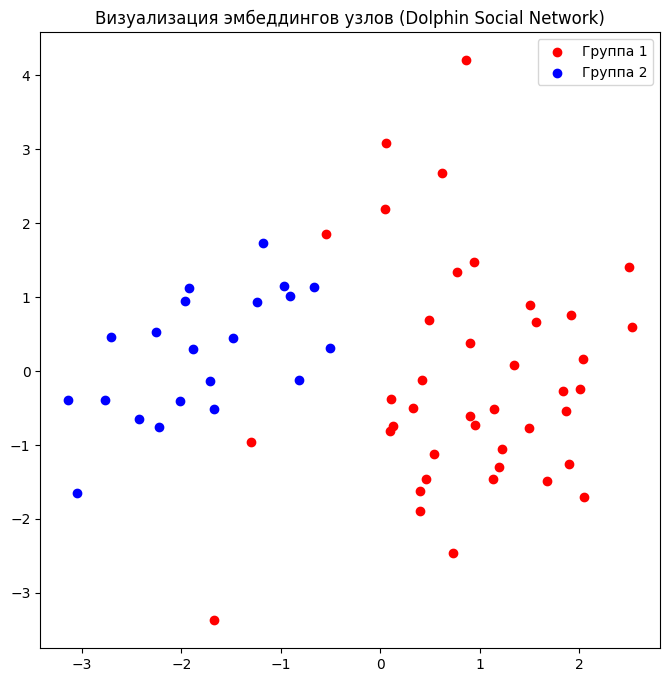

Эпоха 2801, Потеря: 0.0222
Эпоха 2802, Потеря: 0.0222
Эпоха 2803, Потеря: 0.0222
Эпоха 2804, Потеря: 0.0222
Эпоха 2805, Потеря: 0.0222
Эпоха 2806, Потеря: 0.0222
Эпоха 2807, Потеря: 0.0222
Эпоха 2808, Потеря: 0.0222
Эпоха 2809, Потеря: 0.0221
Эпоха 2810, Потеря: 0.0221
Эпоха 2811, Потеря: 0.0221
Эпоха 2812, Потеря: 0.0221
Эпоха 2813, Потеря: 0.0221
Эпоха 2814, Потеря: 0.0221
Эпоха 2815, Потеря: 0.0221
Эпоха 2816, Потеря: 0.0221
Эпоха 2817, Потеря: 0.0221
Эпоха 2818, Потеря: 0.0220
Эпоха 2819, Потеря: 0.0220
Эпоха 2820, Потеря: 0.0220
Эпоха 2821, Потеря: 0.0220
Эпоха 2822, Потеря: 0.0220
Эпоха 2823, Потеря: 0.0220
Эпоха 2824, Потеря: 0.0220
Эпоха 2825, Потеря: 0.0220
Эпоха 2826, Потеря: 0.0220
Эпоха 2827, Потеря: 0.0219
Эпоха 2828, Потеря: 0.0219
Эпоха 2829, Потеря: 0.0219
Эпоха 2830, Потеря: 0.0219
Эпоха 2831, Потеря: 0.0219
Эпоха 2832, Потеря: 0.0219
Эпоха 2833, Потеря: 0.0219
Эпоха 2834, Потеря: 0.0219
Эпоха 2835, Потеря: 0.0219
Эпоха 2836, Потеря: 0.0218
Эпоха 2837, Потеря: 0.0218
Э

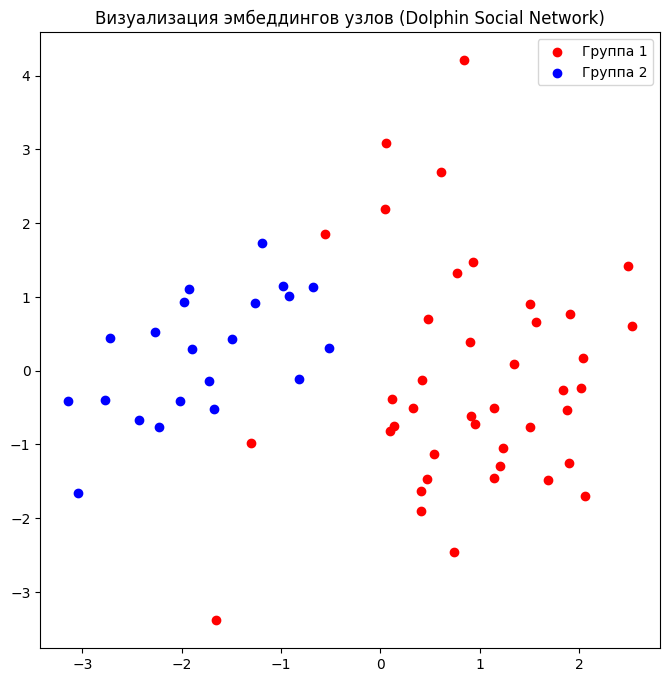

Эпоха 2851, Потеря: 0.0217
Эпоха 2852, Потеря: 0.0217
Эпоха 2853, Потеря: 0.0217
Эпоха 2854, Потеря: 0.0217
Эпоха 2855, Потеря: 0.0216
Эпоха 2856, Потеря: 0.0216
Эпоха 2857, Потеря: 0.0216
Эпоха 2858, Потеря: 0.0216
Эпоха 2859, Потеря: 0.0216
Эпоха 2860, Потеря: 0.0216
Эпоха 2861, Потеря: 0.0216
Эпоха 2862, Потеря: 0.0216
Эпоха 2863, Потеря: 0.0216
Эпоха 2864, Потеря: 0.0216
Эпоха 2865, Потеря: 0.0215
Эпоха 2866, Потеря: 0.0215
Эпоха 2867, Потеря: 0.0215
Эпоха 2868, Потеря: 0.0215
Эпоха 2869, Потеря: 0.0215
Эпоха 2870, Потеря: 0.0215
Эпоха 2871, Потеря: 0.0215
Эпоха 2872, Потеря: 0.0215
Эпоха 2873, Потеря: 0.0215
Эпоха 2874, Потеря: 0.0214
Эпоха 2875, Потеря: 0.0214
Эпоха 2876, Потеря: 0.0214
Эпоха 2877, Потеря: 0.0214
Эпоха 2878, Потеря: 0.0214
Эпоха 2879, Потеря: 0.0214
Эпоха 2880, Потеря: 0.0214
Эпоха 2881, Потеря: 0.0214
Эпоха 2882, Потеря: 0.0214
Эпоха 2883, Потеря: 0.0214
Эпоха 2884, Потеря: 0.0213
Эпоха 2885, Потеря: 0.0213
Эпоха 2886, Потеря: 0.0213
Эпоха 2887, Потеря: 0.0213
Э

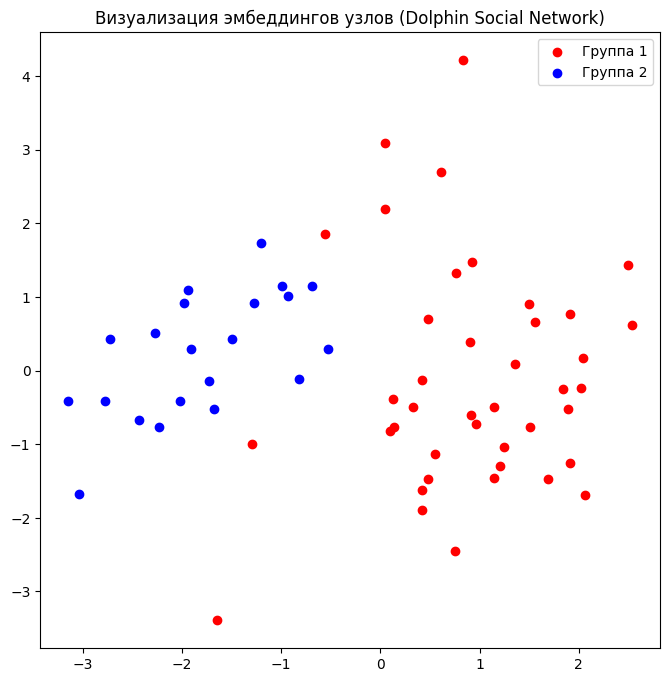

Эпоха 2901, Потеря: 0.0212
Эпоха 2902, Потеря: 0.0212
Эпоха 2903, Потеря: 0.0212
Эпоха 2904, Потеря: 0.0211
Эпоха 2905, Потеря: 0.0211
Эпоха 2906, Потеря: 0.0211
Эпоха 2907, Потеря: 0.0211
Эпоха 2908, Потеря: 0.0211
Эпоха 2909, Потеря: 0.0211
Эпоха 2910, Потеря: 0.0211
Эпоха 2911, Потеря: 0.0211
Эпоха 2912, Потеря: 0.0211
Эпоха 2913, Потеря: 0.0211
Эпоха 2914, Потеря: 0.0210
Эпоха 2915, Потеря: 0.0210
Эпоха 2916, Потеря: 0.0210
Эпоха 2917, Потеря: 0.0210
Эпоха 2918, Потеря: 0.0210
Эпоха 2919, Потеря: 0.0210
Эпоха 2920, Потеря: 0.0210
Эпоха 2921, Потеря: 0.0210
Эпоха 2922, Потеря: 0.0210
Эпоха 2923, Потеря: 0.0210
Эпоха 2924, Потеря: 0.0209
Эпоха 2925, Потеря: 0.0209
Эпоха 2926, Потеря: 0.0209
Эпоха 2927, Потеря: 0.0209
Эпоха 2928, Потеря: 0.0209
Эпоха 2929, Потеря: 0.0209
Эпоха 2930, Потеря: 0.0209
Эпоха 2931, Потеря: 0.0209
Эпоха 2932, Потеря: 0.0209
Эпоха 2933, Потеря: 0.0209
Эпоха 2934, Потеря: 0.0208
Эпоха 2935, Потеря: 0.0208
Эпоха 2936, Потеря: 0.0208
Эпоха 2937, Потеря: 0.0208
Э

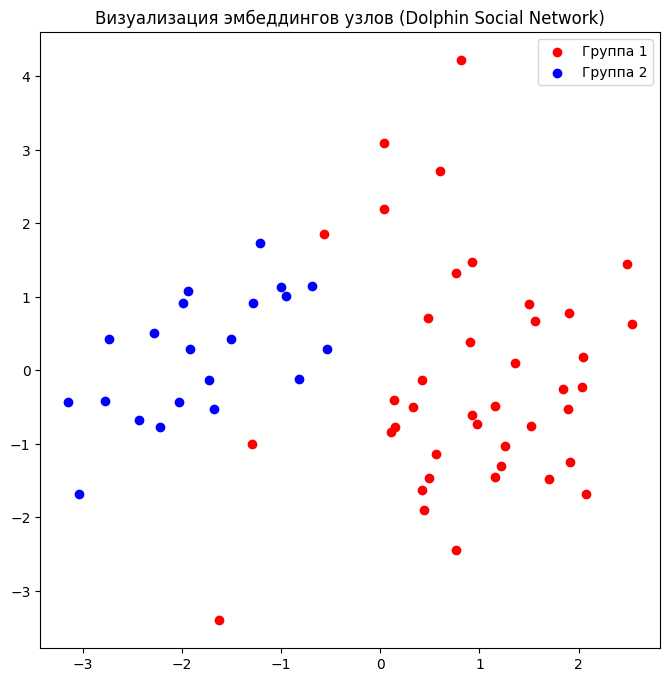

Эпоха 2951, Потеря: 0.0207
Эпоха 2952, Потеря: 0.0207
Эпоха 2953, Потеря: 0.0207
Эпоха 2954, Потеря: 0.0206
Эпоха 2955, Потеря: 0.0206
Эпоха 2956, Потеря: 0.0206
Эпоха 2957, Потеря: 0.0206
Эпоха 2958, Потеря: 0.0206
Эпоха 2959, Потеря: 0.0206
Эпоха 2960, Потеря: 0.0206
Эпоха 2961, Потеря: 0.0206
Эпоха 2962, Потеря: 0.0206
Эпоха 2963, Потеря: 0.0206
Эпоха 2964, Потеря: 0.0206
Эпоха 2965, Потеря: 0.0205
Эпоха 2966, Потеря: 0.0205
Эпоха 2967, Потеря: 0.0205
Эпоха 2968, Потеря: 0.0205
Эпоха 2969, Потеря: 0.0205
Эпоха 2970, Потеря: 0.0205
Эпоха 2971, Потеря: 0.0205
Эпоха 2972, Потеря: 0.0205
Эпоха 2973, Потеря: 0.0205
Эпоха 2974, Потеря: 0.0205
Эпоха 2975, Потеря: 0.0204
Эпоха 2976, Потеря: 0.0204
Эпоха 2977, Потеря: 0.0204
Эпоха 2978, Потеря: 0.0204
Эпоха 2979, Потеря: 0.0204
Эпоха 2980, Потеря: 0.0204
Эпоха 2981, Потеря: 0.0204
Эпоха 2982, Потеря: 0.0204
Эпоха 2983, Потеря: 0.0204
Эпоха 2984, Потеря: 0.0204
Эпоха 2985, Потеря: 0.0204
Эпоха 2986, Потеря: 0.0203
Эпоха 2987, Потеря: 0.0203
Э

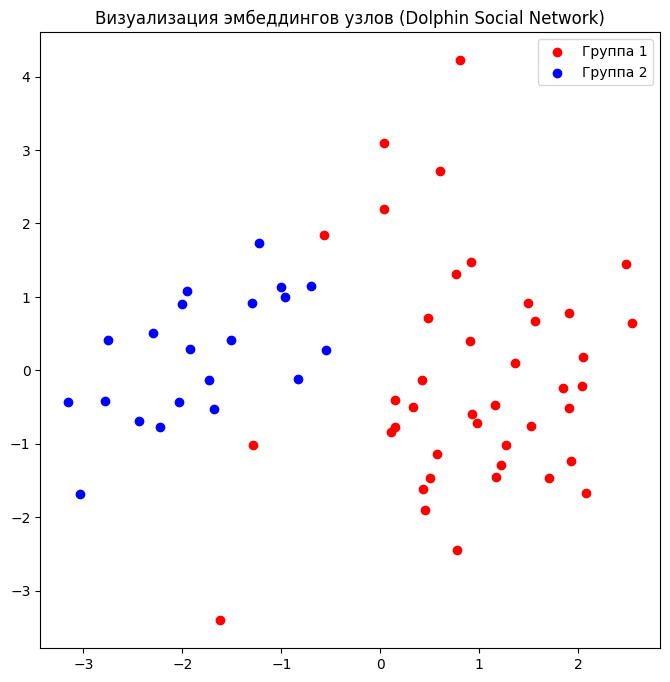

Эпоха 3001, Потеря: 0.0202
Эпоха 3002, Потеря: 0.0202
Эпоха 3003, Потеря: 0.0202
Эпоха 3004, Потеря: 0.0202
Эпоха 3005, Потеря: 0.0202
Эпоха 3006, Потеря: 0.0202
Эпоха 3007, Потеря: 0.0201
Эпоха 3008, Потеря: 0.0201
Эпоха 3009, Потеря: 0.0201
Эпоха 3010, Потеря: 0.0201
Эпоха 3011, Потеря: 0.0201
Эпоха 3012, Потеря: 0.0201
Эпоха 3013, Потеря: 0.0201
Эпоха 3014, Потеря: 0.0201
Эпоха 3015, Потеря: 0.0201
Эпоха 3016, Потеря: 0.0201
Эпоха 3017, Потеря: 0.0201
Эпоха 3018, Потеря: 0.0200
Эпоха 3019, Потеря: 0.0200
Эпоха 3020, Потеря: 0.0200
Эпоха 3021, Потеря: 0.0200
Эпоха 3022, Потеря: 0.0200
Эпоха 3023, Потеря: 0.0200
Эпоха 3024, Потеря: 0.0200
Эпоха 3025, Потеря: 0.0200
Эпоха 3026, Потеря: 0.0200
Эпоха 3027, Потеря: 0.0200
Эпоха 3028, Потеря: 0.0200
Эпоха 3029, Потеря: 0.0199
Эпоха 3030, Потеря: 0.0199
Эпоха 3031, Потеря: 0.0199
Эпоха 3032, Потеря: 0.0199
Эпоха 3033, Потеря: 0.0199
Эпоха 3034, Потеря: 0.0199
Эпоха 3035, Потеря: 0.0199
Эпоха 3036, Потеря: 0.0199
Эпоха 3037, Потеря: 0.0199
Э

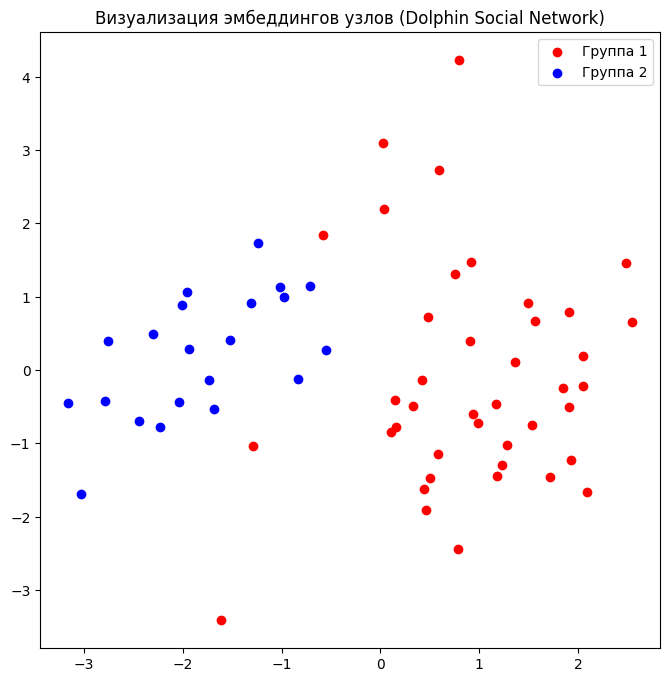

Эпоха 3051, Потеря: 0.0197
Эпоха 3052, Потеря: 0.0197
Эпоха 3053, Потеря: 0.0197
Эпоха 3054, Потеря: 0.0197
Эпоха 3055, Потеря: 0.0197
Эпоха 3056, Потеря: 0.0197
Эпоха 3057, Потеря: 0.0197
Эпоха 3058, Потеря: 0.0197
Эпоха 3059, Потеря: 0.0197
Эпоха 3060, Потеря: 0.0197
Эпоха 3061, Потеря: 0.0197
Эпоха 3062, Потеря: 0.0196
Эпоха 3063, Потеря: 0.0196
Эпоха 3064, Потеря: 0.0196
Эпоха 3065, Потеря: 0.0196
Эпоха 3066, Потеря: 0.0196
Эпоха 3067, Потеря: 0.0196
Эпоха 3068, Потеря: 0.0196
Эпоха 3069, Потеря: 0.0196
Эпоха 3070, Потеря: 0.0196
Эпоха 3071, Потеря: 0.0196
Эпоха 3072, Потеря: 0.0196
Эпоха 3073, Потеря: 0.0196
Эпоха 3074, Потеря: 0.0195
Эпоха 3075, Потеря: 0.0195
Эпоха 3076, Потеря: 0.0195
Эпоха 3077, Потеря: 0.0195
Эпоха 3078, Потеря: 0.0195
Эпоха 3079, Потеря: 0.0195
Эпоха 3080, Потеря: 0.0195
Эпоха 3081, Потеря: 0.0195
Эпоха 3082, Потеря: 0.0195
Эпоха 3083, Потеря: 0.0195
Эпоха 3084, Потеря: 0.0195
Эпоха 3085, Потеря: 0.0194
Эпоха 3086, Потеря: 0.0194
Эпоха 3087, Потеря: 0.0194
Э

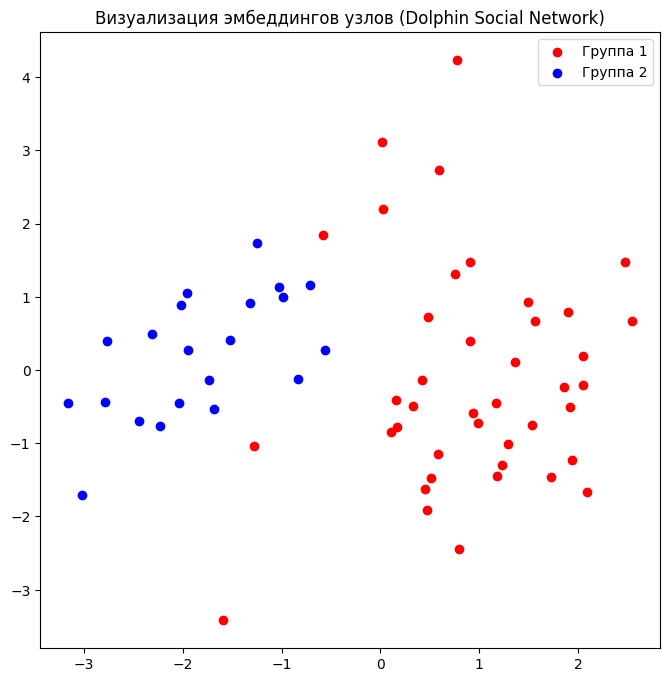

Эпоха 3101, Потеря: 0.0193
Эпоха 3102, Потеря: 0.0193
Эпоха 3103, Потеря: 0.0193
Эпоха 3104, Потеря: 0.0193
Эпоха 3105, Потеря: 0.0193
Эпоха 3106, Потеря: 0.0193
Эпоха 3107, Потеря: 0.0193
Эпоха 3108, Потеря: 0.0192
Эпоха 3109, Потеря: 0.0192
Эпоха 3110, Потеря: 0.0192
Эпоха 3111, Потеря: 0.0192
Эпоха 3112, Потеря: 0.0192
Эпоха 3113, Потеря: 0.0192
Эпоха 3114, Потеря: 0.0192
Эпоха 3115, Потеря: 0.0192
Эпоха 3116, Потеря: 0.0192
Эпоха 3117, Потеря: 0.0192
Эпоха 3118, Потеря: 0.0192
Эпоха 3119, Потеря: 0.0192
Эпоха 3120, Потеря: 0.0191
Эпоха 3121, Потеря: 0.0191
Эпоха 3122, Потеря: 0.0191
Эпоха 3123, Потеря: 0.0191
Эпоха 3124, Потеря: 0.0191
Эпоха 3125, Потеря: 0.0191
Эпоха 3126, Потеря: 0.0191
Эпоха 3127, Потеря: 0.0191
Эпоха 3128, Потеря: 0.0191
Эпоха 3129, Потеря: 0.0191
Эпоха 3130, Потеря: 0.0191
Эпоха 3131, Потеря: 0.0191
Эпоха 3132, Потеря: 0.0190
Эпоха 3133, Потеря: 0.0190
Эпоха 3134, Потеря: 0.0190
Эпоха 3135, Потеря: 0.0190
Эпоха 3136, Потеря: 0.0190
Эпоха 3137, Потеря: 0.0190
Э

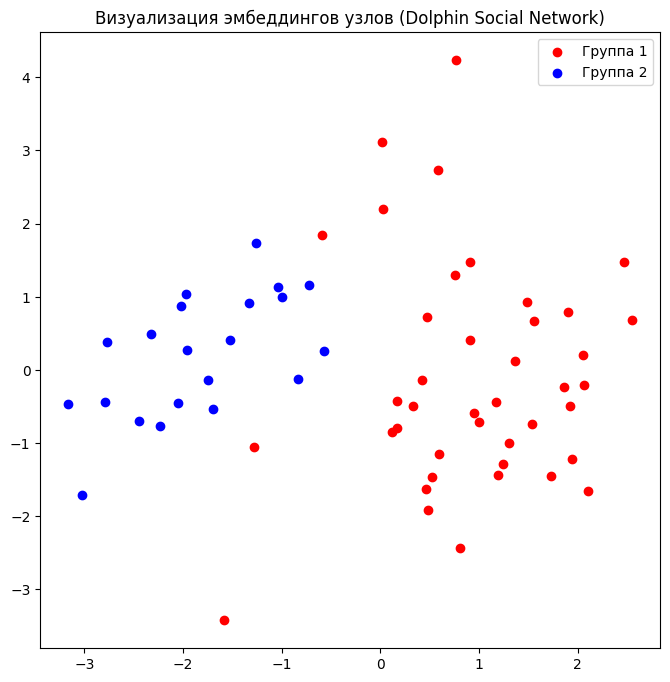

Эпоха 3151, Потеря: 0.0189
Эпоха 3152, Потеря: 0.0189
Эпоха 3153, Потеря: 0.0189
Эпоха 3154, Потеря: 0.0189
Эпоха 3155, Потеря: 0.0189
Эпоха 3156, Потеря: 0.0188
Эпоха 3157, Потеря: 0.0188
Эпоха 3158, Потеря: 0.0188
Эпоха 3159, Потеря: 0.0188
Эпоха 3160, Потеря: 0.0188
Эпоха 3161, Потеря: 0.0188
Эпоха 3162, Потеря: 0.0188
Эпоха 3163, Потеря: 0.0188
Эпоха 3164, Потеря: 0.0188
Эпоха 3165, Потеря: 0.0188
Эпоха 3166, Потеря: 0.0188
Эпоха 3167, Потеря: 0.0188
Эпоха 3168, Потеря: 0.0188
Эпоха 3169, Потеря: 0.0187
Эпоха 3170, Потеря: 0.0187
Эпоха 3171, Потеря: 0.0187
Эпоха 3172, Потеря: 0.0187
Эпоха 3173, Потеря: 0.0187
Эпоха 3174, Потеря: 0.0187
Эпоха 3175, Потеря: 0.0187
Эпоха 3176, Потеря: 0.0187
Эпоха 3177, Потеря: 0.0187
Эпоха 3178, Потеря: 0.0187
Эпоха 3179, Потеря: 0.0187
Эпоха 3180, Потеря: 0.0187
Эпоха 3181, Потеря: 0.0186
Эпоха 3182, Потеря: 0.0186
Эпоха 3183, Потеря: 0.0186
Эпоха 3184, Потеря: 0.0186
Эпоха 3185, Потеря: 0.0186
Эпоха 3186, Потеря: 0.0186
Эпоха 3187, Потеря: 0.0186
Э

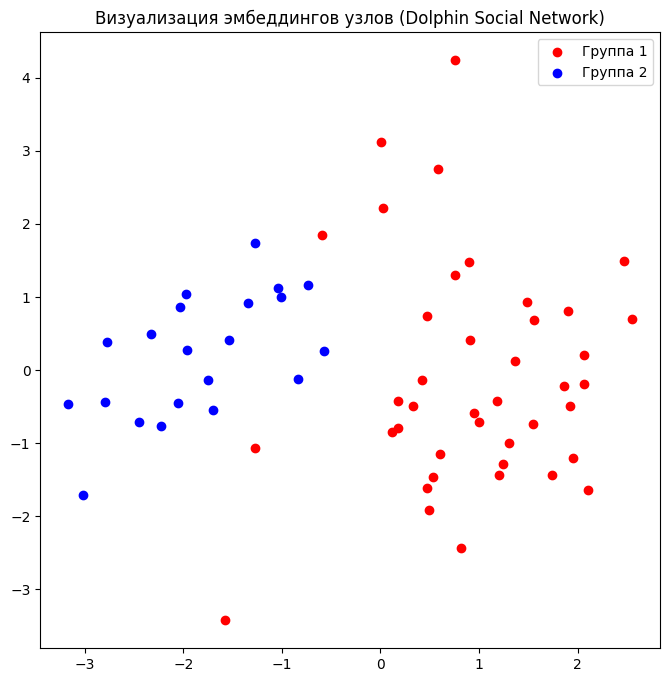

Эпоха 3201, Потеря: 0.0185
Эпоха 3202, Потеря: 0.0185
Эпоха 3203, Потеря: 0.0185
Эпоха 3204, Потеря: 0.0185
Эпоха 3205, Потеря: 0.0185
Эпоха 3206, Потеря: 0.0184
Эпоха 3207, Потеря: 0.0184
Эпоха 3208, Потеря: 0.0184
Эпоха 3209, Потеря: 0.0184
Эпоха 3210, Потеря: 0.0184
Эпоха 3211, Потеря: 0.0184
Эпоха 3212, Потеря: 0.0184
Эпоха 3213, Потеря: 0.0184
Эпоха 3214, Потеря: 0.0184
Эпоха 3215, Потеря: 0.0184
Эпоха 3216, Потеря: 0.0184
Эпоха 3217, Потеря: 0.0184
Эпоха 3218, Потеря: 0.0184
Эпоха 3219, Потеря: 0.0183
Эпоха 3220, Потеря: 0.0183
Эпоха 3221, Потеря: 0.0183
Эпоха 3222, Потеря: 0.0183
Эпоха 3223, Потеря: 0.0183
Эпоха 3224, Потеря: 0.0183
Эпоха 3225, Потеря: 0.0183
Эпоха 3226, Потеря: 0.0183
Эпоха 3227, Потеря: 0.0183
Эпоха 3228, Потеря: 0.0183
Эпоха 3229, Потеря: 0.0183
Эпоха 3230, Потеря: 0.0183
Эпоха 3231, Потеря: 0.0183
Эпоха 3232, Потеря: 0.0182
Эпоха 3233, Потеря: 0.0182
Эпоха 3234, Потеря: 0.0182
Эпоха 3235, Потеря: 0.0182
Эпоха 3236, Потеря: 0.0182
Эпоха 3237, Потеря: 0.0182
Э

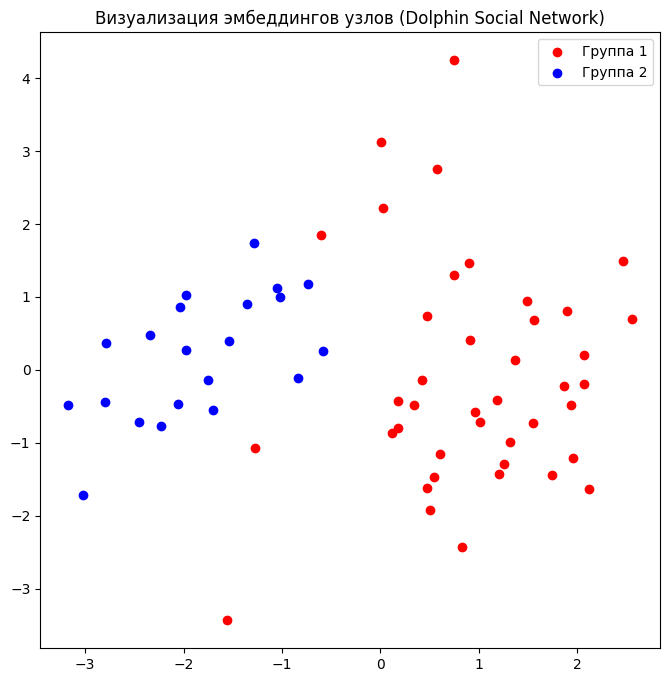

Эпоха 3251, Потеря: 0.0181
Эпоха 3252, Потеря: 0.0181
Эпоха 3253, Потеря: 0.0181
Эпоха 3254, Потеря: 0.0181
Эпоха 3255, Потеря: 0.0181
Эпоха 3256, Потеря: 0.0181
Эпоха 3257, Потеря: 0.0181
Эпоха 3258, Потеря: 0.0180
Эпоха 3259, Потеря: 0.0180
Эпоха 3260, Потеря: 0.0180
Эпоха 3261, Потеря: 0.0180
Эпоха 3262, Потеря: 0.0180
Эпоха 3263, Потеря: 0.0180
Эпоха 3264, Потеря: 0.0180
Эпоха 3265, Потеря: 0.0180
Эпоха 3266, Потеря: 0.0180
Эпоха 3267, Потеря: 0.0180
Эпоха 3268, Потеря: 0.0180
Эпоха 3269, Потеря: 0.0180
Эпоха 3270, Потеря: 0.0180
Эпоха 3271, Потеря: 0.0179
Эпоха 3272, Потеря: 0.0179
Эпоха 3273, Потеря: 0.0179
Эпоха 3274, Потеря: 0.0179
Эпоха 3275, Потеря: 0.0179
Эпоха 3276, Потеря: 0.0179
Эпоха 3277, Потеря: 0.0179
Эпоха 3278, Потеря: 0.0179
Эпоха 3279, Потеря: 0.0179
Эпоха 3280, Потеря: 0.0179
Эпоха 3281, Потеря: 0.0179
Эпоха 3282, Потеря: 0.0179
Эпоха 3283, Потеря: 0.0179
Эпоха 3284, Потеря: 0.0179
Эпоха 3285, Потеря: 0.0178
Эпоха 3286, Потеря: 0.0178
Эпоха 3287, Потеря: 0.0178
Э

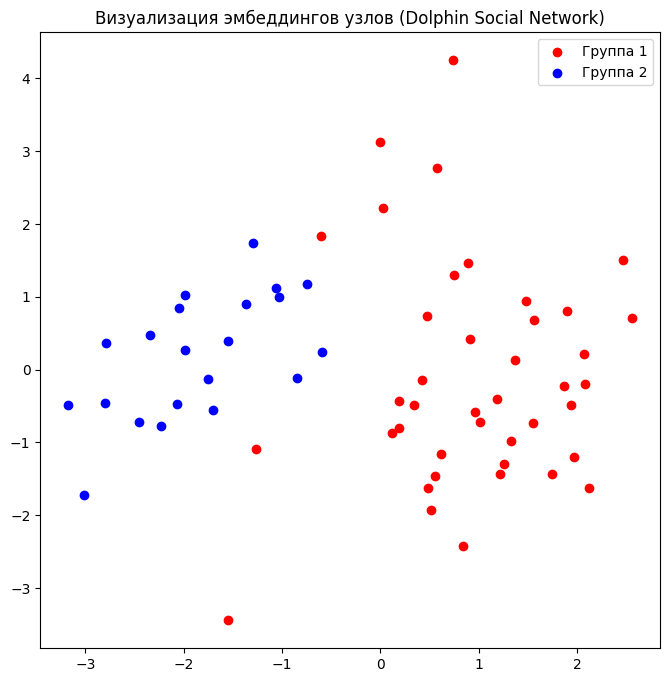

Эпоха 3301, Потеря: 0.0177
Эпоха 3302, Потеря: 0.0177
Эпоха 3303, Потеря: 0.0177
Эпоха 3304, Потеря: 0.0177
Эпоха 3305, Потеря: 0.0177
Эпоха 3306, Потеря: 0.0177
Эпоха 3307, Потеря: 0.0177
Эпоха 3308, Потеря: 0.0177
Эпоха 3309, Потеря: 0.0177
Эпоха 3310, Потеря: 0.0177
Эпоха 3311, Потеря: 0.0177
Эпоха 3312, Потеря: 0.0176
Эпоха 3313, Потеря: 0.0176
Эпоха 3314, Потеря: 0.0176
Эпоха 3315, Потеря: 0.0176
Эпоха 3316, Потеря: 0.0176
Эпоха 3317, Потеря: 0.0176
Эпоха 3318, Потеря: 0.0176
Эпоха 3319, Потеря: 0.0176
Эпоха 3320, Потеря: 0.0176
Эпоха 3321, Потеря: 0.0176
Эпоха 3322, Потеря: 0.0176
Эпоха 3323, Потеря: 0.0176
Эпоха 3324, Потеря: 0.0176
Эпоха 3325, Потеря: 0.0176
Эпоха 3326, Потеря: 0.0175
Эпоха 3327, Потеря: 0.0175
Эпоха 3328, Потеря: 0.0175
Эпоха 3329, Потеря: 0.0175
Эпоха 3330, Потеря: 0.0175
Эпоха 3331, Потеря: 0.0175
Эпоха 3332, Потеря: 0.0175
Эпоха 3333, Потеря: 0.0175
Эпоха 3334, Потеря: 0.0175
Эпоха 3335, Потеря: 0.0175
Эпоха 3336, Потеря: 0.0175
Эпоха 3337, Потеря: 0.0175
Э

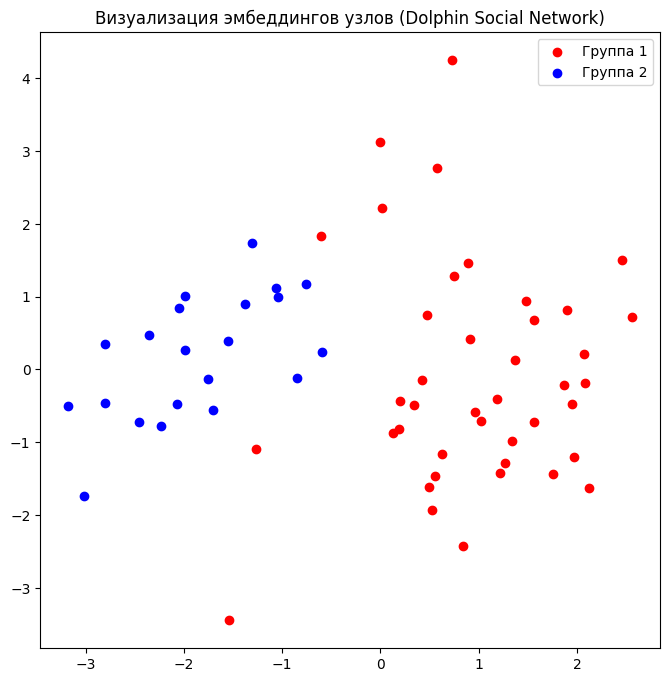

Эпоха 3351, Потеря: 0.0174
Эпоха 3352, Потеря: 0.0174
Эпоха 3353, Потеря: 0.0174
Эпоха 3354, Потеря: 0.0173
Эпоха 3355, Потеря: 0.0173
Эпоха 3356, Потеря: 0.0173
Эпоха 3357, Потеря: 0.0173
Эпоха 3358, Потеря: 0.0173
Эпоха 3359, Потеря: 0.0173
Эпоха 3360, Потеря: 0.0173
Эпоха 3361, Потеря: 0.0173
Эпоха 3362, Потеря: 0.0173
Эпоха 3363, Потеря: 0.0173
Эпоха 3364, Потеря: 0.0173
Эпоха 3365, Потеря: 0.0173
Эпоха 3366, Потеря: 0.0173
Эпоха 3367, Потеря: 0.0173
Эпоха 3368, Потеря: 0.0172
Эпоха 3369, Потеря: 0.0172
Эпоха 3370, Потеря: 0.0172
Эпоха 3371, Потеря: 0.0172
Эпоха 3372, Потеря: 0.0172
Эпоха 3373, Потеря: 0.0172
Эпоха 3374, Потеря: 0.0172
Эпоха 3375, Потеря: 0.0172
Эпоха 3376, Потеря: 0.0172
Эпоха 3377, Потеря: 0.0172
Эпоха 3378, Потеря: 0.0172
Эпоха 3379, Потеря: 0.0172
Эпоха 3380, Потеря: 0.0172
Эпоха 3381, Потеря: 0.0172
Эпоха 3382, Потеря: 0.0172
Эпоха 3383, Потеря: 0.0171
Эпоха 3384, Потеря: 0.0171
Эпоха 3385, Потеря: 0.0171
Эпоха 3386, Потеря: 0.0171
Эпоха 3387, Потеря: 0.0171
Э

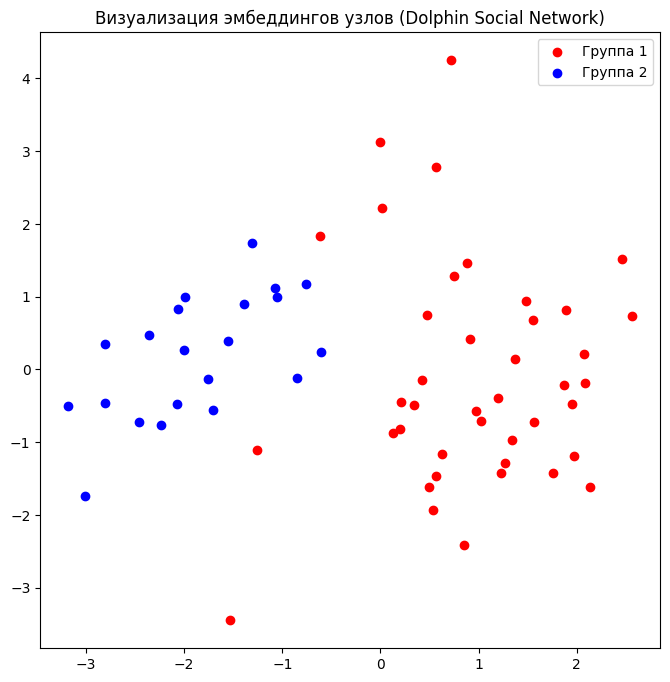

Эпоха 3401, Потеря: 0.0170
Эпоха 3402, Потеря: 0.0170
Эпоха 3403, Потеря: 0.0170
Эпоха 3404, Потеря: 0.0170
Эпоха 3405, Потеря: 0.0170
Эпоха 3406, Потеря: 0.0170
Эпоха 3407, Потеря: 0.0170
Эпоха 3408, Потеря: 0.0170
Эпоха 3409, Потеря: 0.0170
Эпоха 3410, Потеря: 0.0170
Эпоха 3411, Потеря: 0.0170
Эпоха 3412, Потеря: 0.0169
Эпоха 3413, Потеря: 0.0169
Эпоха 3414, Потеря: 0.0169
Эпоха 3415, Потеря: 0.0169
Эпоха 3416, Потеря: 0.0169
Эпоха 3417, Потеря: 0.0169
Эпоха 3418, Потеря: 0.0169
Эпоха 3419, Потеря: 0.0169
Эпоха 3420, Потеря: 0.0169
Эпоха 3421, Потеря: 0.0169
Эпоха 3422, Потеря: 0.0169
Эпоха 3423, Потеря: 0.0169
Эпоха 3424, Потеря: 0.0169
Эпоха 3425, Потеря: 0.0169
Эпоха 3426, Потеря: 0.0169
Эпоха 3427, Потеря: 0.0168
Эпоха 3428, Потеря: 0.0168
Эпоха 3429, Потеря: 0.0168
Эпоха 3430, Потеря: 0.0168
Эпоха 3431, Потеря: 0.0168
Эпоха 3432, Потеря: 0.0168
Эпоха 3433, Потеря: 0.0168
Эпоха 3434, Потеря: 0.0168
Эпоха 3435, Потеря: 0.0168
Эпоха 3436, Потеря: 0.0168
Эпоха 3437, Потеря: 0.0168
Э

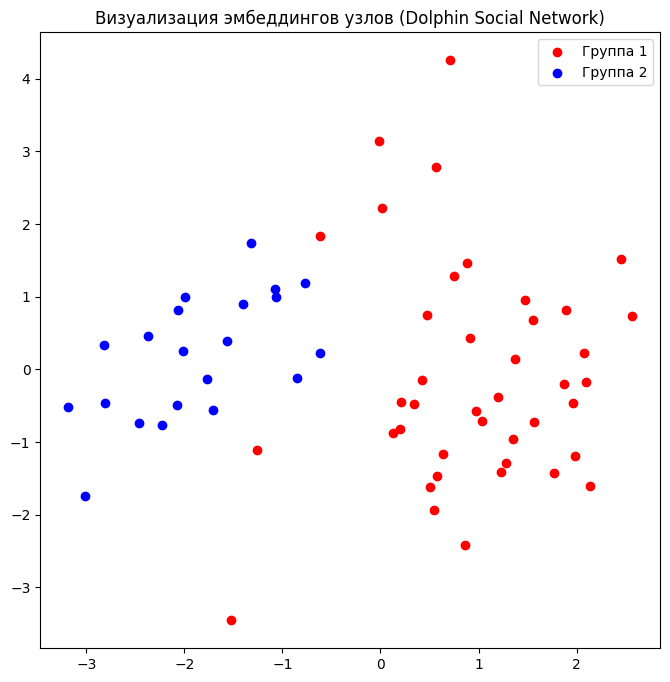

Эпоха 3451, Потеря: 0.0167
Эпоха 3452, Потеря: 0.0167
Эпоха 3453, Потеря: 0.0167
Эпоха 3454, Потеря: 0.0167
Эпоха 3455, Потеря: 0.0167
Эпоха 3456, Потеря: 0.0167
Эпоха 3457, Потеря: 0.0166
Эпоха 3458, Потеря: 0.0166
Эпоха 3459, Потеря: 0.0166
Эпоха 3460, Потеря: 0.0166
Эпоха 3461, Потеря: 0.0166
Эпоха 3462, Потеря: 0.0166
Эпоха 3463, Потеря: 0.0166
Эпоха 3464, Потеря: 0.0166
Эпоха 3465, Потеря: 0.0166
Эпоха 3466, Потеря: 0.0166
Эпоха 3467, Потеря: 0.0166
Эпоха 3468, Потеря: 0.0166
Эпоха 3469, Потеря: 0.0166
Эпоха 3470, Потеря: 0.0166
Эпоха 3471, Потеря: 0.0166
Эпоха 3472, Потеря: 0.0166
Эпоха 3473, Потеря: 0.0165
Эпоха 3474, Потеря: 0.0165
Эпоха 3475, Потеря: 0.0165
Эпоха 3476, Потеря: 0.0165
Эпоха 3477, Потеря: 0.0165
Эпоха 3478, Потеря: 0.0165
Эпоха 3479, Потеря: 0.0165
Эпоха 3480, Потеря: 0.0165
Эпоха 3481, Потеря: 0.0165
Эпоха 3482, Потеря: 0.0165
Эпоха 3483, Потеря: 0.0165
Эпоха 3484, Потеря: 0.0165
Эпоха 3485, Потеря: 0.0165
Эпоха 3486, Потеря: 0.0165
Эпоха 3487, Потеря: 0.0165
Э

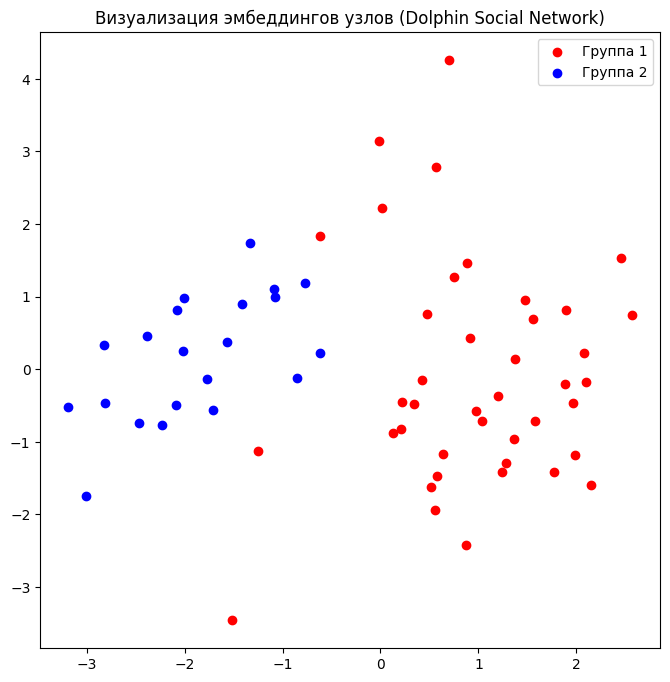

Эпоха 3501, Потеря: 0.0164
Эпоха 3502, Потеря: 0.0164
Эпоха 3503, Потеря: 0.0164
Эпоха 3504, Потеря: 0.0163
Эпоха 3505, Потеря: 0.0163
Эпоха 3506, Потеря: 0.0163
Эпоха 3507, Потеря: 0.0163
Эпоха 3508, Потеря: 0.0163
Эпоха 3509, Потеря: 0.0163
Эпоха 3510, Потеря: 0.0163
Эпоха 3511, Потеря: 0.0163
Эпоха 3512, Потеря: 0.0163
Эпоха 3513, Потеря: 0.0163
Эпоха 3514, Потеря: 0.0163
Эпоха 3515, Потеря: 0.0163
Эпоха 3516, Потеря: 0.0163
Эпоха 3517, Потеря: 0.0163
Эпоха 3518, Потеря: 0.0163
Эпоха 3519, Потеря: 0.0163
Эпоха 3520, Потеря: 0.0162
Эпоха 3521, Потеря: 0.0162
Эпоха 3522, Потеря: 0.0162
Эпоха 3523, Потеря: 0.0162
Эпоха 3524, Потеря: 0.0162
Эпоха 3525, Потеря: 0.0162
Эпоха 3526, Потеря: 0.0162
Эпоха 3527, Потеря: 0.0162
Эпоха 3528, Потеря: 0.0162
Эпоха 3529, Потеря: 0.0162
Эпоха 3530, Потеря: 0.0162
Эпоха 3531, Потеря: 0.0162
Эпоха 3532, Потеря: 0.0162
Эпоха 3533, Потеря: 0.0162
Эпоха 3534, Потеря: 0.0162
Эпоха 3535, Потеря: 0.0162
Эпоха 3536, Потеря: 0.0161
Эпоха 3537, Потеря: 0.0161
Э

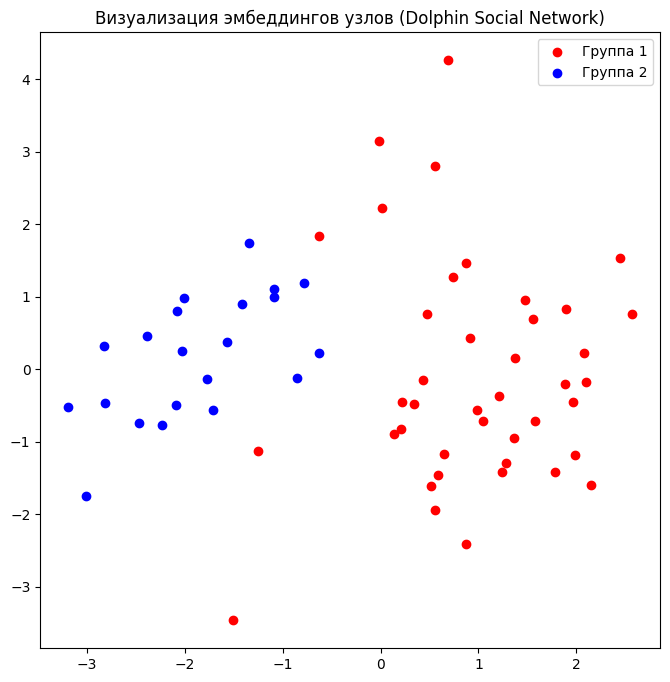

Эпоха 3551, Потеря: 0.0161
Эпоха 3552, Потеря: 0.0160
Эпоха 3553, Потеря: 0.0160
Эпоха 3554, Потеря: 0.0160
Эпоха 3555, Потеря: 0.0160
Эпоха 3556, Потеря: 0.0160
Эпоха 3557, Потеря: 0.0160
Эпоха 3558, Потеря: 0.0160
Эпоха 3559, Потеря: 0.0160
Эпоха 3560, Потеря: 0.0160
Эпоха 3561, Потеря: 0.0160
Эпоха 3562, Потеря: 0.0160
Эпоха 3563, Потеря: 0.0160
Эпоха 3564, Потеря: 0.0160
Эпоха 3565, Потеря: 0.0160
Эпоха 3566, Потеря: 0.0160
Эпоха 3567, Потеря: 0.0160
Эпоха 3568, Потеря: 0.0160
Эпоха 3569, Потеря: 0.0159
Эпоха 3570, Потеря: 0.0159
Эпоха 3571, Потеря: 0.0159
Эпоха 3572, Потеря: 0.0159
Эпоха 3573, Потеря: 0.0159
Эпоха 3574, Потеря: 0.0159
Эпоха 3575, Потеря: 0.0159
Эпоха 3576, Потеря: 0.0159
Эпоха 3577, Потеря: 0.0159
Эпоха 3578, Потеря: 0.0159
Эпоха 3579, Потеря: 0.0159
Эпоха 3580, Потеря: 0.0159
Эпоха 3581, Потеря: 0.0159
Эпоха 3582, Потеря: 0.0159
Эпоха 3583, Потеря: 0.0159
Эпоха 3584, Потеря: 0.0159
Эпоха 3585, Потеря: 0.0158
Эпоха 3586, Потеря: 0.0158
Эпоха 3587, Потеря: 0.0158
Э

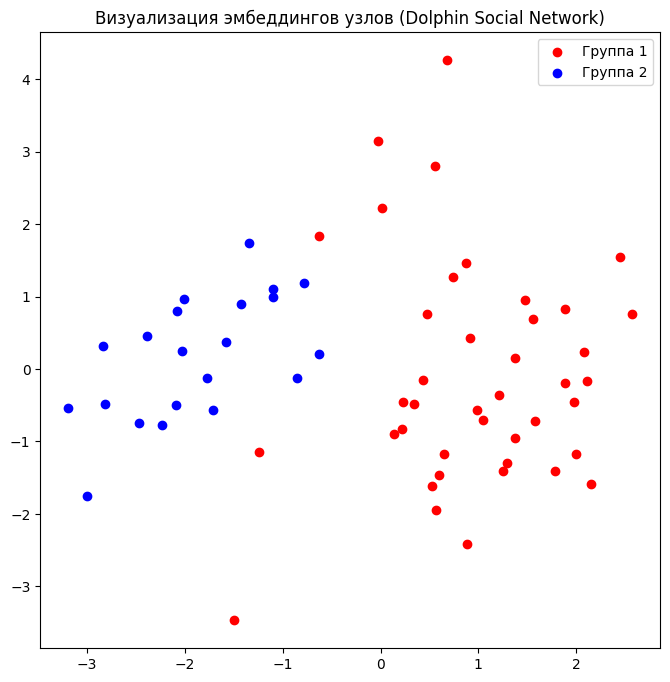

Эпоха 3601, Потеря: 0.0158
Эпоха 3602, Потеря: 0.0157
Эпоха 3603, Потеря: 0.0157
Эпоха 3604, Потеря: 0.0157
Эпоха 3605, Потеря: 0.0157
Эпоха 3606, Потеря: 0.0157
Эпоха 3607, Потеря: 0.0157
Эпоха 3608, Потеря: 0.0157
Эпоха 3609, Потеря: 0.0157
Эпоха 3610, Потеря: 0.0157
Эпоха 3611, Потеря: 0.0157
Эпоха 3612, Потеря: 0.0157
Эпоха 3613, Потеря: 0.0157
Эпоха 3614, Потеря: 0.0157
Эпоха 3615, Потеря: 0.0157
Эпоха 3616, Потеря: 0.0157
Эпоха 3617, Потеря: 0.0157
Эпоха 3618, Потеря: 0.0157
Эпоха 3619, Потеря: 0.0156
Эпоха 3620, Потеря: 0.0156
Эпоха 3621, Потеря: 0.0156
Эпоха 3622, Потеря: 0.0156
Эпоха 3623, Потеря: 0.0156
Эпоха 3624, Потеря: 0.0156
Эпоха 3625, Потеря: 0.0156
Эпоха 3626, Потеря: 0.0156
Эпоха 3627, Потеря: 0.0156
Эпоха 3628, Потеря: 0.0156
Эпоха 3629, Потеря: 0.0156
Эпоха 3630, Потеря: 0.0156
Эпоха 3631, Потеря: 0.0156
Эпоха 3632, Потеря: 0.0156
Эпоха 3633, Потеря: 0.0156
Эпоха 3634, Потеря: 0.0156
Эпоха 3635, Потеря: 0.0156
Эпоха 3636, Потеря: 0.0156
Эпоха 3637, Потеря: 0.0155
Э

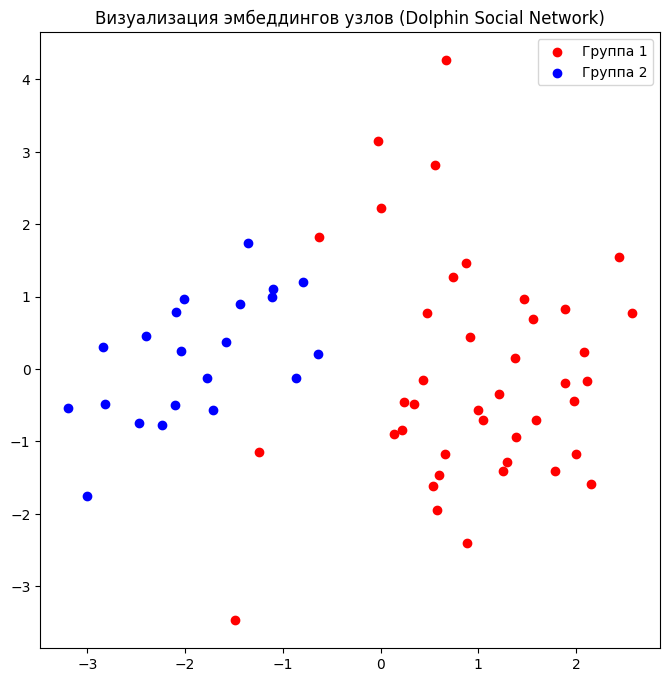

Эпоха 3651, Потеря: 0.0155
Эпоха 3652, Потеря: 0.0155
Эпоха 3653, Потеря: 0.0155
Эпоха 3654, Потеря: 0.0154
Эпоха 3655, Потеря: 0.0154
Эпоха 3656, Потеря: 0.0154
Эпоха 3657, Потеря: 0.0154
Эпоха 3658, Потеря: 0.0154
Эпоха 3659, Потеря: 0.0154
Эпоха 3660, Потеря: 0.0154
Эпоха 3661, Потеря: 0.0154
Эпоха 3662, Потеря: 0.0154
Эпоха 3663, Потеря: 0.0154
Эпоха 3664, Потеря: 0.0154
Эпоха 3665, Потеря: 0.0154
Эпоха 3666, Потеря: 0.0154
Эпоха 3667, Потеря: 0.0154
Эпоха 3668, Потеря: 0.0154
Эпоха 3669, Потеря: 0.0154
Эпоха 3670, Потеря: 0.0154
Эпоха 3671, Потеря: 0.0154
Эпоха 3672, Потеря: 0.0153
Эпоха 3673, Потеря: 0.0153
Эпоха 3674, Потеря: 0.0153
Эпоха 3675, Потеря: 0.0153
Эпоха 3676, Потеря: 0.0153
Эпоха 3677, Потеря: 0.0153
Эпоха 3678, Потеря: 0.0153
Эпоха 3679, Потеря: 0.0153
Эпоха 3680, Потеря: 0.0153
Эпоха 3681, Потеря: 0.0153
Эпоха 3682, Потеря: 0.0153
Эпоха 3683, Потеря: 0.0153
Эпоха 3684, Потеря: 0.0153
Эпоха 3685, Потеря: 0.0153
Эпоха 3686, Потеря: 0.0153
Эпоха 3687, Потеря: 0.0153
Э

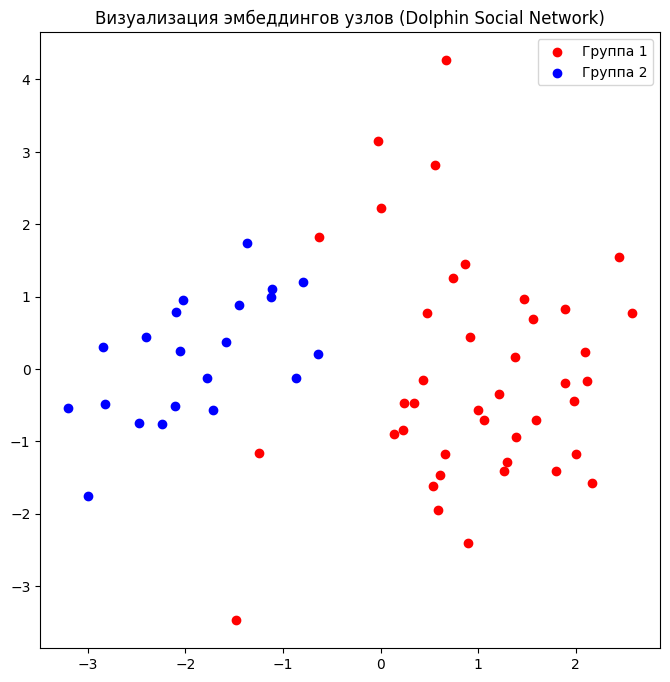

Эпоха 3701, Потеря: 0.0152
Эпоха 3702, Потеря: 0.0152
Эпоха 3703, Потеря: 0.0152
Эпоха 3704, Потеря: 0.0152
Эпоха 3705, Потеря: 0.0152
Эпоха 3706, Потеря: 0.0152
Эпоха 3707, Потеря: 0.0152
Эпоха 3708, Потеря: 0.0151
Эпоха 3709, Потеря: 0.0151
Эпоха 3710, Потеря: 0.0151
Эпоха 3711, Потеря: 0.0151
Эпоха 3712, Потеря: 0.0151
Эпоха 3713, Потеря: 0.0151
Эпоха 3714, Потеря: 0.0151
Эпоха 3715, Потеря: 0.0151
Эпоха 3716, Потеря: 0.0151
Эпоха 3717, Потеря: 0.0151
Эпоха 3718, Потеря: 0.0151
Эпоха 3719, Потеря: 0.0151
Эпоха 3720, Потеря: 0.0151
Эпоха 3721, Потеря: 0.0151
Эпоха 3722, Потеря: 0.0151
Эпоха 3723, Потеря: 0.0151
Эпоха 3724, Потеря: 0.0151
Эпоха 3725, Потеря: 0.0151
Эпоха 3726, Потеря: 0.0150
Эпоха 3727, Потеря: 0.0150
Эпоха 3728, Потеря: 0.0150
Эпоха 3729, Потеря: 0.0150
Эпоха 3730, Потеря: 0.0150
Эпоха 3731, Потеря: 0.0150
Эпоха 3732, Потеря: 0.0150
Эпоха 3733, Потеря: 0.0150
Эпоха 3734, Потеря: 0.0150
Эпоха 3735, Потеря: 0.0150
Эпоха 3736, Потеря: 0.0150
Эпоха 3737, Потеря: 0.0150
Э

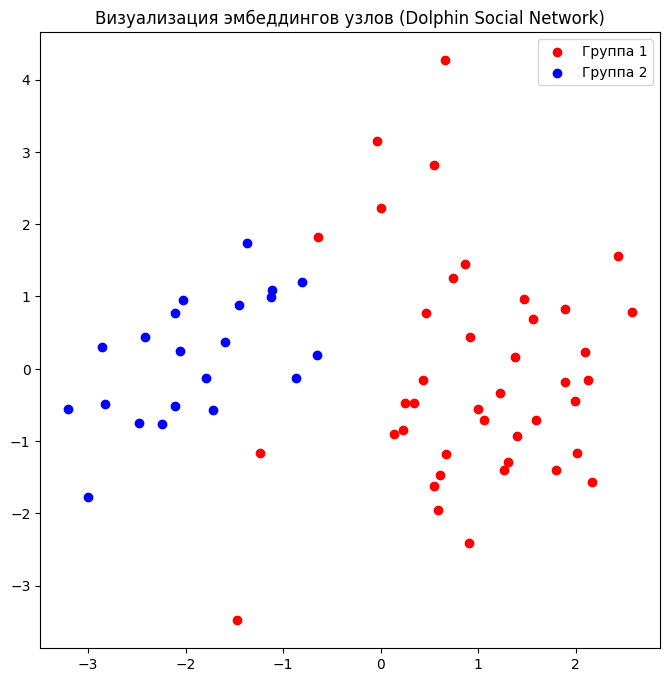

Эпоха 3751, Потеря: 0.0149
Эпоха 3752, Потеря: 0.0149
Эпоха 3753, Потеря: 0.0149
Эпоха 3754, Потеря: 0.0149
Эпоха 3755, Потеря: 0.0149
Эпоха 3756, Потеря: 0.0149
Эпоха 3757, Потеря: 0.0149
Эпоха 3758, Потеря: 0.0149
Эпоха 3759, Потеря: 0.0149
Эпоха 3760, Потеря: 0.0149
Эпоха 3761, Потеря: 0.0149
Эпоха 3762, Потеря: 0.0149
Эпоха 3763, Потеря: 0.0148
Эпоха 3764, Потеря: 0.0148
Эпоха 3765, Потеря: 0.0148
Эпоха 3766, Потеря: 0.0148
Эпоха 3767, Потеря: 0.0148
Эпоха 3768, Потеря: 0.0148
Эпоха 3769, Потеря: 0.0148
Эпоха 3770, Потеря: 0.0148
Эпоха 3771, Потеря: 0.0148
Эпоха 3772, Потеря: 0.0148
Эпоха 3773, Потеря: 0.0148
Эпоха 3774, Потеря: 0.0148
Эпоха 3775, Потеря: 0.0148
Эпоха 3776, Потеря: 0.0148
Эпоха 3777, Потеря: 0.0148
Эпоха 3778, Потеря: 0.0148
Эпоха 3779, Потеря: 0.0148
Эпоха 3780, Потеря: 0.0148
Эпоха 3781, Потеря: 0.0148
Эпоха 3782, Потеря: 0.0147
Эпоха 3783, Потеря: 0.0147
Эпоха 3784, Потеря: 0.0147
Эпоха 3785, Потеря: 0.0147
Эпоха 3786, Потеря: 0.0147
Эпоха 3787, Потеря: 0.0147
Э

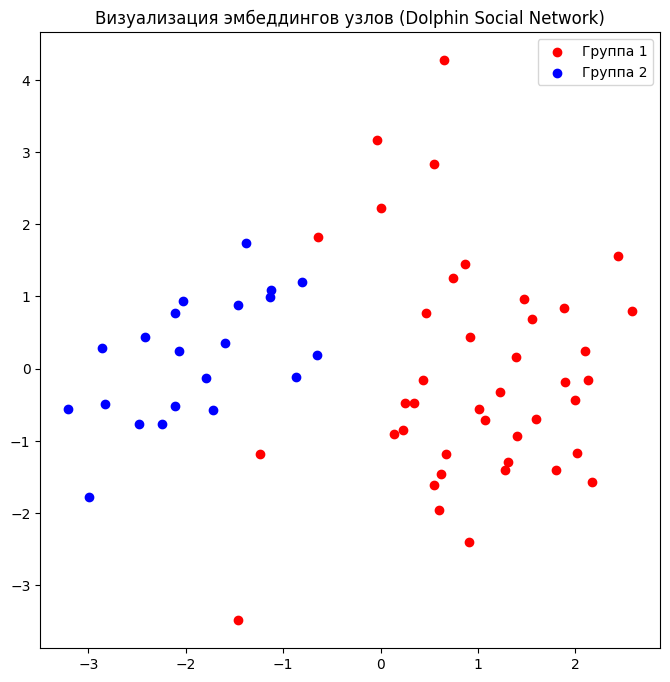

Эпоха 3801, Потеря: 0.0147
Эпоха 3802, Потеря: 0.0146
Эпоха 3803, Потеря: 0.0146
Эпоха 3804, Потеря: 0.0146
Эпоха 3805, Потеря: 0.0146
Эпоха 3806, Потеря: 0.0146
Эпоха 3807, Потеря: 0.0146
Эпоха 3808, Потеря: 0.0146
Эпоха 3809, Потеря: 0.0146
Эпоха 3810, Потеря: 0.0146
Эпоха 3811, Потеря: 0.0146
Эпоха 3812, Потеря: 0.0146
Эпоха 3813, Потеря: 0.0146
Эпоха 3814, Потеря: 0.0146
Эпоха 3815, Потеря: 0.0146
Эпоха 3816, Потеря: 0.0146
Эпоха 3817, Потеря: 0.0146
Эпоха 3818, Потеря: 0.0146
Эпоха 3819, Потеря: 0.0146
Эпоха 3820, Потеря: 0.0146
Эпоха 3821, Потеря: 0.0145
Эпоха 3822, Потеря: 0.0145
Эпоха 3823, Потеря: 0.0145
Эпоха 3824, Потеря: 0.0145
Эпоха 3825, Потеря: 0.0145
Эпоха 3826, Потеря: 0.0145
Эпоха 3827, Потеря: 0.0145
Эпоха 3828, Потеря: 0.0145
Эпоха 3829, Потеря: 0.0145
Эпоха 3830, Потеря: 0.0145
Эпоха 3831, Потеря: 0.0145
Эпоха 3832, Потеря: 0.0145
Эпоха 3833, Потеря: 0.0145
Эпоха 3834, Потеря: 0.0145
Эпоха 3835, Потеря: 0.0145
Эпоха 3836, Потеря: 0.0145
Эпоха 3837, Потеря: 0.0145
Э

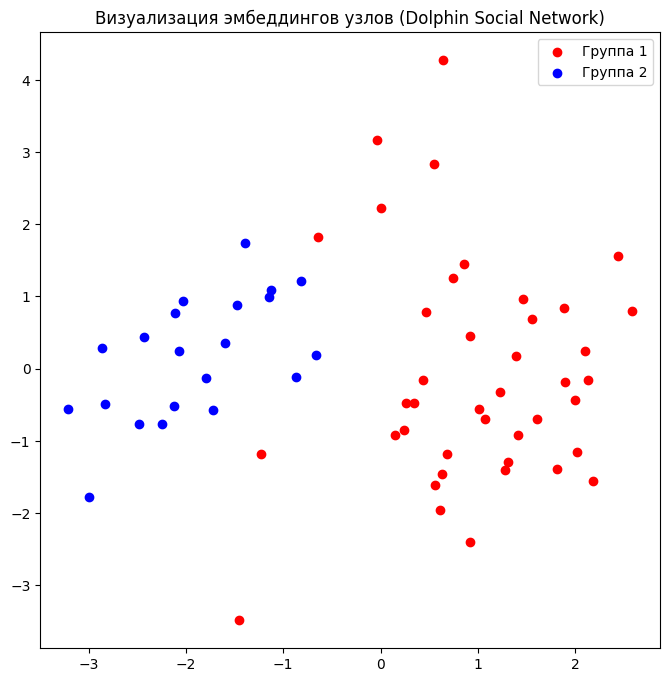

Эпоха 3851, Потеря: 0.0144
Эпоха 3852, Потеря: 0.0144
Эпоха 3853, Потеря: 0.0144
Эпоха 3854, Потеря: 0.0144
Эпоха 3855, Потеря: 0.0144
Эпоха 3856, Потеря: 0.0144
Эпоха 3857, Потеря: 0.0144
Эпоха 3858, Потеря: 0.0144
Эпоха 3859, Потеря: 0.0144
Эпоха 3860, Потеря: 0.0144
Эпоха 3861, Потеря: 0.0143
Эпоха 3862, Потеря: 0.0143
Эпоха 3863, Потеря: 0.0143
Эпоха 3864, Потеря: 0.0143
Эпоха 3865, Потеря: 0.0143
Эпоха 3866, Потеря: 0.0143
Эпоха 3867, Потеря: 0.0143
Эпоха 3868, Потеря: 0.0143
Эпоха 3869, Потеря: 0.0143
Эпоха 3870, Потеря: 0.0143
Эпоха 3871, Потеря: 0.0143
Эпоха 3872, Потеря: 0.0143
Эпоха 3873, Потеря: 0.0143
Эпоха 3874, Потеря: 0.0143
Эпоха 3875, Потеря: 0.0143
Эпоха 3876, Потеря: 0.0143
Эпоха 3877, Потеря: 0.0143
Эпоха 3878, Потеря: 0.0143
Эпоха 3879, Потеря: 0.0143
Эпоха 3880, Потеря: 0.0143
Эпоха 3881, Потеря: 0.0142
Эпоха 3882, Потеря: 0.0142
Эпоха 3883, Потеря: 0.0142
Эпоха 3884, Потеря: 0.0142
Эпоха 3885, Потеря: 0.0142
Эпоха 3886, Потеря: 0.0142
Эпоха 3887, Потеря: 0.0142
Э

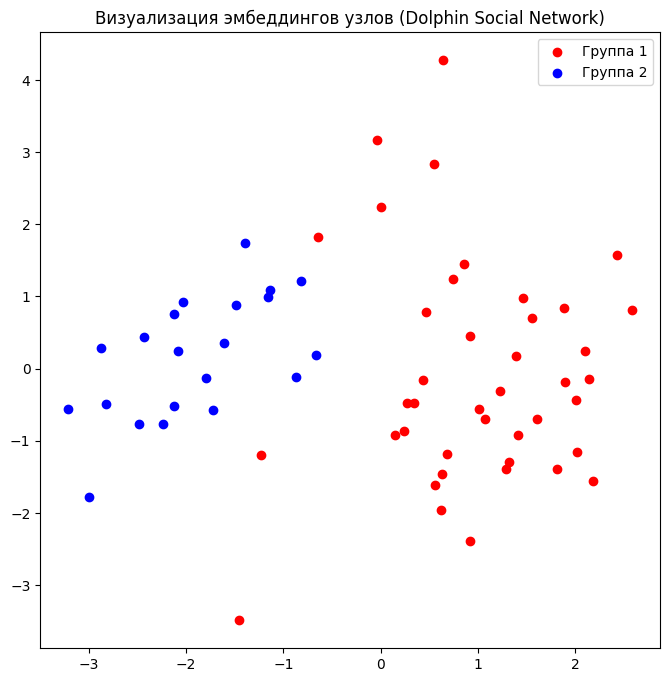

Эпоха 3901, Потеря: 0.0142
Эпоха 3902, Потеря: 0.0141
Эпоха 3903, Потеря: 0.0141
Эпоха 3904, Потеря: 0.0141
Эпоха 3905, Потеря: 0.0141
Эпоха 3906, Потеря: 0.0141
Эпоха 3907, Потеря: 0.0141
Эпоха 3908, Потеря: 0.0141
Эпоха 3909, Потеря: 0.0141
Эпоха 3910, Потеря: 0.0141
Эпоха 3911, Потеря: 0.0141
Эпоха 3912, Потеря: 0.0141
Эпоха 3913, Потеря: 0.0141
Эпоха 3914, Потеря: 0.0141
Эпоха 3915, Потеря: 0.0141
Эпоха 3916, Потеря: 0.0141
Эпоха 3917, Потеря: 0.0141
Эпоха 3918, Потеря: 0.0141
Эпоха 3919, Потеря: 0.0141
Эпоха 3920, Потеря: 0.0141
Эпоха 3921, Потеря: 0.0141
Эпоха 3922, Потеря: 0.0140
Эпоха 3923, Потеря: 0.0140
Эпоха 3924, Потеря: 0.0140
Эпоха 3925, Потеря: 0.0140
Эпоха 3926, Потеря: 0.0140
Эпоха 3927, Потеря: 0.0140
Эпоха 3928, Потеря: 0.0140
Эпоха 3929, Потеря: 0.0140
Эпоха 3930, Потеря: 0.0140
Эпоха 3931, Потеря: 0.0140
Эпоха 3932, Потеря: 0.0140
Эпоха 3933, Потеря: 0.0140
Эпоха 3934, Потеря: 0.0140
Эпоха 3935, Потеря: 0.0140
Эпоха 3936, Потеря: 0.0140
Эпоха 3937, Потеря: 0.0140
Э

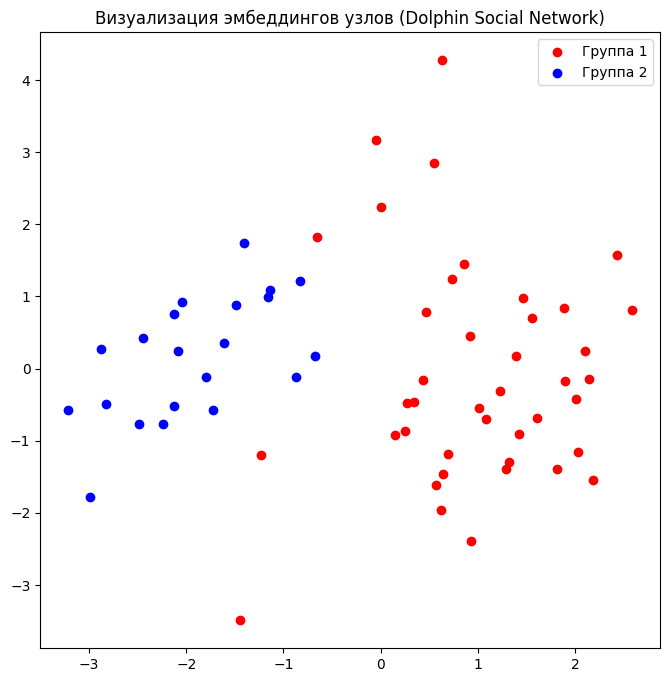

Эпоха 3951, Потеря: 0.0139
Эпоха 3952, Потеря: 0.0139
Эпоха 3953, Потеря: 0.0139
Эпоха 3954, Потеря: 0.0139
Эпоха 3955, Потеря: 0.0139
Эпоха 3956, Потеря: 0.0139
Эпоха 3957, Потеря: 0.0139
Эпоха 3958, Потеря: 0.0139
Эпоха 3959, Потеря: 0.0139
Эпоха 3960, Потеря: 0.0139
Эпоха 3961, Потеря: 0.0139
Эпоха 3962, Потеря: 0.0139
Эпоха 3963, Потеря: 0.0139
Эпоха 3964, Потеря: 0.0139
Эпоха 3965, Потеря: 0.0138
Эпоха 3966, Потеря: 0.0138
Эпоха 3967, Потеря: 0.0138
Эпоха 3968, Потеря: 0.0138
Эпоха 3969, Потеря: 0.0138
Эпоха 3970, Потеря: 0.0138
Эпоха 3971, Потеря: 0.0138
Эпоха 3972, Потеря: 0.0138
Эпоха 3973, Потеря: 0.0138
Эпоха 3974, Потеря: 0.0138
Эпоха 3975, Потеря: 0.0138
Эпоха 3976, Потеря: 0.0138
Эпоха 3977, Потеря: 0.0138
Эпоха 3978, Потеря: 0.0138
Эпоха 3979, Потеря: 0.0138
Эпоха 3980, Потеря: 0.0138
Эпоха 3981, Потеря: 0.0138
Эпоха 3982, Потеря: 0.0138
Эпоха 3983, Потеря: 0.0138
Эпоха 3984, Потеря: 0.0138
Эпоха 3985, Потеря: 0.0138
Эпоха 3986, Потеря: 0.0137
Эпоха 3987, Потеря: 0.0137
Э

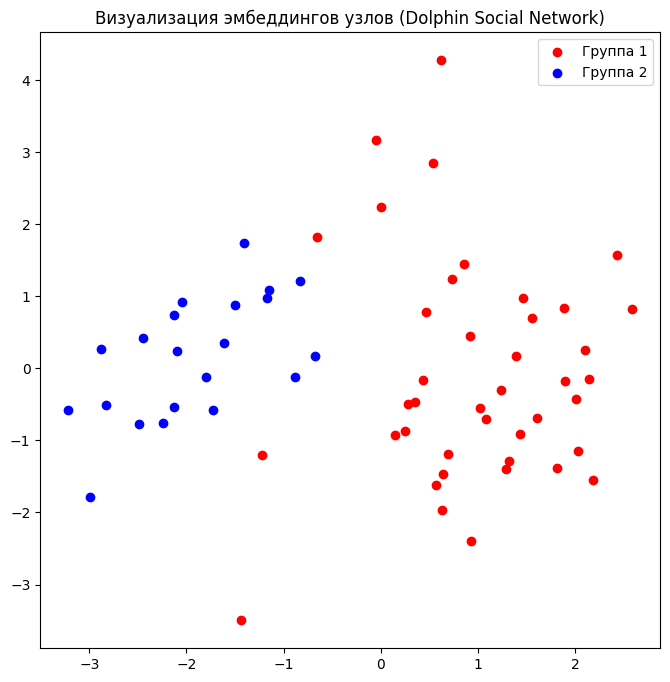

Эпоха 4001, Потеря: 0.0137
Эпоха 4002, Потеря: 0.0137
Эпоха 4003, Потеря: 0.0137
Эпоха 4004, Потеря: 0.0137
Эпоха 4005, Потеря: 0.0137
Эпоха 4006, Потеря: 0.0137
Эпоха 4007, Потеря: 0.0137
Эпоха 4008, Потеря: 0.0136
Эпоха 4009, Потеря: 0.0136
Эпоха 4010, Потеря: 0.0136
Эпоха 4011, Потеря: 0.0136
Эпоха 4012, Потеря: 0.0136
Эпоха 4013, Потеря: 0.0136
Эпоха 4014, Потеря: 0.0136
Эпоха 4015, Потеря: 0.0136
Эпоха 4016, Потеря: 0.0136
Эпоха 4017, Потеря: 0.0136
Эпоха 4018, Потеря: 0.0136
Эпоха 4019, Потеря: 0.0136
Эпоха 4020, Потеря: 0.0136
Эпоха 4021, Потеря: 0.0136
Эпоха 4022, Потеря: 0.0136
Эпоха 4023, Потеря: 0.0136
Эпоха 4024, Потеря: 0.0136
Эпоха 4025, Потеря: 0.0136
Эпоха 4026, Потеря: 0.0136
Эпоха 4027, Потеря: 0.0136
Эпоха 4028, Потеря: 0.0136
Эпоха 4029, Потеря: 0.0136
Эпоха 4030, Потеря: 0.0136
Эпоха 4031, Потеря: 0.0135
Эпоха 4032, Потеря: 0.0135
Эпоха 4033, Потеря: 0.0135
Эпоха 4034, Потеря: 0.0135
Эпоха 4035, Потеря: 0.0135
Эпоха 4036, Потеря: 0.0135
Эпоха 4037, Потеря: 0.0135
Э

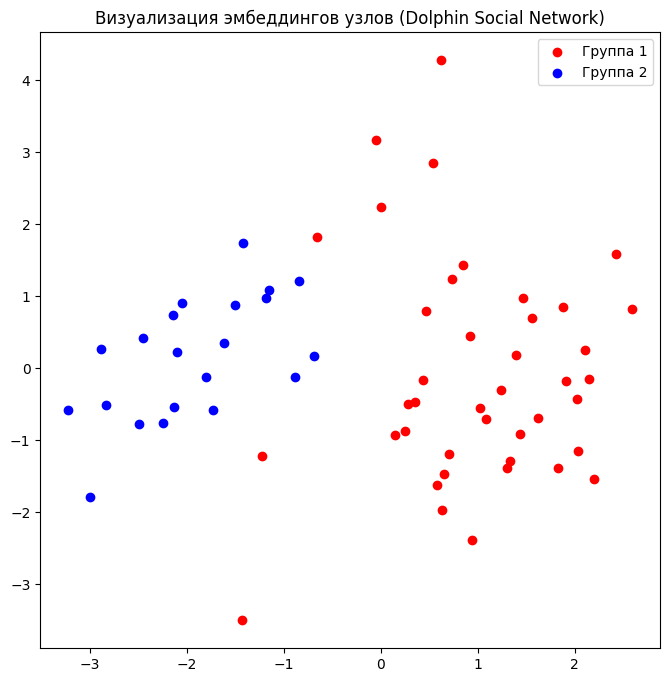

Эпоха 4051, Потеря: 0.0135
Эпоха 4052, Потеря: 0.0135
Эпоха 4053, Потеря: 0.0134
Эпоха 4054, Потеря: 0.0134
Эпоха 4055, Потеря: 0.0134
Эпоха 4056, Потеря: 0.0134
Эпоха 4057, Потеря: 0.0134
Эпоха 4058, Потеря: 0.0134
Эпоха 4059, Потеря: 0.0134
Эпоха 4060, Потеря: 0.0134
Эпоха 4061, Потеря: 0.0134
Эпоха 4062, Потеря: 0.0134
Эпоха 4063, Потеря: 0.0134
Эпоха 4064, Потеря: 0.0134
Эпоха 4065, Потеря: 0.0134
Эпоха 4066, Потеря: 0.0134
Эпоха 4067, Потеря: 0.0134
Эпоха 4068, Потеря: 0.0134
Эпоха 4069, Потеря: 0.0134
Эпоха 4070, Потеря: 0.0134
Эпоха 4071, Потеря: 0.0134
Эпоха 4072, Потеря: 0.0134
Эпоха 4073, Потеря: 0.0134
Эпоха 4074, Потеря: 0.0134
Эпоха 4075, Потеря: 0.0134
Эпоха 4076, Потеря: 0.0133
Эпоха 4077, Потеря: 0.0133
Эпоха 4078, Потеря: 0.0133
Эпоха 4079, Потеря: 0.0133
Эпоха 4080, Потеря: 0.0133
Эпоха 4081, Потеря: 0.0133
Эпоха 4082, Потеря: 0.0133
Эпоха 4083, Потеря: 0.0133
Эпоха 4084, Потеря: 0.0133
Эпоха 4085, Потеря: 0.0133
Эпоха 4086, Потеря: 0.0133
Эпоха 4087, Потеря: 0.0133
Э

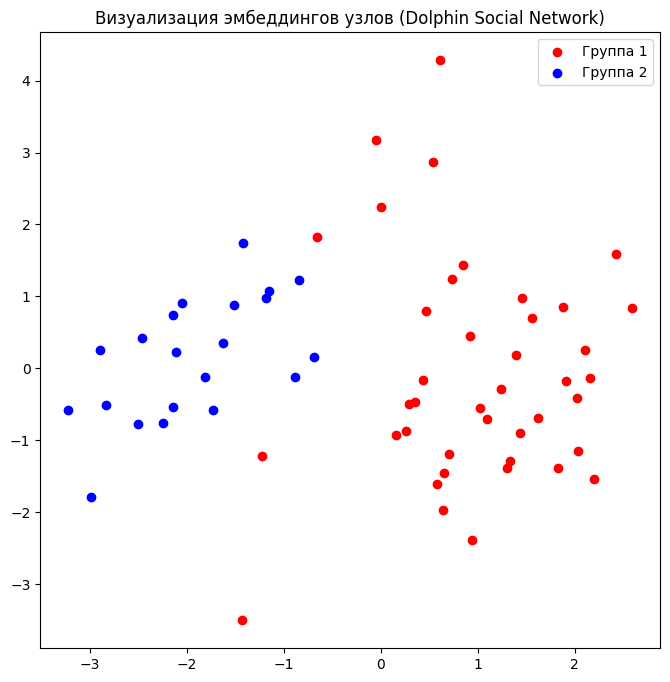

Эпоха 4101, Потеря: 0.0132
Эпоха 4102, Потеря: 0.0132
Эпоха 4103, Потеря: 0.0132
Эпоха 4104, Потеря: 0.0132
Эпоха 4105, Потеря: 0.0132
Эпоха 4106, Потеря: 0.0132
Эпоха 4107, Потеря: 0.0132
Эпоха 4108, Потеря: 0.0132
Эпоха 4109, Потеря: 0.0132
Эпоха 4110, Потеря: 0.0132
Эпоха 4111, Потеря: 0.0132
Эпоха 4112, Потеря: 0.0132
Эпоха 4113, Потеря: 0.0132
Эпоха 4114, Потеря: 0.0132
Эпоха 4115, Потеря: 0.0132
Эпоха 4116, Потеря: 0.0132
Эпоха 4117, Потеря: 0.0132
Эпоха 4118, Потеря: 0.0132
Эпоха 4119, Потеря: 0.0132
Эпоха 4120, Потеря: 0.0132
Эпоха 4121, Потеря: 0.0132
Эпоха 4122, Потеря: 0.0131
Эпоха 4123, Потеря: 0.0131
Эпоха 4124, Потеря: 0.0131
Эпоха 4125, Потеря: 0.0131
Эпоха 4126, Потеря: 0.0131
Эпоха 4127, Потеря: 0.0131
Эпоха 4128, Потеря: 0.0131
Эпоха 4129, Потеря: 0.0131
Эпоха 4130, Потеря: 0.0131
Эпоха 4131, Потеря: 0.0131
Эпоха 4132, Потеря: 0.0131
Эпоха 4133, Потеря: 0.0131
Эпоха 4134, Потеря: 0.0131
Эпоха 4135, Потеря: 0.0131
Эпоха 4136, Потеря: 0.0131
Эпоха 4137, Потеря: 0.0131
Э

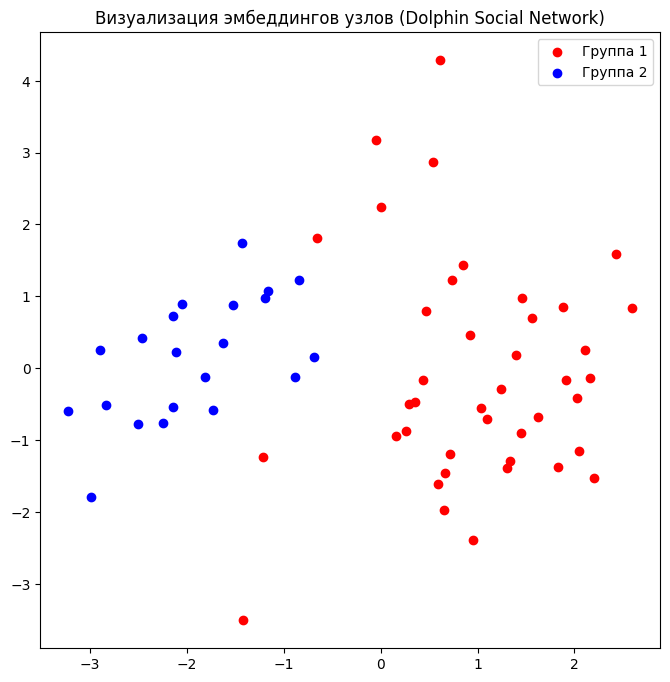

Эпоха 4151, Потеря: 0.0130
Эпоха 4152, Потеря: 0.0130
Эпоха 4153, Потеря: 0.0130
Эпоха 4154, Потеря: 0.0130
Эпоха 4155, Потеря: 0.0130
Эпоха 4156, Потеря: 0.0130
Эпоха 4157, Потеря: 0.0130
Эпоха 4158, Потеря: 0.0130
Эпоха 4159, Потеря: 0.0130
Эпоха 4160, Потеря: 0.0130
Эпоха 4161, Потеря: 0.0130
Эпоха 4162, Потеря: 0.0130
Эпоха 4163, Потеря: 0.0130
Эпоха 4164, Потеря: 0.0130
Эпоха 4165, Потеря: 0.0130
Эпоха 4166, Потеря: 0.0130
Эпоха 4167, Потеря: 0.0130
Эпоха 4168, Потеря: 0.0130
Эпоха 4169, Потеря: 0.0130
Эпоха 4170, Потеря: 0.0129
Эпоха 4171, Потеря: 0.0129
Эпоха 4172, Потеря: 0.0129
Эпоха 4173, Потеря: 0.0129
Эпоха 4174, Потеря: 0.0129
Эпоха 4175, Потеря: 0.0129
Эпоха 4176, Потеря: 0.0129
Эпоха 4177, Потеря: 0.0129
Эпоха 4178, Потеря: 0.0129
Эпоха 4179, Потеря: 0.0129
Эпоха 4180, Потеря: 0.0129
Эпоха 4181, Потеря: 0.0129
Эпоха 4182, Потеря: 0.0129
Эпоха 4183, Потеря: 0.0129
Эпоха 4184, Потеря: 0.0129
Эпоха 4185, Потеря: 0.0129
Эпоха 4186, Потеря: 0.0129
Эпоха 4187, Потеря: 0.0129
Э

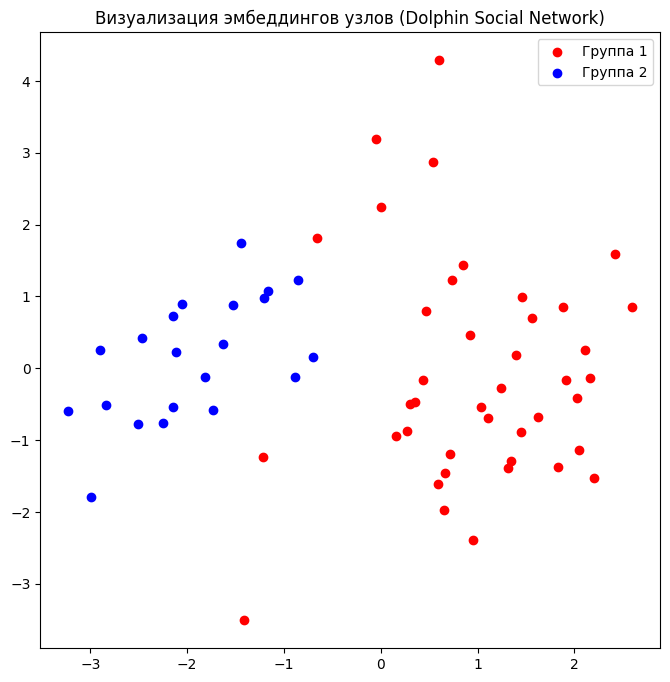

Эпоха 4201, Потеря: 0.0128
Эпоха 4202, Потеря: 0.0128
Эпоха 4203, Потеря: 0.0128
Эпоха 4204, Потеря: 0.0128
Эпоха 4205, Потеря: 0.0128
Эпоха 4206, Потеря: 0.0128
Эпоха 4207, Потеря: 0.0128
Эпоха 4208, Потеря: 0.0128
Эпоха 4209, Потеря: 0.0128
Эпоха 4210, Потеря: 0.0128
Эпоха 4211, Потеря: 0.0128
Эпоха 4212, Потеря: 0.0128
Эпоха 4213, Потеря: 0.0128
Эпоха 4214, Потеря: 0.0128
Эпоха 4215, Потеря: 0.0128
Эпоха 4216, Потеря: 0.0128
Эпоха 4217, Потеря: 0.0128
Эпоха 4218, Потеря: 0.0128
Эпоха 4219, Потеря: 0.0128
Эпоха 4220, Потеря: 0.0127
Эпоха 4221, Потеря: 0.0127
Эпоха 4222, Потеря: 0.0127
Эпоха 4223, Потеря: 0.0127
Эпоха 4224, Потеря: 0.0127
Эпоха 4225, Потеря: 0.0127
Эпоха 4226, Потеря: 0.0127
Эпоха 4227, Потеря: 0.0127
Эпоха 4228, Потеря: 0.0127
Эпоха 4229, Потеря: 0.0127
Эпоха 4230, Потеря: 0.0127
Эпоха 4231, Потеря: 0.0127
Эпоха 4232, Потеря: 0.0127
Эпоха 4233, Потеря: 0.0127
Эпоха 4234, Потеря: 0.0127
Эпоха 4235, Потеря: 0.0127
Эпоха 4236, Потеря: 0.0127
Эпоха 4237, Потеря: 0.0127
Э

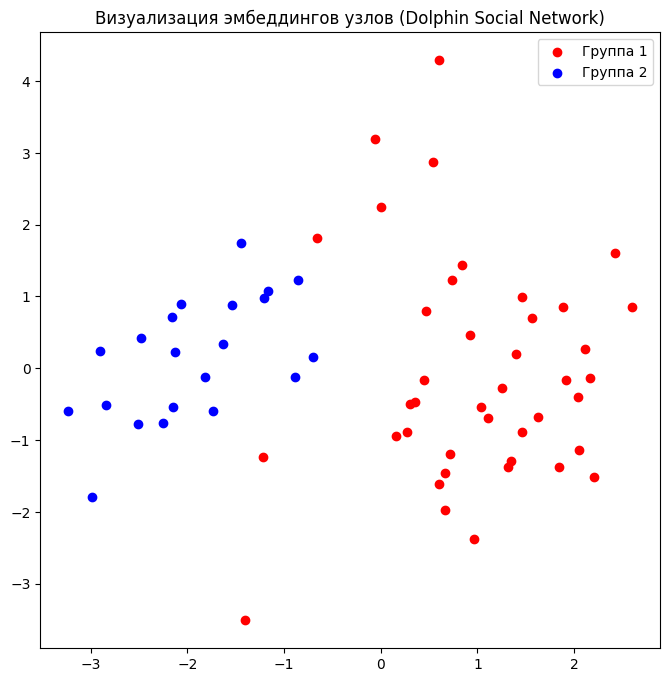

Эпоха 4251, Потеря: 0.0126
Эпоха 4252, Потеря: 0.0126
Эпоха 4253, Потеря: 0.0126
Эпоха 4254, Потеря: 0.0126
Эпоха 4255, Потеря: 0.0126
Эпоха 4256, Потеря: 0.0126
Эпоха 4257, Потеря: 0.0126
Эпоха 4258, Потеря: 0.0126
Эпоха 4259, Потеря: 0.0126
Эпоха 4260, Потеря: 0.0126
Эпоха 4261, Потеря: 0.0126
Эпоха 4262, Потеря: 0.0126
Эпоха 4263, Потеря: 0.0126
Эпоха 4264, Потеря: 0.0126
Эпоха 4265, Потеря: 0.0126
Эпоха 4266, Потеря: 0.0126
Эпоха 4267, Потеря: 0.0126
Эпоха 4268, Потеря: 0.0126
Эпоха 4269, Потеря: 0.0126
Эпоха 4270, Потеря: 0.0125
Эпоха 4271, Потеря: 0.0125
Эпоха 4272, Потеря: 0.0125
Эпоха 4273, Потеря: 0.0125
Эпоха 4274, Потеря: 0.0125
Эпоха 4275, Потеря: 0.0125
Эпоха 4276, Потеря: 0.0125
Эпоха 4277, Потеря: 0.0125
Эпоха 4278, Потеря: 0.0125
Эпоха 4279, Потеря: 0.0125
Эпоха 4280, Потеря: 0.0125
Эпоха 4281, Потеря: 0.0125
Эпоха 4282, Потеря: 0.0125
Эпоха 4283, Потеря: 0.0125
Эпоха 4284, Потеря: 0.0125
Эпоха 4285, Потеря: 0.0125
Эпоха 4286, Потеря: 0.0125
Эпоха 4287, Потеря: 0.0125
Э

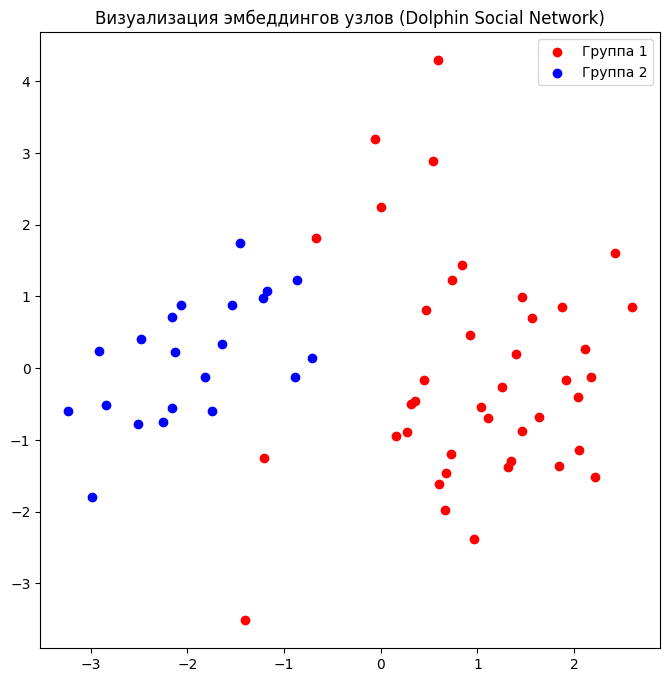

Эпоха 4301, Потеря: 0.0124
Эпоха 4302, Потеря: 0.0124
Эпоха 4303, Потеря: 0.0124
Эпоха 4304, Потеря: 0.0124
Эпоха 4305, Потеря: 0.0124
Эпоха 4306, Потеря: 0.0124
Эпоха 4307, Потеря: 0.0124
Эпоха 4308, Потеря: 0.0124
Эпоха 4309, Потеря: 0.0124
Эпоха 4310, Потеря: 0.0124
Эпоха 4311, Потеря: 0.0124
Эпоха 4312, Потеря: 0.0124
Эпоха 4313, Потеря: 0.0124
Эпоха 4314, Потеря: 0.0124
Эпоха 4315, Потеря: 0.0124
Эпоха 4316, Потеря: 0.0124
Эпоха 4317, Потеря: 0.0124
Эпоха 4318, Потеря: 0.0124
Эпоха 4319, Потеря: 0.0124
Эпоха 4320, Потеря: 0.0124
Эпоха 4321, Потеря: 0.0124
Эпоха 4322, Потеря: 0.0124
Эпоха 4323, Потеря: 0.0123
Эпоха 4324, Потеря: 0.0123
Эпоха 4325, Потеря: 0.0123
Эпоха 4326, Потеря: 0.0123
Эпоха 4327, Потеря: 0.0123
Эпоха 4328, Потеря: 0.0123
Эпоха 4329, Потеря: 0.0123
Эпоха 4330, Потеря: 0.0123
Эпоха 4331, Потеря: 0.0123
Эпоха 4332, Потеря: 0.0123
Эпоха 4333, Потеря: 0.0123
Эпоха 4334, Потеря: 0.0123
Эпоха 4335, Потеря: 0.0123
Эпоха 4336, Потеря: 0.0123
Эпоха 4337, Потеря: 0.0123
Э

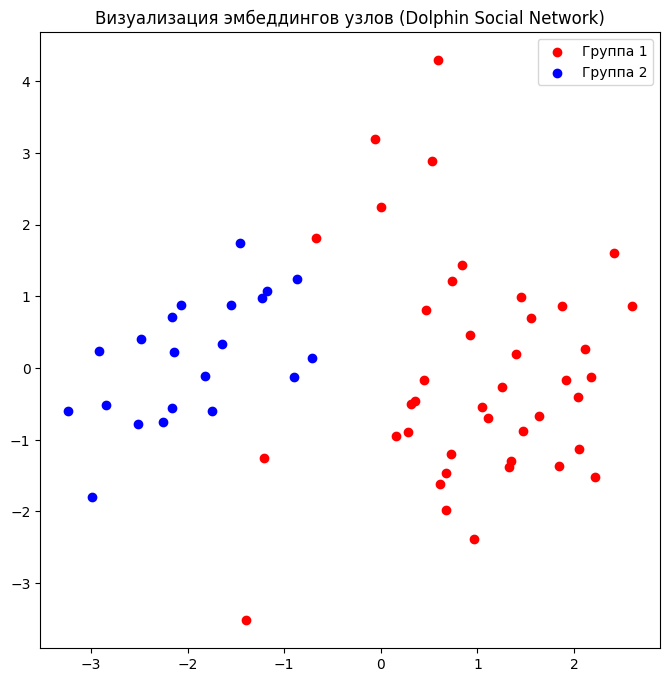

Эпоха 4351, Потеря: 0.0122
Эпоха 4352, Потеря: 0.0122
Эпоха 4353, Потеря: 0.0122
Эпоха 4354, Потеря: 0.0122
Эпоха 4355, Потеря: 0.0122
Эпоха 4356, Потеря: 0.0122
Эпоха 4357, Потеря: 0.0122
Эпоха 4358, Потеря: 0.0122
Эпоха 4359, Потеря: 0.0122
Эпоха 4360, Потеря: 0.0122
Эпоха 4361, Потеря: 0.0122
Эпоха 4362, Потеря: 0.0122
Эпоха 4363, Потеря: 0.0122
Эпоха 4364, Потеря: 0.0122
Эпоха 4365, Потеря: 0.0122
Эпоха 4366, Потеря: 0.0122
Эпоха 4367, Потеря: 0.0122
Эпоха 4368, Потеря: 0.0122
Эпоха 4369, Потеря: 0.0122
Эпоха 4370, Потеря: 0.0122
Эпоха 4371, Потеря: 0.0122
Эпоха 4372, Потеря: 0.0122
Эпоха 4373, Потеря: 0.0122
Эпоха 4374, Потеря: 0.0122
Эпоха 4375, Потеря: 0.0122
Эпоха 4376, Потеря: 0.0121
Эпоха 4377, Потеря: 0.0121
Эпоха 4378, Потеря: 0.0121
Эпоха 4379, Потеря: 0.0121
Эпоха 4380, Потеря: 0.0121
Эпоха 4381, Потеря: 0.0121
Эпоха 4382, Потеря: 0.0121
Эпоха 4383, Потеря: 0.0121
Эпоха 4384, Потеря: 0.0121
Эпоха 4385, Потеря: 0.0121
Эпоха 4386, Потеря: 0.0121
Эпоха 4387, Потеря: 0.0121
Э

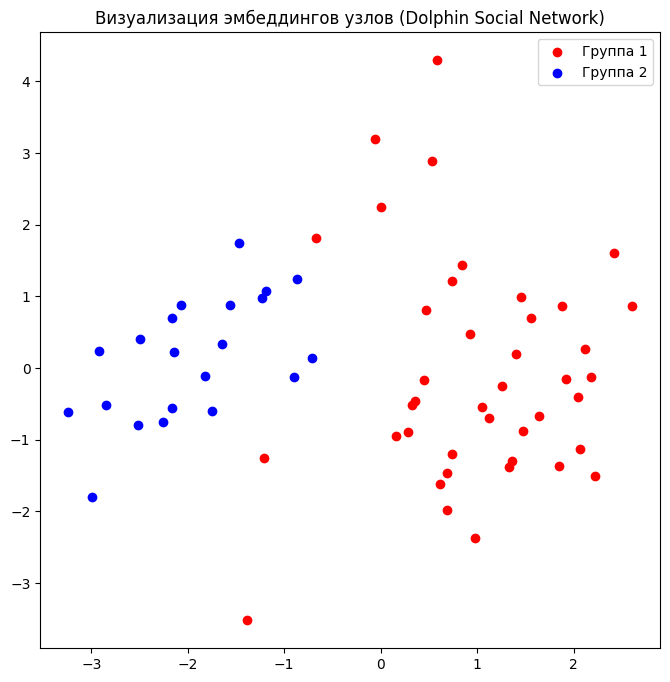

Эпоха 4401, Потеря: 0.0121
Эпоха 4402, Потеря: 0.0121
Эпоха 4403, Потеря: 0.0121
Эпоха 4404, Потеря: 0.0120
Эпоха 4405, Потеря: 0.0120
Эпоха 4406, Потеря: 0.0120
Эпоха 4407, Потеря: 0.0120
Эпоха 4408, Потеря: 0.0120
Эпоха 4409, Потеря: 0.0120
Эпоха 4410, Потеря: 0.0120
Эпоха 4411, Потеря: 0.0120
Эпоха 4412, Потеря: 0.0120
Эпоха 4413, Потеря: 0.0120
Эпоха 4414, Потеря: 0.0120
Эпоха 4415, Потеря: 0.0120
Эпоха 4416, Потеря: 0.0120
Эпоха 4417, Потеря: 0.0120
Эпоха 4418, Потеря: 0.0120
Эпоха 4419, Потеря: 0.0120
Эпоха 4420, Потеря: 0.0120
Эпоха 4421, Потеря: 0.0120
Эпоха 4422, Потеря: 0.0120
Эпоха 4423, Потеря: 0.0120
Эпоха 4424, Потеря: 0.0120
Эпоха 4425, Потеря: 0.0120
Эпоха 4426, Потеря: 0.0120
Эпоха 4427, Потеря: 0.0120
Эпоха 4428, Потеря: 0.0120
Эпоха 4429, Потеря: 0.0120
Эпоха 4430, Потеря: 0.0120
Эпоха 4431, Потеря: 0.0120
Эпоха 4432, Потеря: 0.0119
Эпоха 4433, Потеря: 0.0119
Эпоха 4434, Потеря: 0.0119
Эпоха 4435, Потеря: 0.0119
Эпоха 4436, Потеря: 0.0119
Эпоха 4437, Потеря: 0.0119
Э

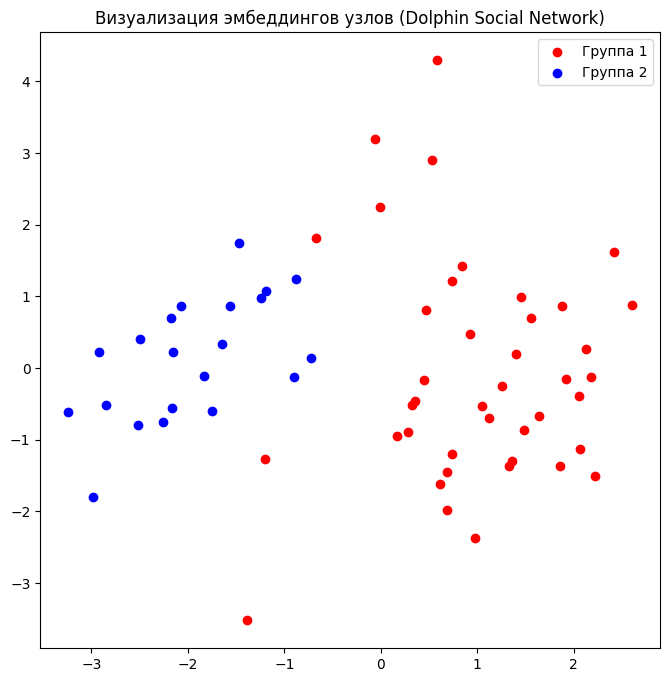

Эпоха 4451, Потеря: 0.0119
Эпоха 4452, Потеря: 0.0119
Эпоха 4453, Потеря: 0.0119
Эпоха 4454, Потеря: 0.0119
Эпоха 4455, Потеря: 0.0119
Эпоха 4456, Потеря: 0.0119
Эпоха 4457, Потеря: 0.0119
Эпоха 4458, Потеря: 0.0119
Эпоха 4459, Потеря: 0.0119
Эпоха 4460, Потеря: 0.0118
Эпоха 4461, Потеря: 0.0118
Эпоха 4462, Потеря: 0.0118
Эпоха 4463, Потеря: 0.0118
Эпоха 4464, Потеря: 0.0118
Эпоха 4465, Потеря: 0.0118
Эпоха 4466, Потеря: 0.0118
Эпоха 4467, Потеря: 0.0118
Эпоха 4468, Потеря: 0.0118
Эпоха 4469, Потеря: 0.0118
Эпоха 4470, Потеря: 0.0118
Эпоха 4471, Потеря: 0.0118
Эпоха 4472, Потеря: 0.0118
Эпоха 4473, Потеря: 0.0118
Эпоха 4474, Потеря: 0.0118
Эпоха 4475, Потеря: 0.0118
Эпоха 4476, Потеря: 0.0118
Эпоха 4477, Потеря: 0.0118
Эпоха 4478, Потеря: 0.0118
Эпоха 4479, Потеря: 0.0118
Эпоха 4480, Потеря: 0.0118
Эпоха 4481, Потеря: 0.0118
Эпоха 4482, Потеря: 0.0118
Эпоха 4483, Потеря: 0.0118
Эпоха 4484, Потеря: 0.0118
Эпоха 4485, Потеря: 0.0118
Эпоха 4486, Потеря: 0.0118
Эпоха 4487, Потеря: 0.0118
Э

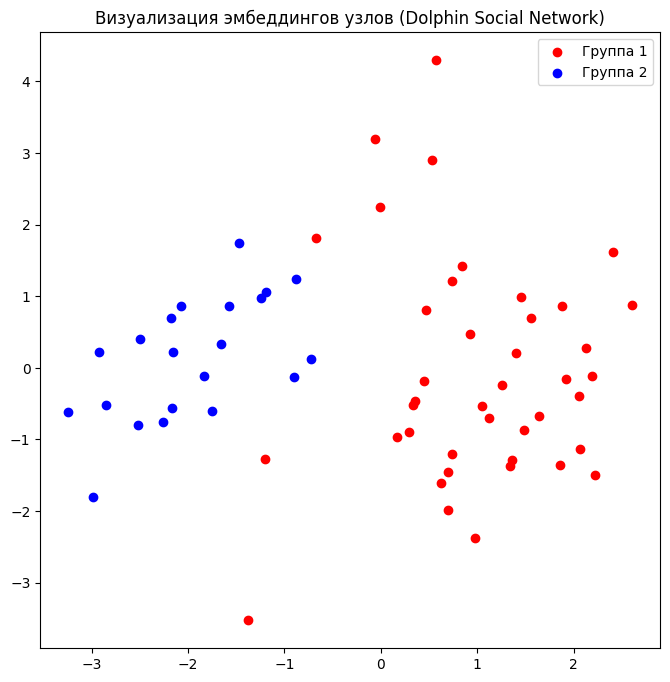

Эпоха 4501, Потеря: 0.0117
Эпоха 4502, Потеря: 0.0117
Эпоха 4503, Потеря: 0.0117
Эпоха 4504, Потеря: 0.0117
Эпоха 4505, Потеря: 0.0117
Эпоха 4506, Потеря: 0.0117
Эпоха 4507, Потеря: 0.0117
Эпоха 4508, Потеря: 0.0117
Эпоха 4509, Потеря: 0.0117
Эпоха 4510, Потеря: 0.0117
Эпоха 4511, Потеря: 0.0117
Эпоха 4512, Потеря: 0.0117
Эпоха 4513, Потеря: 0.0117
Эпоха 4514, Потеря: 0.0117
Эпоха 4515, Потеря: 0.0117
Эпоха 4516, Потеря: 0.0117
Эпоха 4517, Потеря: 0.0117
Эпоха 4518, Потеря: 0.0116
Эпоха 4519, Потеря: 0.0116
Эпоха 4520, Потеря: 0.0116
Эпоха 4521, Потеря: 0.0116
Эпоха 4522, Потеря: 0.0116
Эпоха 4523, Потеря: 0.0116
Эпоха 4524, Потеря: 0.0116
Эпоха 4525, Потеря: 0.0116
Эпоха 4526, Потеря: 0.0116
Эпоха 4527, Потеря: 0.0116
Эпоха 4528, Потеря: 0.0116
Эпоха 4529, Потеря: 0.0116
Эпоха 4530, Потеря: 0.0116
Эпоха 4531, Потеря: 0.0116
Эпоха 4532, Потеря: 0.0116
Эпоха 4533, Потеря: 0.0116
Эпоха 4534, Потеря: 0.0116
Эпоха 4535, Потеря: 0.0116
Эпоха 4536, Потеря: 0.0116
Эпоха 4537, Потеря: 0.0116
Э

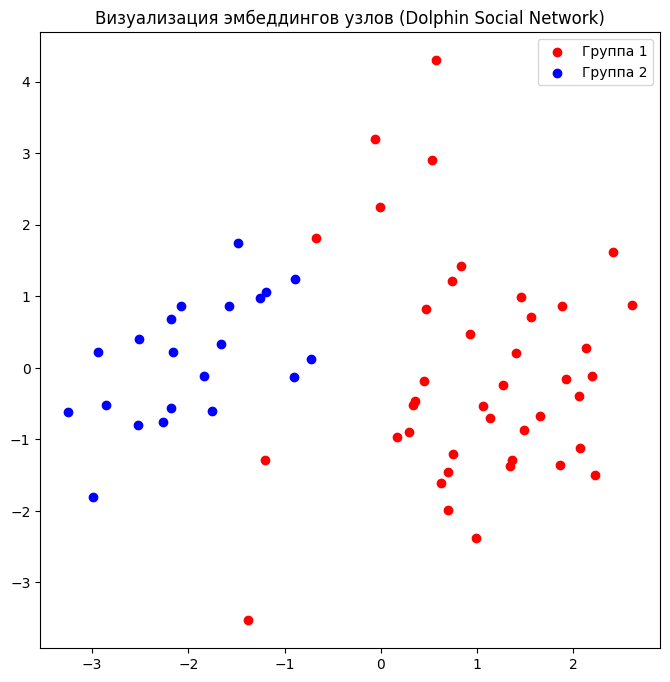

Эпоха 4551, Потеря: 0.0115
Эпоха 4552, Потеря: 0.0115
Эпоха 4553, Потеря: 0.0115
Эпоха 4554, Потеря: 0.0115
Эпоха 4555, Потеря: 0.0115
Эпоха 4556, Потеря: 0.0115
Эпоха 4557, Потеря: 0.0115
Эпоха 4558, Потеря: 0.0115
Эпоха 4559, Потеря: 0.0115
Эпоха 4560, Потеря: 0.0115
Эпоха 4561, Потеря: 0.0115
Эпоха 4562, Потеря: 0.0115
Эпоха 4563, Потеря: 0.0115
Эпоха 4564, Потеря: 0.0115
Эпоха 4565, Потеря: 0.0115
Эпоха 4566, Потеря: 0.0115
Эпоха 4567, Потеря: 0.0115
Эпоха 4568, Потеря: 0.0115
Эпоха 4569, Потеря: 0.0115
Эпоха 4570, Потеря: 0.0115
Эпоха 4571, Потеря: 0.0115
Эпоха 4572, Потеря: 0.0115
Эпоха 4573, Потеря: 0.0115
Эпоха 4574, Потеря: 0.0115
Эпоха 4575, Потеря: 0.0115
Эпоха 4576, Потеря: 0.0115
Эпоха 4577, Потеря: 0.0115
Эпоха 4578, Потеря: 0.0114
Эпоха 4579, Потеря: 0.0114
Эпоха 4580, Потеря: 0.0114
Эпоха 4581, Потеря: 0.0114
Эпоха 4582, Потеря: 0.0114
Эпоха 4583, Потеря: 0.0114
Эпоха 4584, Потеря: 0.0114
Эпоха 4585, Потеря: 0.0114
Эпоха 4586, Потеря: 0.0114
Эпоха 4587, Потеря: 0.0114
Э

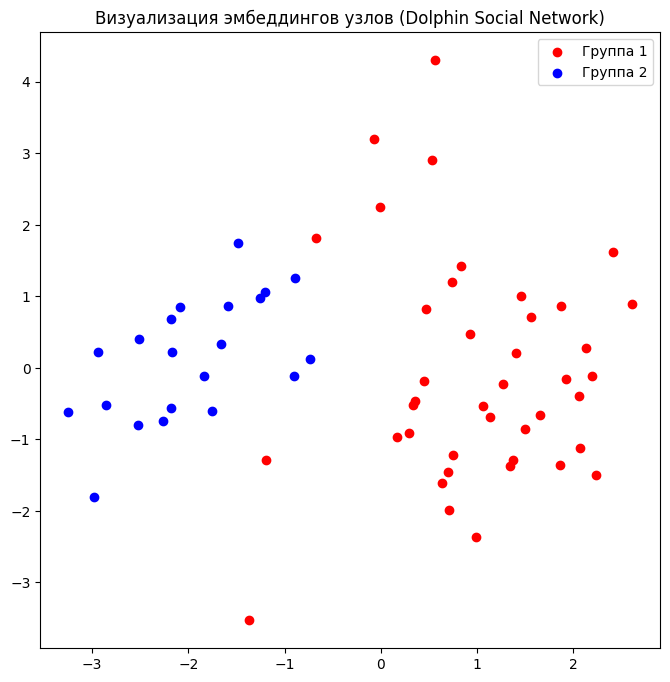

Эпоха 4601, Потеря: 0.0114
Эпоха 4602, Потеря: 0.0114
Эпоха 4603, Потеря: 0.0114
Эпоха 4604, Потеря: 0.0114
Эпоха 4605, Потеря: 0.0114
Эпоха 4606, Потеря: 0.0114
Эпоха 4607, Потеря: 0.0114
Эпоха 4608, Потеря: 0.0114
Эпоха 4609, Потеря: 0.0113
Эпоха 4610, Потеря: 0.0113
Эпоха 4611, Потеря: 0.0113
Эпоха 4612, Потеря: 0.0113
Эпоха 4613, Потеря: 0.0113
Эпоха 4614, Потеря: 0.0113
Эпоха 4615, Потеря: 0.0113
Эпоха 4616, Потеря: 0.0113
Эпоха 4617, Потеря: 0.0113
Эпоха 4618, Потеря: 0.0113
Эпоха 4619, Потеря: 0.0113
Эпоха 4620, Потеря: 0.0113
Эпоха 4621, Потеря: 0.0113
Эпоха 4622, Потеря: 0.0113
Эпоха 4623, Потеря: 0.0113
Эпоха 4624, Потеря: 0.0113
Эпоха 4625, Потеря: 0.0113
Эпоха 4626, Потеря: 0.0113
Эпоха 4627, Потеря: 0.0113
Эпоха 4628, Потеря: 0.0113
Эпоха 4629, Потеря: 0.0113
Эпоха 4630, Потеря: 0.0113
Эпоха 4631, Потеря: 0.0113
Эпоха 4632, Потеря: 0.0113
Эпоха 4633, Потеря: 0.0113
Эпоха 4634, Потеря: 0.0113
Эпоха 4635, Потеря: 0.0113
Эпоха 4636, Потеря: 0.0113
Эпоха 4637, Потеря: 0.0113
Э

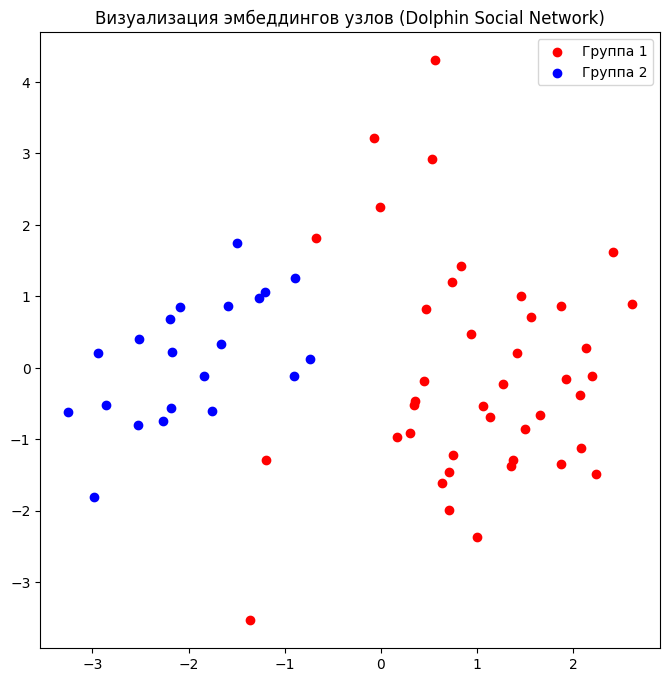

Эпоха 4651, Потеря: 0.0112
Эпоха 4652, Потеря: 0.0112
Эпоха 4653, Потеря: 0.0112
Эпоха 4654, Потеря: 0.0112
Эпоха 4655, Потеря: 0.0112
Эпоха 4656, Потеря: 0.0112
Эпоха 4657, Потеря: 0.0112
Эпоха 4658, Потеря: 0.0112
Эпоха 4659, Потеря: 0.0112
Эпоха 4660, Потеря: 0.0112
Эпоха 4661, Потеря: 0.0112
Эпоха 4662, Потеря: 0.0112
Эпоха 4663, Потеря: 0.0112
Эпоха 4664, Потеря: 0.0112
Эпоха 4665, Потеря: 0.0112
Эпоха 4666, Потеря: 0.0112
Эпоха 4667, Потеря: 0.0112
Эпоха 4668, Потеря: 0.0112
Эпоха 4669, Потеря: 0.0112
Эпоха 4670, Потеря: 0.0112
Эпоха 4671, Потеря: 0.0112
Эпоха 4672, Потеря: 0.0111
Эпоха 4673, Потеря: 0.0111
Эпоха 4674, Потеря: 0.0111
Эпоха 4675, Потеря: 0.0111
Эпоха 4676, Потеря: 0.0111
Эпоха 4677, Потеря: 0.0111
Эпоха 4678, Потеря: 0.0111
Эпоха 4679, Потеря: 0.0111
Эпоха 4680, Потеря: 0.0111
Эпоха 4681, Потеря: 0.0111
Эпоха 4682, Потеря: 0.0111
Эпоха 4683, Потеря: 0.0111
Эпоха 4684, Потеря: 0.0111
Эпоха 4685, Потеря: 0.0111
Эпоха 4686, Потеря: 0.0111
Эпоха 4687, Потеря: 0.0111
Э

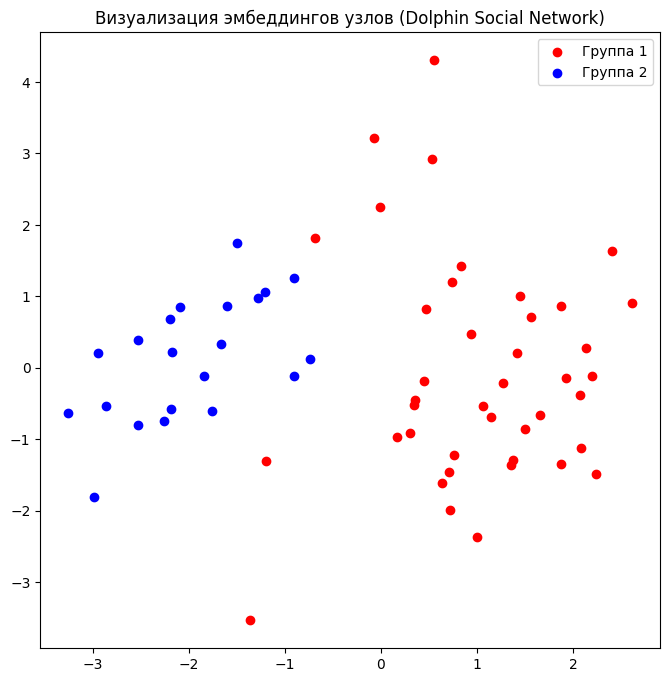

Эпоха 4701, Потеря: 0.0111
Эпоха 4702, Потеря: 0.0111
Эпоха 4703, Потеря: 0.0111
Эпоха 4704, Потеря: 0.0110
Эпоха 4705, Потеря: 0.0110
Эпоха 4706, Потеря: 0.0110
Эпоха 4707, Потеря: 0.0110
Эпоха 4708, Потеря: 0.0110
Эпоха 4709, Потеря: 0.0110
Эпоха 4710, Потеря: 0.0110
Эпоха 4711, Потеря: 0.0110
Эпоха 4712, Потеря: 0.0110
Эпоха 4713, Потеря: 0.0110
Эпоха 4714, Потеря: 0.0110
Эпоха 4715, Потеря: 0.0110
Эпоха 4716, Потеря: 0.0110
Эпоха 4717, Потеря: 0.0110
Эпоха 4718, Потеря: 0.0110
Эпоха 4719, Потеря: 0.0110
Эпоха 4720, Потеря: 0.0110
Эпоха 4721, Потеря: 0.0110
Эпоха 4722, Потеря: 0.0110
Эпоха 4723, Потеря: 0.0110
Эпоха 4724, Потеря: 0.0110
Эпоха 4725, Потеря: 0.0110
Эпоха 4726, Потеря: 0.0110
Эпоха 4727, Потеря: 0.0110
Эпоха 4728, Потеря: 0.0110
Эпоха 4729, Потеря: 0.0110
Эпоха 4730, Потеря: 0.0110
Эпоха 4731, Потеря: 0.0110
Эпоха 4732, Потеря: 0.0110
Эпоха 4733, Потеря: 0.0110
Эпоха 4734, Потеря: 0.0110
Эпоха 4735, Потеря: 0.0110
Эпоха 4736, Потеря: 0.0110
Эпоха 4737, Потеря: 0.0109
Э

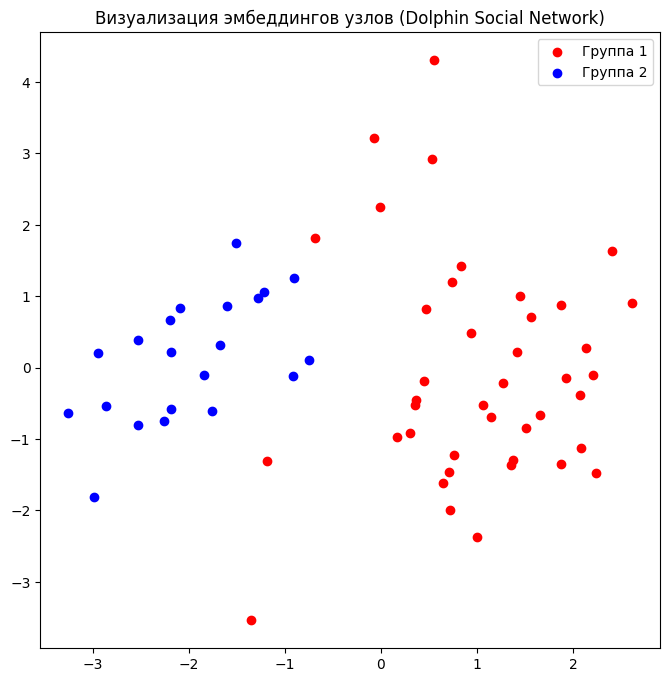

Эпоха 4751, Потеря: 0.0109
Эпоха 4752, Потеря: 0.0109
Эпоха 4753, Потеря: 0.0109
Эпоха 4754, Потеря: 0.0109
Эпоха 4755, Потеря: 0.0109
Эпоха 4756, Потеря: 0.0109
Эпоха 4757, Потеря: 0.0109
Эпоха 4758, Потеря: 0.0109
Эпоха 4759, Потеря: 0.0109
Эпоха 4760, Потеря: 0.0109
Эпоха 4761, Потеря: 0.0109
Эпоха 4762, Потеря: 0.0109
Эпоха 4763, Потеря: 0.0109
Эпоха 4764, Потеря: 0.0109
Эпоха 4765, Потеря: 0.0109
Эпоха 4766, Потеря: 0.0109
Эпоха 4767, Потеря: 0.0109
Эпоха 4768, Потеря: 0.0109
Эпоха 4769, Потеря: 0.0109
Эпоха 4770, Потеря: 0.0108
Эпоха 4771, Потеря: 0.0108
Эпоха 4772, Потеря: 0.0108
Эпоха 4773, Потеря: 0.0108
Эпоха 4774, Потеря: 0.0108
Эпоха 4775, Потеря: 0.0108
Эпоха 4776, Потеря: 0.0108
Эпоха 4777, Потеря: 0.0108
Эпоха 4778, Потеря: 0.0108
Эпоха 4779, Потеря: 0.0108
Эпоха 4780, Потеря: 0.0108
Эпоха 4781, Потеря: 0.0108
Эпоха 4782, Потеря: 0.0108
Эпоха 4783, Потеря: 0.0108
Эпоха 4784, Потеря: 0.0108
Эпоха 4785, Потеря: 0.0108
Эпоха 4786, Потеря: 0.0108
Эпоха 4787, Потеря: 0.0108
Э

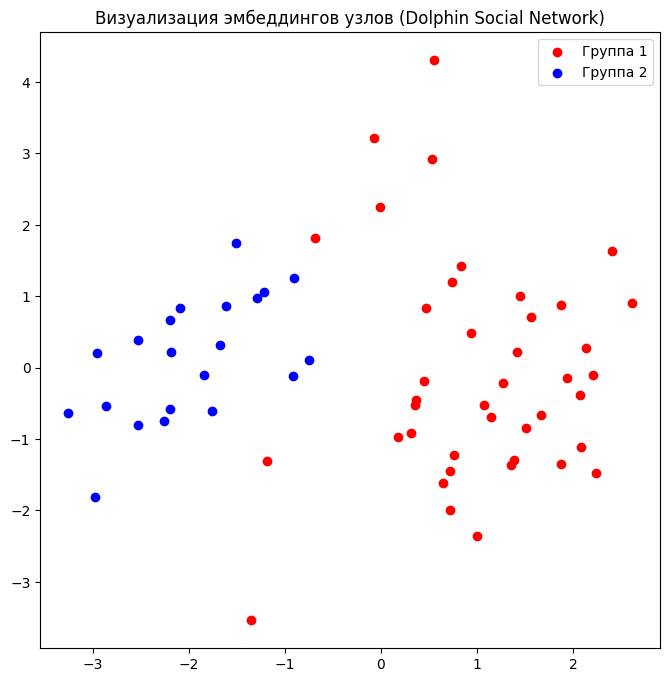

Эпоха 4801, Потеря: 0.0108
Эпоха 4802, Потеря: 0.0108
Эпоха 4803, Потеря: 0.0108
Эпоха 4804, Потеря: 0.0107
Эпоха 4805, Потеря: 0.0107
Эпоха 4806, Потеря: 0.0107
Эпоха 4807, Потеря: 0.0107
Эпоха 4808, Потеря: 0.0107
Эпоха 4809, Потеря: 0.0107
Эпоха 4810, Потеря: 0.0107
Эпоха 4811, Потеря: 0.0107
Эпоха 4812, Потеря: 0.0107
Эпоха 4813, Потеря: 0.0107
Эпоха 4814, Потеря: 0.0107
Эпоха 4815, Потеря: 0.0107
Эпоха 4816, Потеря: 0.0107
Эпоха 4817, Потеря: 0.0107
Эпоха 4818, Потеря: 0.0107
Эпоха 4819, Потеря: 0.0107
Эпоха 4820, Потеря: 0.0107
Эпоха 4821, Потеря: 0.0107
Эпоха 4822, Потеря: 0.0107
Эпоха 4823, Потеря: 0.0107
Эпоха 4824, Потеря: 0.0107
Эпоха 4825, Потеря: 0.0107
Эпоха 4826, Потеря: 0.0107
Эпоха 4827, Потеря: 0.0107
Эпоха 4828, Потеря: 0.0107
Эпоха 4829, Потеря: 0.0107
Эпоха 4830, Потеря: 0.0107
Эпоха 4831, Потеря: 0.0107
Эпоха 4832, Потеря: 0.0107
Эпоха 4833, Потеря: 0.0107
Эпоха 4834, Потеря: 0.0107
Эпоха 4835, Потеря: 0.0107
Эпоха 4836, Потеря: 0.0107
Эпоха 4837, Потеря: 0.0107
Э

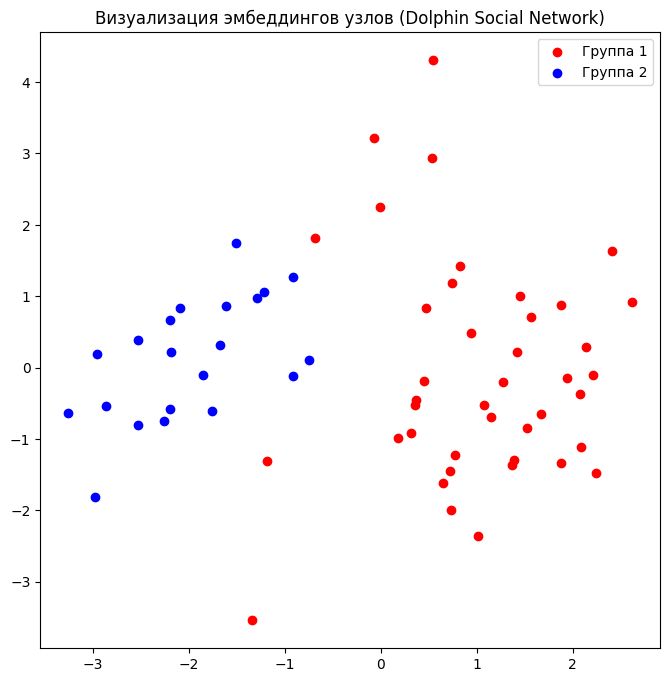

Эпоха 4851, Потеря: 0.0106
Эпоха 4852, Потеря: 0.0106
Эпоха 4853, Потеря: 0.0106
Эпоха 4854, Потеря: 0.0106
Эпоха 4855, Потеря: 0.0106
Эпоха 4856, Потеря: 0.0106
Эпоха 4857, Потеря: 0.0106
Эпоха 4858, Потеря: 0.0106
Эпоха 4859, Потеря: 0.0106
Эпоха 4860, Потеря: 0.0106
Эпоха 4861, Потеря: 0.0106
Эпоха 4862, Потеря: 0.0106
Эпоха 4863, Потеря: 0.0106
Эпоха 4864, Потеря: 0.0106
Эпоха 4865, Потеря: 0.0106
Эпоха 4866, Потеря: 0.0106
Эпоха 4867, Потеря: 0.0106
Эпоха 4868, Потеря: 0.0106
Эпоха 4869, Потеря: 0.0106
Эпоха 4870, Потеря: 0.0106
Эпоха 4871, Потеря: 0.0106
Эпоха 4872, Потеря: 0.0106
Эпоха 4873, Потеря: 0.0106
Эпоха 4874, Потеря: 0.0105
Эпоха 4875, Потеря: 0.0105
Эпоха 4876, Потеря: 0.0105
Эпоха 4877, Потеря: 0.0105
Эпоха 4878, Потеря: 0.0105
Эпоха 4879, Потеря: 0.0105
Эпоха 4880, Потеря: 0.0105
Эпоха 4881, Потеря: 0.0105
Эпоха 4882, Потеря: 0.0105
Эпоха 4883, Потеря: 0.0105
Эпоха 4884, Потеря: 0.0105
Эпоха 4885, Потеря: 0.0105
Эпоха 4886, Потеря: 0.0105
Эпоха 4887, Потеря: 0.0105
Э

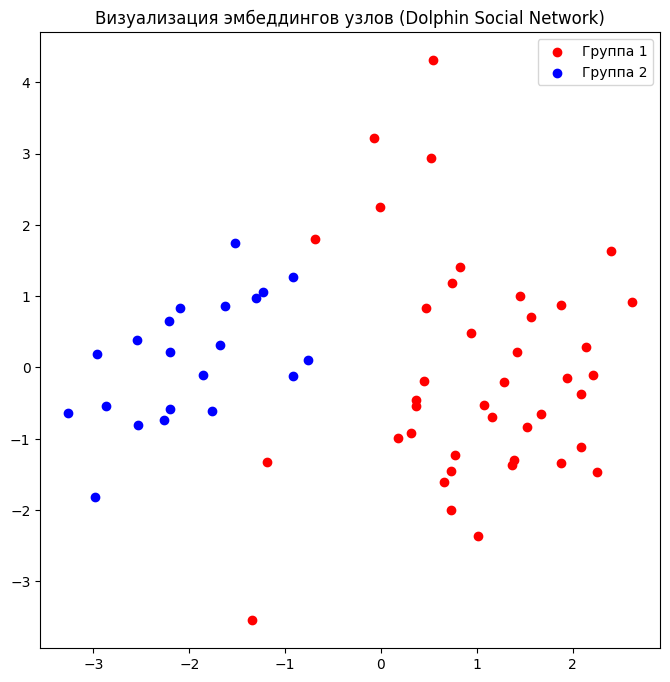

Эпоха 4901, Потеря: 0.0105
Эпоха 4902, Потеря: 0.0105
Эпоха 4903, Потеря: 0.0105
Эпоха 4904, Потеря: 0.0105
Эпоха 4905, Потеря: 0.0105
Эпоха 4906, Потеря: 0.0105
Эпоха 4907, Потеря: 0.0105
Эпоха 4908, Потеря: 0.0105
Эпоха 4909, Потеря: 0.0104
Эпоха 4910, Потеря: 0.0104
Эпоха 4911, Потеря: 0.0104
Эпоха 4912, Потеря: 0.0104
Эпоха 4913, Потеря: 0.0104
Эпоха 4914, Потеря: 0.0104
Эпоха 4915, Потеря: 0.0104
Эпоха 4916, Потеря: 0.0104
Эпоха 4917, Потеря: 0.0104
Эпоха 4918, Потеря: 0.0104
Эпоха 4919, Потеря: 0.0104
Эпоха 4920, Потеря: 0.0104
Эпоха 4921, Потеря: 0.0104
Эпоха 4922, Потеря: 0.0104
Эпоха 4923, Потеря: 0.0104
Эпоха 4924, Потеря: 0.0104
Эпоха 4925, Потеря: 0.0104
Эпоха 4926, Потеря: 0.0104
Эпоха 4927, Потеря: 0.0104
Эпоха 4928, Потеря: 0.0104
Эпоха 4929, Потеря: 0.0104
Эпоха 4930, Потеря: 0.0104
Эпоха 4931, Потеря: 0.0104
Эпоха 4932, Потеря: 0.0104
Эпоха 4933, Потеря: 0.0104
Эпоха 4934, Потеря: 0.0104
Эпоха 4935, Потеря: 0.0104
Эпоха 4936, Потеря: 0.0104
Эпоха 4937, Потеря: 0.0104
Э

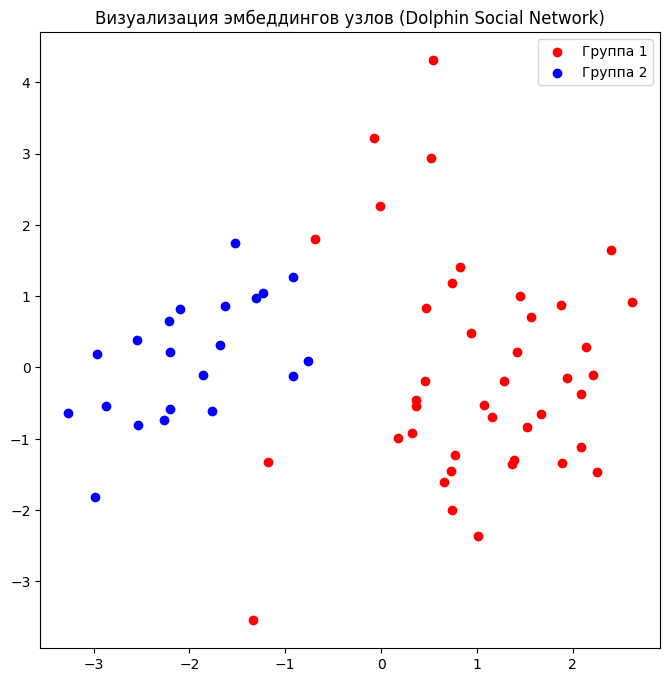

Эпоха 4951, Потеря: 0.0103
Эпоха 4952, Потеря: 0.0103
Эпоха 4953, Потеря: 0.0103
Эпоха 4954, Потеря: 0.0103
Эпоха 4955, Потеря: 0.0103
Эпоха 4956, Потеря: 0.0103
Эпоха 4957, Потеря: 0.0103
Эпоха 4958, Потеря: 0.0103
Эпоха 4959, Потеря: 0.0103
Эпоха 4960, Потеря: 0.0103
Эпоха 4961, Потеря: 0.0103
Эпоха 4962, Потеря: 0.0103
Эпоха 4963, Потеря: 0.0103
Эпоха 4964, Потеря: 0.0103
Эпоха 4965, Потеря: 0.0103
Эпоха 4966, Потеря: 0.0103
Эпоха 4967, Потеря: 0.0103
Эпоха 4968, Потеря: 0.0103
Эпоха 4969, Потеря: 0.0103
Эпоха 4970, Потеря: 0.0103
Эпоха 4971, Потеря: 0.0103
Эпоха 4972, Потеря: 0.0103
Эпоха 4973, Потеря: 0.0103
Эпоха 4974, Потеря: 0.0103
Эпоха 4975, Потеря: 0.0103
Эпоха 4976, Потеря: 0.0103
Эпоха 4977, Потеря: 0.0103
Эпоха 4978, Потеря: 0.0103
Эпоха 4979, Потеря: 0.0103
Эпоха 4980, Потеря: 0.0103
Эпоха 4981, Потеря: 0.0103
Эпоха 4982, Потеря: 0.0103
Эпоха 4983, Потеря: 0.0102
Эпоха 4984, Потеря: 0.0102
Эпоха 4985, Потеря: 0.0102
Эпоха 4986, Потеря: 0.0102
Эпоха 4987, Потеря: 0.0102
Э

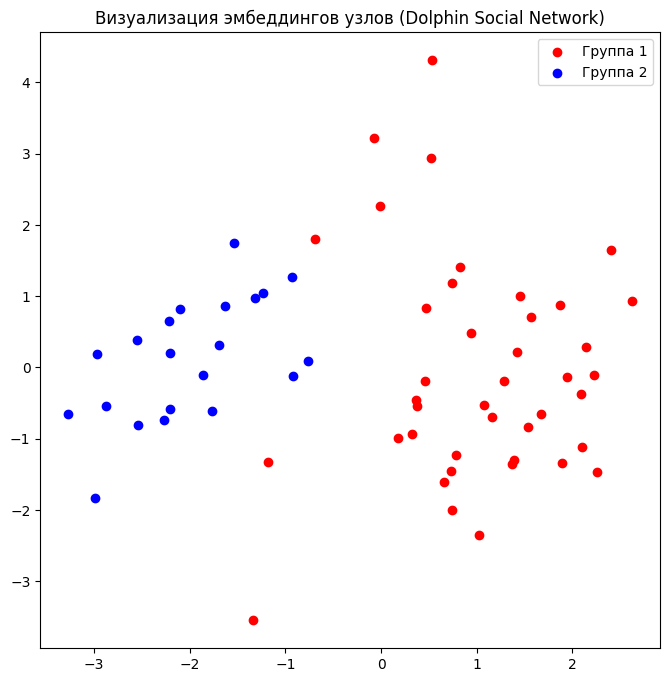

Эпоха 5001, Потеря: 0.0102
Эпоха 5002, Потеря: 0.0102
Эпоха 5003, Потеря: 0.0102
Эпоха 5004, Потеря: 0.0102
Эпоха 5005, Потеря: 0.0102
Эпоха 5006, Потеря: 0.0102
Эпоха 5007, Потеря: 0.0102
Эпоха 5008, Потеря: 0.0102
Эпоха 5009, Потеря: 0.0102
Эпоха 5010, Потеря: 0.0102
Эпоха 5011, Потеря: 0.0102
Эпоха 5012, Потеря: 0.0102
Эпоха 5013, Потеря: 0.0102
Эпоха 5014, Потеря: 0.0102
Эпоха 5015, Потеря: 0.0102
Эпоха 5016, Потеря: 0.0102
Эпоха 5017, Потеря: 0.0102
Эпоха 5018, Потеря: 0.0102
Эпоха 5019, Потеря: 0.0102
Эпоха 5020, Потеря: 0.0101
Эпоха 5021, Потеря: 0.0101
Эпоха 5022, Потеря: 0.0101
Эпоха 5023, Потеря: 0.0101
Эпоха 5024, Потеря: 0.0101
Эпоха 5025, Потеря: 0.0101
Эпоха 5026, Потеря: 0.0101
Эпоха 5027, Потеря: 0.0101
Эпоха 5028, Потеря: 0.0101
Эпоха 5029, Потеря: 0.0101
Эпоха 5030, Потеря: 0.0101
Эпоха 5031, Потеря: 0.0101
Эпоха 5032, Потеря: 0.0101
Эпоха 5033, Потеря: 0.0101
Эпоха 5034, Потеря: 0.0101
Эпоха 5035, Потеря: 0.0101
Эпоха 5036, Потеря: 0.0101
Эпоха 5037, Потеря: 0.0101
Э

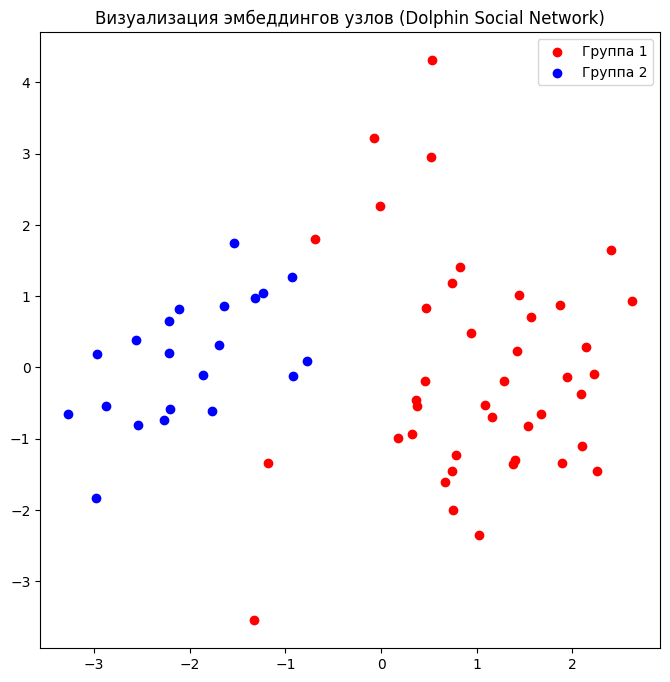

Эпоха 5051, Потеря: 0.0101
Эпоха 5052, Потеря: 0.0101
Эпоха 5053, Потеря: 0.0101
Эпоха 5054, Потеря: 0.0101
Эпоха 5055, Потеря: 0.0101
Эпоха 5056, Потеря: 0.0101
Эпоха 5057, Потеря: 0.0101
Эпоха 5058, Потеря: 0.0101
Эпоха 5059, Потеря: 0.0100
Эпоха 5060, Потеря: 0.0100
Эпоха 5061, Потеря: 0.0100
Эпоха 5062, Потеря: 0.0100
Эпоха 5063, Потеря: 0.0100
Эпоха 5064, Потеря: 0.0100
Эпоха 5065, Потеря: 0.0100
Эпоха 5066, Потеря: 0.0100
Эпоха 5067, Потеря: 0.0100
Эпоха 5068, Потеря: 0.0100
Эпоха 5069, Потеря: 0.0100
Эпоха 5070, Потеря: 0.0100
Эпоха 5071, Потеря: 0.0100
Эпоха 5072, Потеря: 0.0100
Эпоха 5073, Потеря: 0.0100
Эпоха 5074, Потеря: 0.0100
Эпоха 5075, Потеря: 0.0100
Эпоха 5076, Потеря: 0.0100
Эпоха 5077, Потеря: 0.0100
Эпоха 5078, Потеря: 0.0100
Эпоха 5079, Потеря: 0.0100
Эпоха 5080, Потеря: 0.0100
Эпоха 5081, Потеря: 0.0100
Эпоха 5082, Потеря: 0.0100
Эпоха 5083, Потеря: 0.0100
Эпоха 5084, Потеря: 0.0100
Эпоха 5085, Потеря: 0.0100
Эпоха 5086, Потеря: 0.0100
Эпоха 5087, Потеря: 0.0100
Э

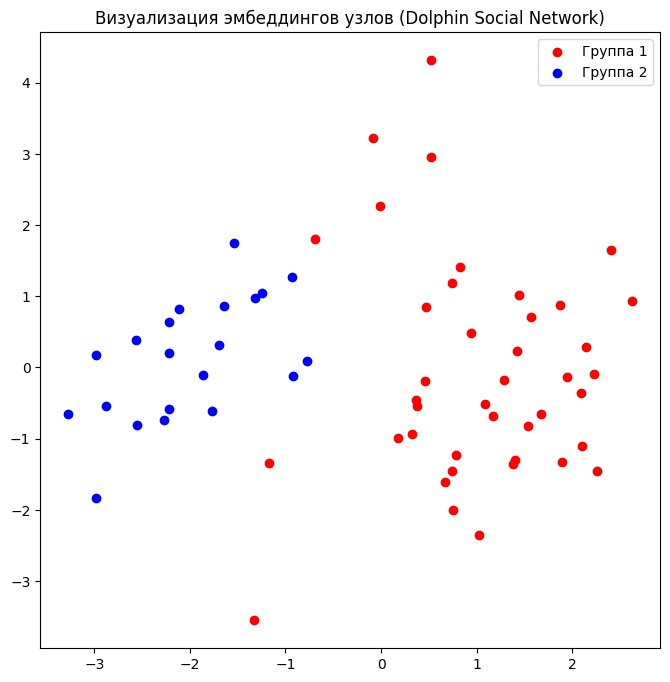

Эпоха 5101, Потеря: 0.0099
Эпоха 5102, Потеря: 0.0099
Эпоха 5103, Потеря: 0.0099
Эпоха 5104, Потеря: 0.0099
Эпоха 5105, Потеря: 0.0099
Эпоха 5106, Потеря: 0.0099
Эпоха 5107, Потеря: 0.0099
Эпоха 5108, Потеря: 0.0099
Эпоха 5109, Потеря: 0.0099
Эпоха 5110, Потеря: 0.0099
Эпоха 5111, Потеря: 0.0099
Эпоха 5112, Потеря: 0.0099
Эпоха 5113, Потеря: 0.0099
Эпоха 5114, Потеря: 0.0099
Эпоха 5115, Потеря: 0.0099
Эпоха 5116, Потеря: 0.0099
Эпоха 5117, Потеря: 0.0099
Эпоха 5118, Потеря: 0.0099
Эпоха 5119, Потеря: 0.0099
Эпоха 5120, Потеря: 0.0099
Эпоха 5121, Потеря: 0.0099
Эпоха 5122, Потеря: 0.0099
Эпоха 5123, Потеря: 0.0099
Эпоха 5124, Потеря: 0.0099
Эпоха 5125, Потеря: 0.0099
Эпоха 5126, Потеря: 0.0099
Эпоха 5127, Потеря: 0.0099
Эпоха 5128, Потеря: 0.0099
Эпоха 5129, Потеря: 0.0099
Эпоха 5130, Потеря: 0.0099
Эпоха 5131, Потеря: 0.0099
Эпоха 5132, Потеря: 0.0099
Эпоха 5133, Потеря: 0.0099
Эпоха 5134, Потеря: 0.0099
Эпоха 5135, Потеря: 0.0099
Эпоха 5136, Потеря: 0.0099
Эпоха 5137, Потеря: 0.0098
Э

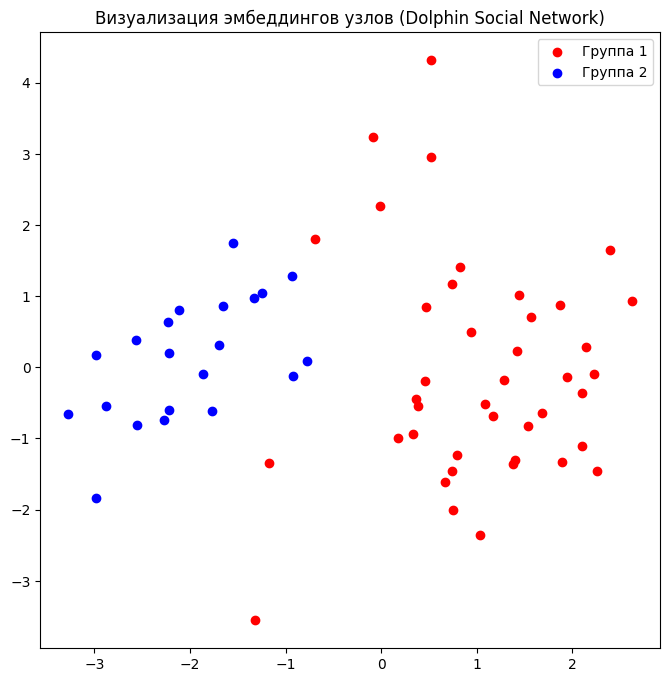

Эпоха 5151, Потеря: 0.0098
Эпоха 5152, Потеря: 0.0098
Эпоха 5153, Потеря: 0.0098
Эпоха 5154, Потеря: 0.0098
Эпоха 5155, Потеря: 0.0098
Эпоха 5156, Потеря: 0.0098
Эпоха 5157, Потеря: 0.0098
Эпоха 5158, Потеря: 0.0098
Эпоха 5159, Потеря: 0.0098
Эпоха 5160, Потеря: 0.0098
Эпоха 5161, Потеря: 0.0098
Эпоха 5162, Потеря: 0.0098
Эпоха 5163, Потеря: 0.0098
Эпоха 5164, Потеря: 0.0098
Эпоха 5165, Потеря: 0.0098
Эпоха 5166, Потеря: 0.0098
Эпоха 5167, Потеря: 0.0098
Эпоха 5168, Потеря: 0.0098
Эпоха 5169, Потеря: 0.0098
Эпоха 5170, Потеря: 0.0098
Эпоха 5171, Потеря: 0.0098
Эпоха 5172, Потеря: 0.0098
Эпоха 5173, Потеря: 0.0098
Эпоха 5174, Потеря: 0.0098
Эпоха 5175, Потеря: 0.0098
Эпоха 5176, Потеря: 0.0098
Эпоха 5177, Потеря: 0.0098
Эпоха 5178, Потеря: 0.0097
Эпоха 5179, Потеря: 0.0097
Эпоха 5180, Потеря: 0.0097
Эпоха 5181, Потеря: 0.0097
Эпоха 5182, Потеря: 0.0097
Эпоха 5183, Потеря: 0.0097
Эпоха 5184, Потеря: 0.0097
Эпоха 5185, Потеря: 0.0097
Эпоха 5186, Потеря: 0.0097
Эпоха 5187, Потеря: 0.0097
Э

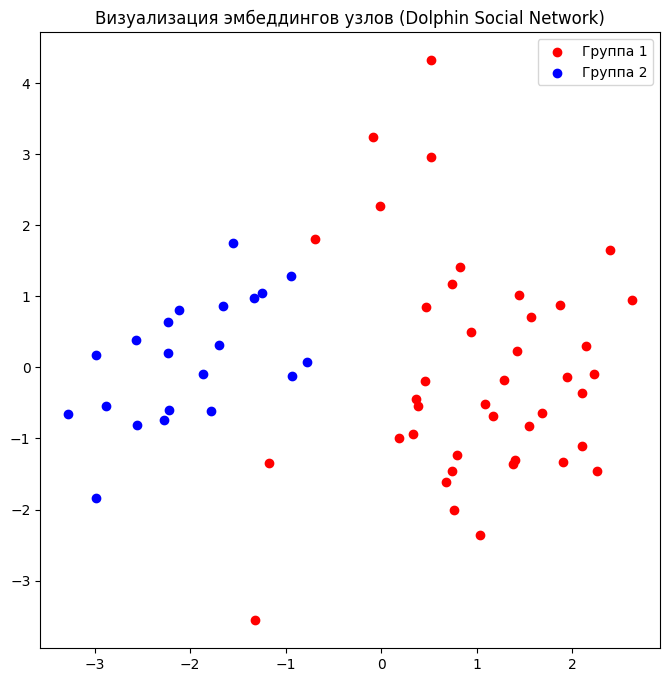

Эпоха 5201, Потеря: 0.0097
Эпоха 5202, Потеря: 0.0097
Эпоха 5203, Потеря: 0.0097
Эпоха 5204, Потеря: 0.0097
Эпоха 5205, Потеря: 0.0097
Эпоха 5206, Потеря: 0.0097
Эпоха 5207, Потеря: 0.0097
Эпоха 5208, Потеря: 0.0097
Эпоха 5209, Потеря: 0.0097
Эпоха 5210, Потеря: 0.0097
Эпоха 5211, Потеря: 0.0097
Эпоха 5212, Потеря: 0.0097
Эпоха 5213, Потеря: 0.0097
Эпоха 5214, Потеря: 0.0097
Эпоха 5215, Потеря: 0.0097
Эпоха 5216, Потеря: 0.0097
Эпоха 5217, Потеря: 0.0097
Эпоха 5218, Потеря: 0.0097
Эпоха 5219, Потеря: 0.0096
Эпоха 5220, Потеря: 0.0096
Эпоха 5221, Потеря: 0.0096
Эпоха 5222, Потеря: 0.0096
Эпоха 5223, Потеря: 0.0096
Эпоха 5224, Потеря: 0.0096
Эпоха 5225, Потеря: 0.0096
Эпоха 5226, Потеря: 0.0096
Эпоха 5227, Потеря: 0.0096
Эпоха 5228, Потеря: 0.0096
Эпоха 5229, Потеря: 0.0096
Эпоха 5230, Потеря: 0.0096
Эпоха 5231, Потеря: 0.0096
Эпоха 5232, Потеря: 0.0096
Эпоха 5233, Потеря: 0.0096
Эпоха 5234, Потеря: 0.0096
Эпоха 5235, Потеря: 0.0096
Эпоха 5236, Потеря: 0.0096
Эпоха 5237, Потеря: 0.0096
Э

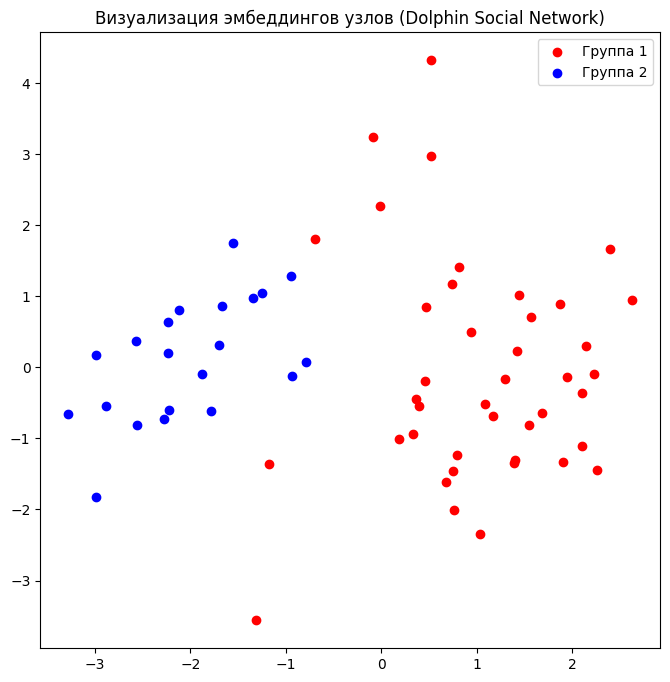

Эпоха 5251, Потеря: 0.0096
Эпоха 5252, Потеря: 0.0096
Эпоха 5253, Потеря: 0.0096
Эпоха 5254, Потеря: 0.0096
Эпоха 5255, Потеря: 0.0096
Эпоха 5256, Потеря: 0.0096
Эпоха 5257, Потеря: 0.0096
Эпоха 5258, Потеря: 0.0096
Эпоха 5259, Потеря: 0.0096
Эпоха 5260, Потеря: 0.0096
Эпоха 5261, Потеря: 0.0095
Эпоха 5262, Потеря: 0.0095
Эпоха 5263, Потеря: 0.0095
Эпоха 5264, Потеря: 0.0095
Эпоха 5265, Потеря: 0.0095
Эпоха 5266, Потеря: 0.0095
Эпоха 5267, Потеря: 0.0095
Эпоха 5268, Потеря: 0.0095
Эпоха 5269, Потеря: 0.0095
Эпоха 5270, Потеря: 0.0095
Эпоха 5271, Потеря: 0.0095
Эпоха 5272, Потеря: 0.0095
Эпоха 5273, Потеря: 0.0095
Эпоха 5274, Потеря: 0.0095
Эпоха 5275, Потеря: 0.0095
Эпоха 5276, Потеря: 0.0095
Эпоха 5277, Потеря: 0.0095
Эпоха 5278, Потеря: 0.0095
Эпоха 5279, Потеря: 0.0095
Эпоха 5280, Потеря: 0.0095
Эпоха 5281, Потеря: 0.0095
Эпоха 5282, Потеря: 0.0095
Эпоха 5283, Потеря: 0.0095
Эпоха 5284, Потеря: 0.0095
Эпоха 5285, Потеря: 0.0095
Эпоха 5286, Потеря: 0.0095
Эпоха 5287, Потеря: 0.0095
Э

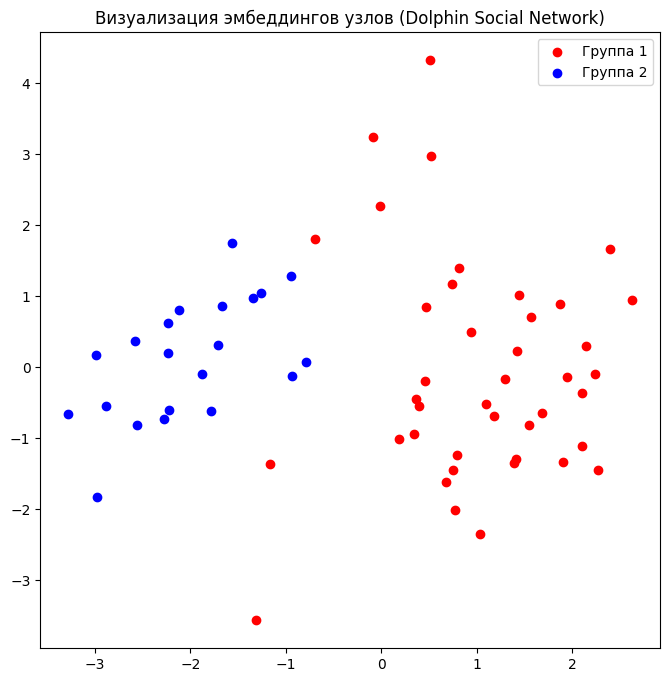

Эпоха 5301, Потеря: 0.0095
Эпоха 5302, Потеря: 0.0095
Эпоха 5303, Потеря: 0.0095
Эпоха 5304, Потеря: 0.0094
Эпоха 5305, Потеря: 0.0094
Эпоха 5306, Потеря: 0.0094
Эпоха 5307, Потеря: 0.0094
Эпоха 5308, Потеря: 0.0094
Эпоха 5309, Потеря: 0.0094
Эпоха 5310, Потеря: 0.0094
Эпоха 5311, Потеря: 0.0094
Эпоха 5312, Потеря: 0.0094
Эпоха 5313, Потеря: 0.0094
Эпоха 5314, Потеря: 0.0094
Эпоха 5315, Потеря: 0.0094
Эпоха 5316, Потеря: 0.0094
Эпоха 5317, Потеря: 0.0094
Эпоха 5318, Потеря: 0.0094
Эпоха 5319, Потеря: 0.0094
Эпоха 5320, Потеря: 0.0094
Эпоха 5321, Потеря: 0.0094
Эпоха 5322, Потеря: 0.0094
Эпоха 5323, Потеря: 0.0094
Эпоха 5324, Потеря: 0.0094
Эпоха 5325, Потеря: 0.0094
Эпоха 5326, Потеря: 0.0094
Эпоха 5327, Потеря: 0.0094
Эпоха 5328, Потеря: 0.0094
Эпоха 5329, Потеря: 0.0094
Эпоха 5330, Потеря: 0.0094
Эпоха 5331, Потеря: 0.0094
Эпоха 5332, Потеря: 0.0094
Эпоха 5333, Потеря: 0.0094
Эпоха 5334, Потеря: 0.0094
Эпоха 5335, Потеря: 0.0094
Эпоха 5336, Потеря: 0.0094
Эпоха 5337, Потеря: 0.0094
Э

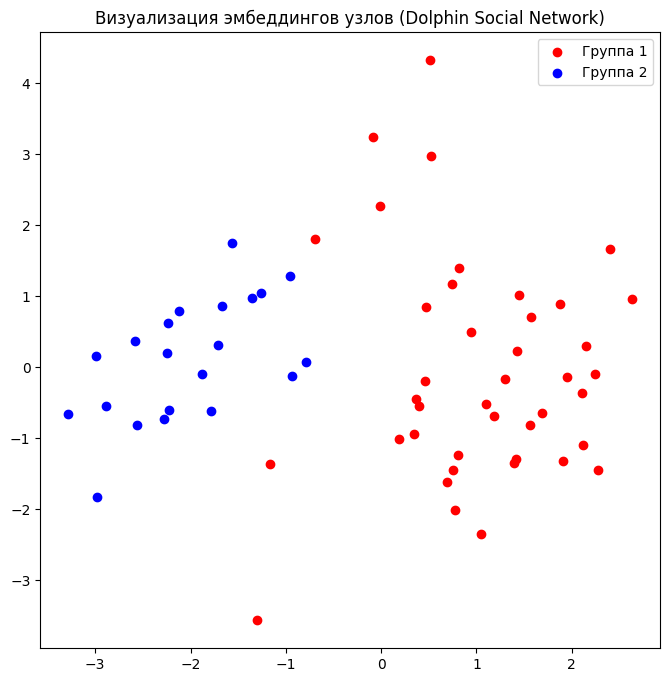

Эпоха 5351, Потеря: 0.0093
Эпоха 5352, Потеря: 0.0093
Эпоха 5353, Потеря: 0.0093
Эпоха 5354, Потеря: 0.0093
Эпоха 5355, Потеря: 0.0093
Эпоха 5356, Потеря: 0.0093
Эпоха 5357, Потеря: 0.0093
Эпоха 5358, Потеря: 0.0093
Эпоха 5359, Потеря: 0.0093
Эпоха 5360, Потеря: 0.0093
Эпоха 5361, Потеря: 0.0093
Эпоха 5362, Потеря: 0.0093
Эпоха 5363, Потеря: 0.0093
Эпоха 5364, Потеря: 0.0093
Эпоха 5365, Потеря: 0.0093
Эпоха 5366, Потеря: 0.0093
Эпоха 5367, Потеря: 0.0093
Эпоха 5368, Потеря: 0.0093
Эпоха 5369, Потеря: 0.0093
Эпоха 5370, Потеря: 0.0093
Эпоха 5371, Потеря: 0.0093
Эпоха 5372, Потеря: 0.0093
Эпоха 5373, Потеря: 0.0093
Эпоха 5374, Потеря: 0.0093
Эпоха 5375, Потеря: 0.0093
Эпоха 5376, Потеря: 0.0093
Эпоха 5377, Потеря: 0.0093
Эпоха 5378, Потеря: 0.0093
Эпоха 5379, Потеря: 0.0093
Эпоха 5380, Потеря: 0.0093
Эпоха 5381, Потеря: 0.0093
Эпоха 5382, Потеря: 0.0093
Эпоха 5383, Потеря: 0.0093
Эпоха 5384, Потеря: 0.0093
Эпоха 5385, Потеря: 0.0093
Эпоха 5386, Потеря: 0.0093
Эпоха 5387, Потеря: 0.0093
Э

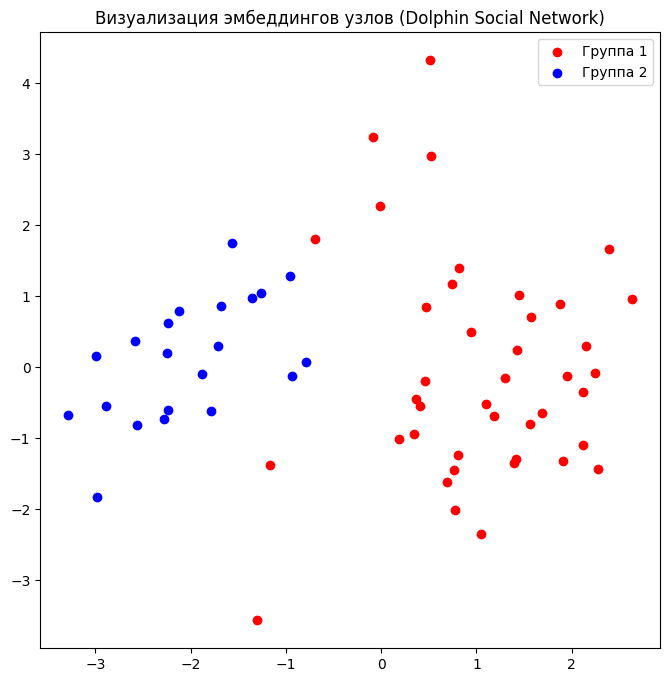

Эпоха 5401, Потеря: 0.0092
Эпоха 5402, Потеря: 0.0092
Эпоха 5403, Потеря: 0.0092
Эпоха 5404, Потеря: 0.0092
Эпоха 5405, Потеря: 0.0092
Эпоха 5406, Потеря: 0.0092
Эпоха 5407, Потеря: 0.0092
Эпоха 5408, Потеря: 0.0092
Эпоха 5409, Потеря: 0.0092
Эпоха 5410, Потеря: 0.0092
Эпоха 5411, Потеря: 0.0092
Эпоха 5412, Потеря: 0.0092
Эпоха 5413, Потеря: 0.0092
Эпоха 5414, Потеря: 0.0092
Эпоха 5415, Потеря: 0.0092
Эпоха 5416, Потеря: 0.0092
Эпоха 5417, Потеря: 0.0092
Эпоха 5418, Потеря: 0.0092
Эпоха 5419, Потеря: 0.0092
Эпоха 5420, Потеря: 0.0092
Эпоха 5421, Потеря: 0.0092
Эпоха 5422, Потеря: 0.0092
Эпоха 5423, Потеря: 0.0092
Эпоха 5424, Потеря: 0.0092
Эпоха 5425, Потеря: 0.0092
Эпоха 5426, Потеря: 0.0092
Эпоха 5427, Потеря: 0.0092
Эпоха 5428, Потеря: 0.0092
Эпоха 5429, Потеря: 0.0092
Эпоха 5430, Потеря: 0.0092
Эпоха 5431, Потеря: 0.0092
Эпоха 5432, Потеря: 0.0092
Эпоха 5433, Потеря: 0.0092
Эпоха 5434, Потеря: 0.0092
Эпоха 5435, Потеря: 0.0092
Эпоха 5436, Потеря: 0.0092
Эпоха 5437, Потеря: 0.0092
Э

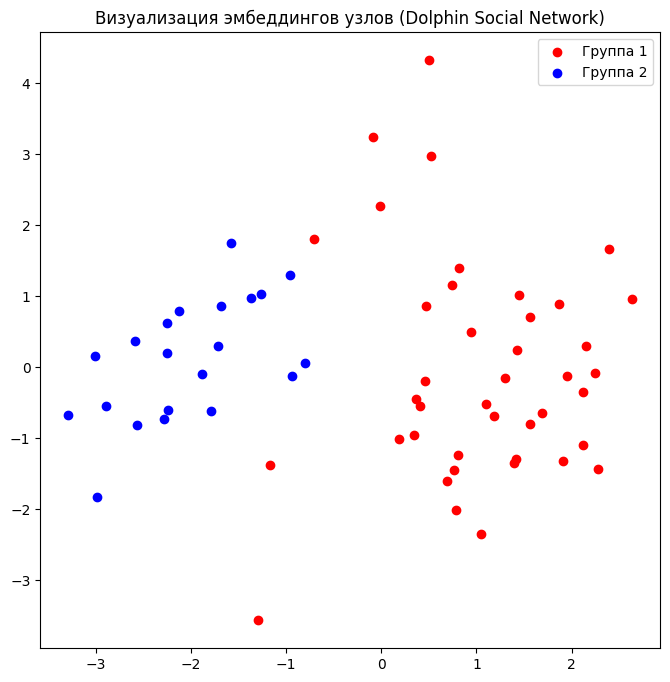

Эпоха 5451, Потеря: 0.0091
Эпоха 5452, Потеря: 0.0091
Эпоха 5453, Потеря: 0.0091
Эпоха 5454, Потеря: 0.0091
Эпоха 5455, Потеря: 0.0091
Эпоха 5456, Потеря: 0.0091
Эпоха 5457, Потеря: 0.0091
Эпоха 5458, Потеря: 0.0091
Эпоха 5459, Потеря: 0.0091
Эпоха 5460, Потеря: 0.0091
Эпоха 5461, Потеря: 0.0091
Эпоха 5462, Потеря: 0.0091
Эпоха 5463, Потеря: 0.0091
Эпоха 5464, Потеря: 0.0091
Эпоха 5465, Потеря: 0.0091
Эпоха 5466, Потеря: 0.0091
Эпоха 5467, Потеря: 0.0091
Эпоха 5468, Потеря: 0.0091
Эпоха 5469, Потеря: 0.0091
Эпоха 5470, Потеря: 0.0091
Эпоха 5471, Потеря: 0.0091
Эпоха 5472, Потеря: 0.0091
Эпоха 5473, Потеря: 0.0091
Эпоха 5474, Потеря: 0.0091
Эпоха 5475, Потеря: 0.0091
Эпоха 5476, Потеря: 0.0091
Эпоха 5477, Потеря: 0.0091
Эпоха 5478, Потеря: 0.0091
Эпоха 5479, Потеря: 0.0091
Эпоха 5480, Потеря: 0.0091
Эпоха 5481, Потеря: 0.0091
Эпоха 5482, Потеря: 0.0091
Эпоха 5483, Потеря: 0.0091
Эпоха 5484, Потеря: 0.0091
Эпоха 5485, Потеря: 0.0090
Эпоха 5486, Потеря: 0.0090
Эпоха 5487, Потеря: 0.0090
Э

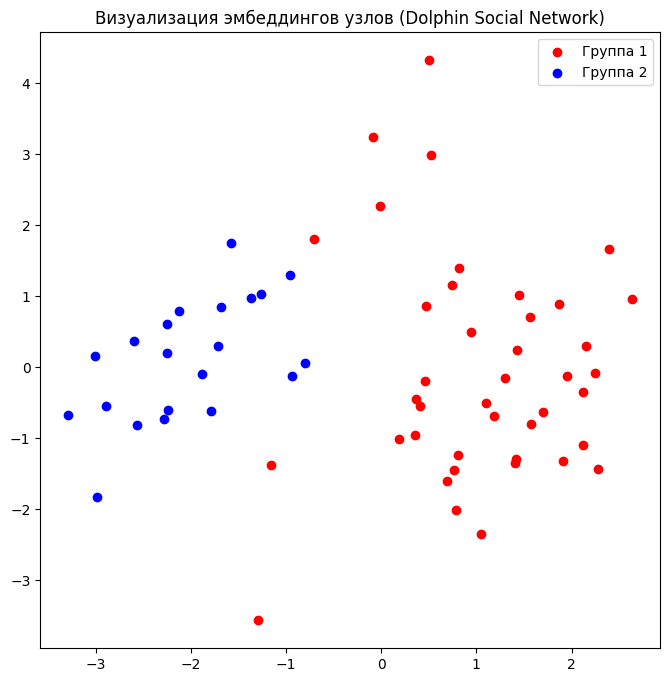

Эпоха 5501, Потеря: 0.0090
Эпоха 5502, Потеря: 0.0090
Эпоха 5503, Потеря: 0.0090
Эпоха 5504, Потеря: 0.0090
Эпоха 5505, Потеря: 0.0090
Эпоха 5506, Потеря: 0.0090
Эпоха 5507, Потеря: 0.0090
Эпоха 5508, Потеря: 0.0090
Эпоха 5509, Потеря: 0.0090
Эпоха 5510, Потеря: 0.0090
Эпоха 5511, Потеря: 0.0090
Эпоха 5512, Потеря: 0.0090
Эпоха 5513, Потеря: 0.0090
Эпоха 5514, Потеря: 0.0090
Эпоха 5515, Потеря: 0.0090
Эпоха 5516, Потеря: 0.0090
Эпоха 5517, Потеря: 0.0090
Эпоха 5518, Потеря: 0.0090
Эпоха 5519, Потеря: 0.0090
Эпоха 5520, Потеря: 0.0090
Эпоха 5521, Потеря: 0.0090
Эпоха 5522, Потеря: 0.0090
Эпоха 5523, Потеря: 0.0090
Эпоха 5524, Потеря: 0.0090
Эпоха 5525, Потеря: 0.0090
Эпоха 5526, Потеря: 0.0090
Эпоха 5527, Потеря: 0.0090
Эпоха 5528, Потеря: 0.0090
Эпоха 5529, Потеря: 0.0090
Эпоха 5530, Потеря: 0.0090
Эпоха 5531, Потеря: 0.0090
Эпоха 5532, Потеря: 0.0089
Эпоха 5533, Потеря: 0.0089
Эпоха 5534, Потеря: 0.0089
Эпоха 5535, Потеря: 0.0089
Эпоха 5536, Потеря: 0.0089
Эпоха 5537, Потеря: 0.0089
Э

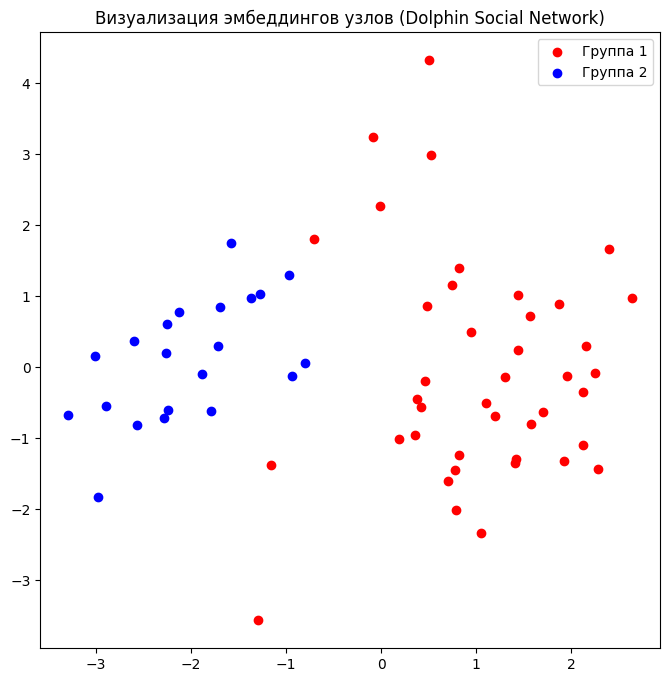

Эпоха 5551, Потеря: 0.0089
Эпоха 5552, Потеря: 0.0089
Эпоха 5553, Потеря: 0.0089
Эпоха 5554, Потеря: 0.0089
Эпоха 5555, Потеря: 0.0089
Эпоха 5556, Потеря: 0.0089
Эпоха 5557, Потеря: 0.0089
Эпоха 5558, Потеря: 0.0089
Эпоха 5559, Потеря: 0.0089
Эпоха 5560, Потеря: 0.0089
Эпоха 5561, Потеря: 0.0089
Эпоха 5562, Потеря: 0.0089
Эпоха 5563, Потеря: 0.0089
Эпоха 5564, Потеря: 0.0089
Эпоха 5565, Потеря: 0.0089
Эпоха 5566, Потеря: 0.0089
Эпоха 5567, Потеря: 0.0089
Эпоха 5568, Потеря: 0.0089
Эпоха 5569, Потеря: 0.0089
Эпоха 5570, Потеря: 0.0089
Эпоха 5571, Потеря: 0.0089
Эпоха 5572, Потеря: 0.0089
Эпоха 5573, Потеря: 0.0089
Эпоха 5574, Потеря: 0.0089
Эпоха 5575, Потеря: 0.0089
Эпоха 5576, Потеря: 0.0089
Эпоха 5577, Потеря: 0.0089
Эпоха 5578, Потеря: 0.0089
Эпоха 5579, Потеря: 0.0089
Эпоха 5580, Потеря: 0.0089
Эпоха 5581, Потеря: 0.0088
Эпоха 5582, Потеря: 0.0088
Эпоха 5583, Потеря: 0.0088
Эпоха 5584, Потеря: 0.0088
Эпоха 5585, Потеря: 0.0088
Эпоха 5586, Потеря: 0.0088
Эпоха 5587, Потеря: 0.0088
Э

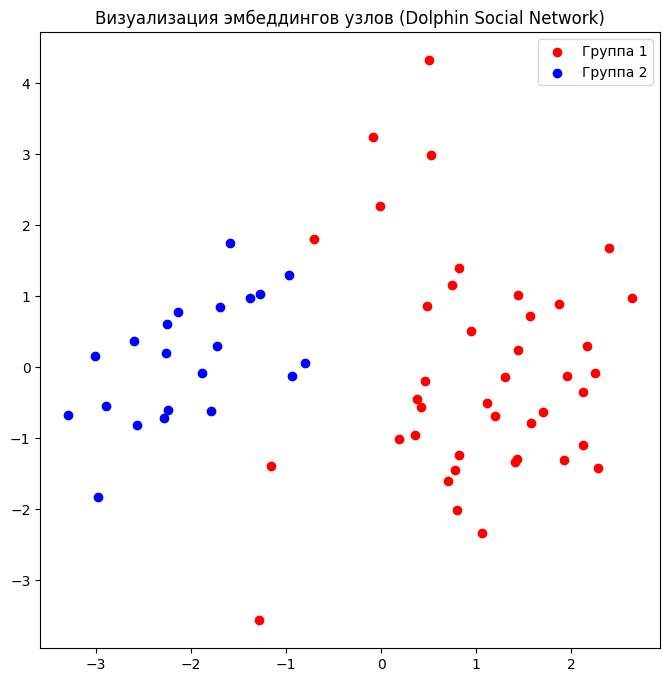

Эпоха 5601, Потеря: 0.0088
Эпоха 5602, Потеря: 0.0088
Эпоха 5603, Потеря: 0.0088
Эпоха 5604, Потеря: 0.0088
Эпоха 5605, Потеря: 0.0088
Эпоха 5606, Потеря: 0.0088
Эпоха 5607, Потеря: 0.0088
Эпоха 5608, Потеря: 0.0088
Эпоха 5609, Потеря: 0.0088
Эпоха 5610, Потеря: 0.0088
Эпоха 5611, Потеря: 0.0088
Эпоха 5612, Потеря: 0.0088
Эпоха 5613, Потеря: 0.0088
Эпоха 5614, Потеря: 0.0088
Эпоха 5615, Потеря: 0.0088
Эпоха 5616, Потеря: 0.0088
Эпоха 5617, Потеря: 0.0088
Эпоха 5618, Потеря: 0.0088
Эпоха 5619, Потеря: 0.0088
Эпоха 5620, Потеря: 0.0088
Эпоха 5621, Потеря: 0.0088
Эпоха 5622, Потеря: 0.0088
Эпоха 5623, Потеря: 0.0088
Эпоха 5624, Потеря: 0.0088
Эпоха 5625, Потеря: 0.0088
Эпоха 5626, Потеря: 0.0088
Эпоха 5627, Потеря: 0.0088
Эпоха 5628, Потеря: 0.0088
Эпоха 5629, Потеря: 0.0088
Эпоха 5630, Потеря: 0.0087
Эпоха 5631, Потеря: 0.0087
Эпоха 5632, Потеря: 0.0087
Эпоха 5633, Потеря: 0.0087
Эпоха 5634, Потеря: 0.0087
Эпоха 5635, Потеря: 0.0087
Эпоха 5636, Потеря: 0.0087
Эпоха 5637, Потеря: 0.0087
Э

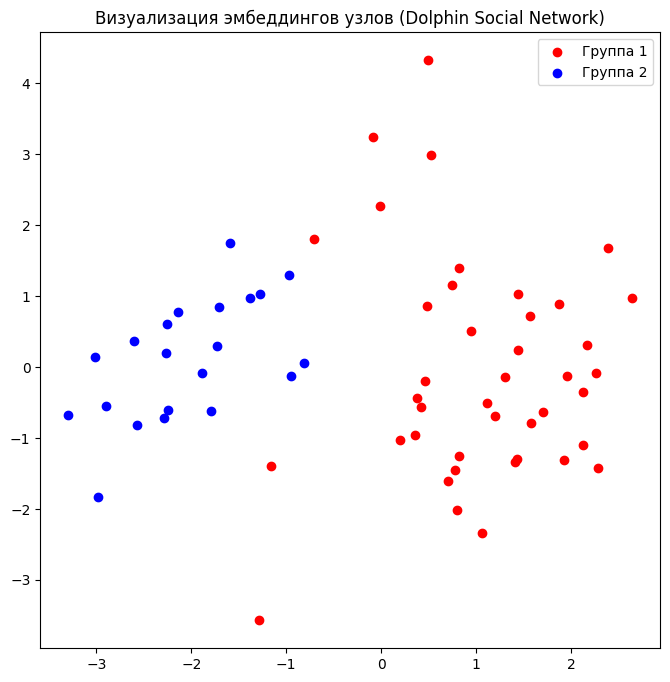

Эпоха 5651, Потеря: 0.0087
Эпоха 5652, Потеря: 0.0087
Эпоха 5653, Потеря: 0.0087
Эпоха 5654, Потеря: 0.0087
Эпоха 5655, Потеря: 0.0087
Эпоха 5656, Потеря: 0.0087
Эпоха 5657, Потеря: 0.0087
Эпоха 5658, Потеря: 0.0087
Эпоха 5659, Потеря: 0.0087
Эпоха 5660, Потеря: 0.0087
Эпоха 5661, Потеря: 0.0087
Эпоха 5662, Потеря: 0.0087
Эпоха 5663, Потеря: 0.0087
Эпоха 5664, Потеря: 0.0087
Эпоха 5665, Потеря: 0.0087
Эпоха 5666, Потеря: 0.0087
Эпоха 5667, Потеря: 0.0087
Эпоха 5668, Потеря: 0.0087
Эпоха 5669, Потеря: 0.0087
Эпоха 5670, Потеря: 0.0087
Эпоха 5671, Потеря: 0.0087
Эпоха 5672, Потеря: 0.0087
Эпоха 5673, Потеря: 0.0087
Эпоха 5674, Потеря: 0.0087
Эпоха 5675, Потеря: 0.0087
Эпоха 5676, Потеря: 0.0087
Эпоха 5677, Потеря: 0.0087
Эпоха 5678, Потеря: 0.0087
Эпоха 5679, Потеря: 0.0087
Эпоха 5680, Потеря: 0.0086
Эпоха 5681, Потеря: 0.0086
Эпоха 5682, Потеря: 0.0086
Эпоха 5683, Потеря: 0.0086
Эпоха 5684, Потеря: 0.0086
Эпоха 5685, Потеря: 0.0086
Эпоха 5686, Потеря: 0.0086
Эпоха 5687, Потеря: 0.0086
Э

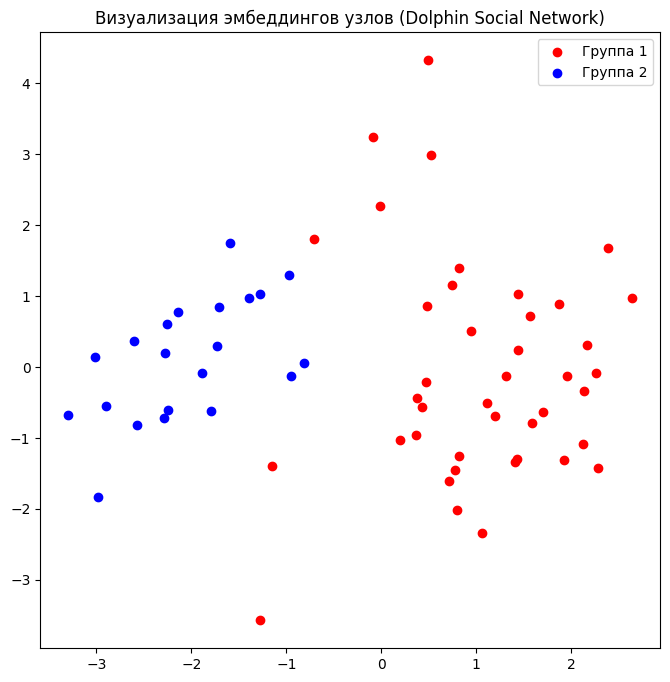

Эпоха 5701, Потеря: 0.0086
Эпоха 5702, Потеря: 0.0086
Эпоха 5703, Потеря: 0.0086
Эпоха 5704, Потеря: 0.0086
Эпоха 5705, Потеря: 0.0086
Эпоха 5706, Потеря: 0.0086
Эпоха 5707, Потеря: 0.0086
Эпоха 5708, Потеря: 0.0086
Эпоха 5709, Потеря: 0.0086
Эпоха 5710, Потеря: 0.0086
Эпоха 5711, Потеря: 0.0086
Эпоха 5712, Потеря: 0.0086
Эпоха 5713, Потеря: 0.0086
Эпоха 5714, Потеря: 0.0086
Эпоха 5715, Потеря: 0.0086
Эпоха 5716, Потеря: 0.0086
Эпоха 5717, Потеря: 0.0086
Эпоха 5718, Потеря: 0.0086
Эпоха 5719, Потеря: 0.0086
Эпоха 5720, Потеря: 0.0086
Эпоха 5721, Потеря: 0.0086
Эпоха 5722, Потеря: 0.0086
Эпоха 5723, Потеря: 0.0086
Эпоха 5724, Потеря: 0.0086
Эпоха 5725, Потеря: 0.0086
Эпоха 5726, Потеря: 0.0086
Эпоха 5727, Потеря: 0.0086
Эпоха 5728, Потеря: 0.0086
Эпоха 5729, Потеря: 0.0086
Эпоха 5730, Потеря: 0.0086
Эпоха 5731, Потеря: 0.0086
Эпоха 5732, Потеря: 0.0085
Эпоха 5733, Потеря: 0.0085
Эпоха 5734, Потеря: 0.0085
Эпоха 5735, Потеря: 0.0085
Эпоха 5736, Потеря: 0.0085
Эпоха 5737, Потеря: 0.0085
Э

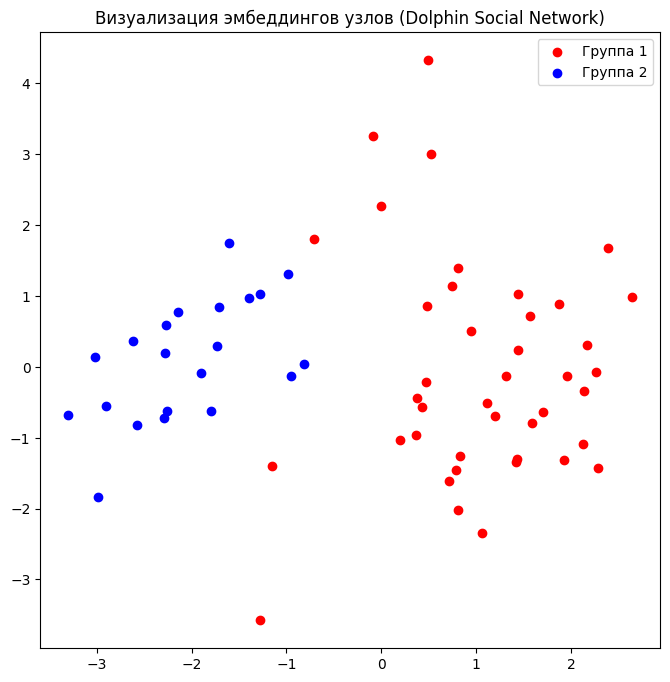

Эпоха 5751, Потеря: 0.0085
Эпоха 5752, Потеря: 0.0085
Эпоха 5753, Потеря: 0.0085
Эпоха 5754, Потеря: 0.0085
Эпоха 5755, Потеря: 0.0085
Эпоха 5756, Потеря: 0.0085
Эпоха 5757, Потеря: 0.0085
Эпоха 5758, Потеря: 0.0085
Эпоха 5759, Потеря: 0.0085
Эпоха 5760, Потеря: 0.0085
Эпоха 5761, Потеря: 0.0085
Эпоха 5762, Потеря: 0.0085
Эпоха 5763, Потеря: 0.0085
Эпоха 5764, Потеря: 0.0085
Эпоха 5765, Потеря: 0.0085
Эпоха 5766, Потеря: 0.0085
Эпоха 5767, Потеря: 0.0085
Эпоха 5768, Потеря: 0.0085
Эпоха 5769, Потеря: 0.0085
Эпоха 5770, Потеря: 0.0085
Эпоха 5771, Потеря: 0.0085
Эпоха 5772, Потеря: 0.0085
Эпоха 5773, Потеря: 0.0085
Эпоха 5774, Потеря: 0.0085
Эпоха 5775, Потеря: 0.0085
Эпоха 5776, Потеря: 0.0085
Эпоха 5777, Потеря: 0.0085
Эпоха 5778, Потеря: 0.0085
Эпоха 5779, Потеря: 0.0085
Эпоха 5780, Потеря: 0.0085
Эпоха 5781, Потеря: 0.0085
Эпоха 5782, Потеря: 0.0085
Эпоха 5783, Потеря: 0.0085
Эпоха 5784, Потеря: 0.0085
Эпоха 5785, Потеря: 0.0084
Эпоха 5786, Потеря: 0.0084
Эпоха 5787, Потеря: 0.0084
Э

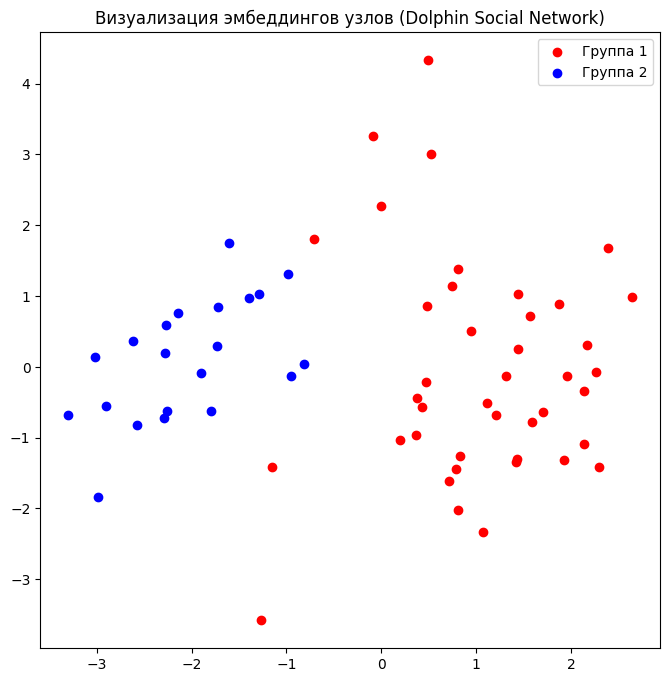

Эпоха 5801, Потеря: 0.0084
Эпоха 5802, Потеря: 0.0084
Эпоха 5803, Потеря: 0.0084
Эпоха 5804, Потеря: 0.0084
Эпоха 5805, Потеря: 0.0084
Эпоха 5806, Потеря: 0.0084
Эпоха 5807, Потеря: 0.0084
Эпоха 5808, Потеря: 0.0084
Эпоха 5809, Потеря: 0.0084
Эпоха 5810, Потеря: 0.0084
Эпоха 5811, Потеря: 0.0084
Эпоха 5812, Потеря: 0.0084
Эпоха 5813, Потеря: 0.0084
Эпоха 5814, Потеря: 0.0084
Эпоха 5815, Потеря: 0.0084
Эпоха 5816, Потеря: 0.0084
Эпоха 5817, Потеря: 0.0084
Эпоха 5818, Потеря: 0.0084
Эпоха 5819, Потеря: 0.0084
Эпоха 5820, Потеря: 0.0084
Эпоха 5821, Потеря: 0.0084
Эпоха 5822, Потеря: 0.0084
Эпоха 5823, Потеря: 0.0084
Эпоха 5824, Потеря: 0.0084
Эпоха 5825, Потеря: 0.0084
Эпоха 5826, Потеря: 0.0084
Эпоха 5827, Потеря: 0.0084
Эпоха 5828, Потеря: 0.0084
Эпоха 5829, Потеря: 0.0084
Эпоха 5830, Потеря: 0.0084
Эпоха 5831, Потеря: 0.0084
Эпоха 5832, Потеря: 0.0084
Эпоха 5833, Потеря: 0.0084
Эпоха 5834, Потеря: 0.0084
Эпоха 5835, Потеря: 0.0084
Эпоха 5836, Потеря: 0.0084
Эпоха 5837, Потеря: 0.0084
Э

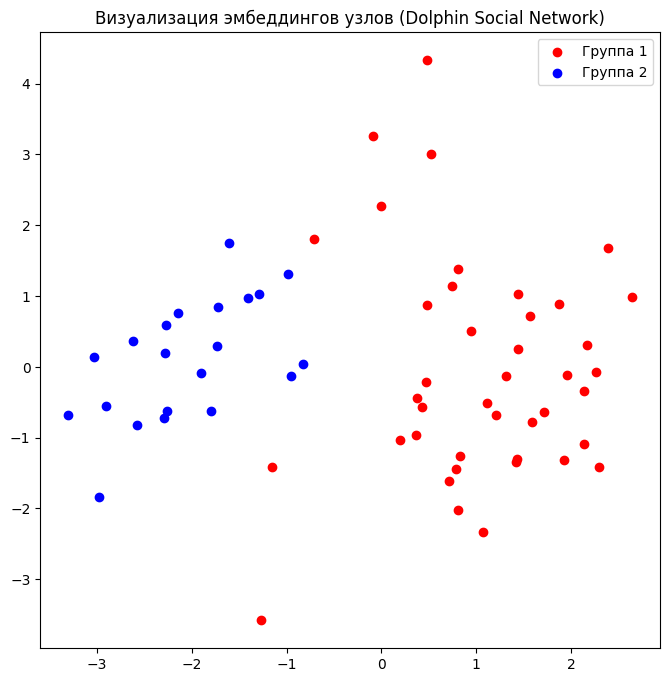

Эпоха 5851, Потеря: 0.0083
Эпоха 5852, Потеря: 0.0083
Эпоха 5853, Потеря: 0.0083
Эпоха 5854, Потеря: 0.0083
Эпоха 5855, Потеря: 0.0083
Эпоха 5856, Потеря: 0.0083
Эпоха 5857, Потеря: 0.0083
Эпоха 5858, Потеря: 0.0083
Эпоха 5859, Потеря: 0.0083
Эпоха 5860, Потеря: 0.0083
Эпоха 5861, Потеря: 0.0083
Эпоха 5862, Потеря: 0.0083
Эпоха 5863, Потеря: 0.0083
Эпоха 5864, Потеря: 0.0083
Эпоха 5865, Потеря: 0.0083
Эпоха 5866, Потеря: 0.0083
Эпоха 5867, Потеря: 0.0083
Эпоха 5868, Потеря: 0.0083
Эпоха 5869, Потеря: 0.0083
Эпоха 5870, Потеря: 0.0083
Эпоха 5871, Потеря: 0.0083
Эпоха 5872, Потеря: 0.0083
Эпоха 5873, Потеря: 0.0083
Эпоха 5874, Потеря: 0.0083
Эпоха 5875, Потеря: 0.0083
Эпоха 5876, Потеря: 0.0083
Эпоха 5877, Потеря: 0.0083
Эпоха 5878, Потеря: 0.0083
Эпоха 5879, Потеря: 0.0083
Эпоха 5880, Потеря: 0.0083
Эпоха 5881, Потеря: 0.0083
Эпоха 5882, Потеря: 0.0083
Эпоха 5883, Потеря: 0.0083
Эпоха 5884, Потеря: 0.0083
Эпоха 5885, Потеря: 0.0083
Эпоха 5886, Потеря: 0.0083
Эпоха 5887, Потеря: 0.0083
Э

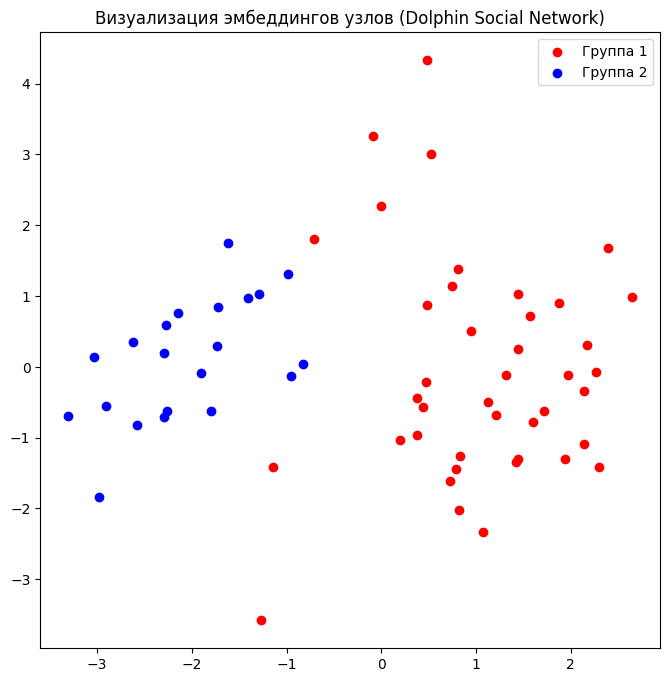

Эпоха 5901, Потеря: 0.0082
Эпоха 5902, Потеря: 0.0082
Эпоха 5903, Потеря: 0.0082
Эпоха 5904, Потеря: 0.0082
Эпоха 5905, Потеря: 0.0082
Эпоха 5906, Потеря: 0.0082
Эпоха 5907, Потеря: 0.0082
Эпоха 5908, Потеря: 0.0082
Эпоха 5909, Потеря: 0.0082
Эпоха 5910, Потеря: 0.0082
Эпоха 5911, Потеря: 0.0082
Эпоха 5912, Потеря: 0.0082
Эпоха 5913, Потеря: 0.0082
Эпоха 5914, Потеря: 0.0082
Эпоха 5915, Потеря: 0.0082
Эпоха 5916, Потеря: 0.0082
Эпоха 5917, Потеря: 0.0082
Эпоха 5918, Потеря: 0.0082
Эпоха 5919, Потеря: 0.0082
Эпоха 5920, Потеря: 0.0082
Эпоха 5921, Потеря: 0.0082
Эпоха 5922, Потеря: 0.0082
Эпоха 5923, Потеря: 0.0082
Эпоха 5924, Потеря: 0.0082
Эпоха 5925, Потеря: 0.0082
Эпоха 5926, Потеря: 0.0082
Эпоха 5927, Потеря: 0.0082
Эпоха 5928, Потеря: 0.0082
Эпоха 5929, Потеря: 0.0082
Эпоха 5930, Потеря: 0.0082
Эпоха 5931, Потеря: 0.0082
Эпоха 5932, Потеря: 0.0082
Эпоха 5933, Потеря: 0.0082
Эпоха 5934, Потеря: 0.0082
Эпоха 5935, Потеря: 0.0082
Эпоха 5936, Потеря: 0.0082
Эпоха 5937, Потеря: 0.0082
Э

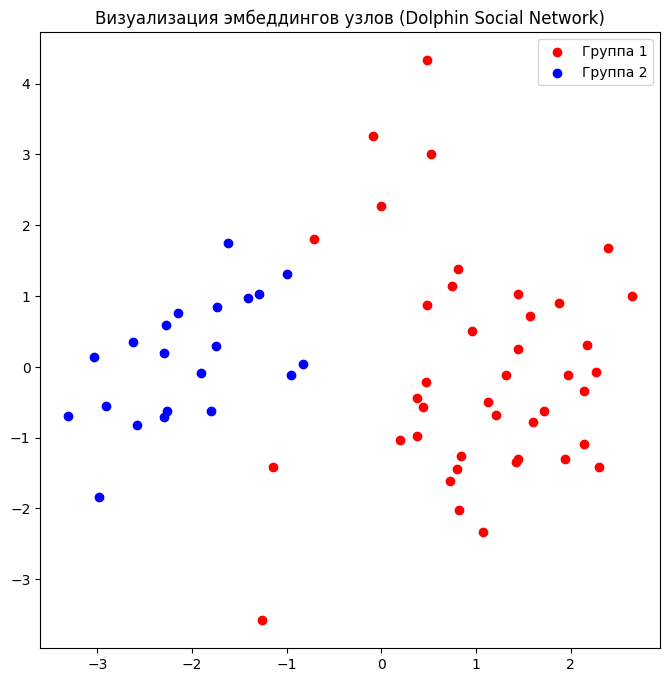

Эпоха 5951, Потеря: 0.0081
Эпоха 5952, Потеря: 0.0081
Эпоха 5953, Потеря: 0.0081
Эпоха 5954, Потеря: 0.0081
Эпоха 5955, Потеря: 0.0081
Эпоха 5956, Потеря: 0.0081
Эпоха 5957, Потеря: 0.0081
Эпоха 5958, Потеря: 0.0081
Эпоха 5959, Потеря: 0.0081
Эпоха 5960, Потеря: 0.0081
Эпоха 5961, Потеря: 0.0081
Эпоха 5962, Потеря: 0.0081
Эпоха 5963, Потеря: 0.0081
Эпоха 5964, Потеря: 0.0081
Эпоха 5965, Потеря: 0.0081
Эпоха 5966, Потеря: 0.0081
Эпоха 5967, Потеря: 0.0081
Эпоха 5968, Потеря: 0.0081
Эпоха 5969, Потеря: 0.0081
Эпоха 5970, Потеря: 0.0081
Эпоха 5971, Потеря: 0.0081
Эпоха 5972, Потеря: 0.0081
Эпоха 5973, Потеря: 0.0081
Эпоха 5974, Потеря: 0.0081
Эпоха 5975, Потеря: 0.0081
Эпоха 5976, Потеря: 0.0081
Эпоха 5977, Потеря: 0.0081
Эпоха 5978, Потеря: 0.0081
Эпоха 5979, Потеря: 0.0081
Эпоха 5980, Потеря: 0.0081
Эпоха 5981, Потеря: 0.0081
Эпоха 5982, Потеря: 0.0081
Эпоха 5983, Потеря: 0.0081
Эпоха 5984, Потеря: 0.0081
Эпоха 5985, Потеря: 0.0081
Эпоха 5986, Потеря: 0.0081
Эпоха 5987, Потеря: 0.0081
Э

In [37]:
embedding_dim = 16
embedding_layer = nn.Embedding(len(G.nodes()), embedding_dim)

learning_rate = 0.01
optimizer = SGD(embedding_layer.parameters(), lr=learning_rate, momentum=0.9)
loss_fn = nn.BCELoss()
sigmoid = nn.Sigmoid()

pos_label = torch.ones(pos_edge_index.shape[1])
neg_label = torch.zeros(neg_edge_index.shape[1])
train_label = torch.cat([pos_label, neg_label], dim=0)

train_edge = torch.cat([pos_edge_index, neg_edge_index], dim=1)
epochs = 6000
train(embedding_layer, train_edge, train_label, loss_fn, optimizer, epochs, G, group1, group2)

**Вывод:** Узлы двух сообществ достаточно четко разделены в пространстве после применения метода PCA.


5) Реализуем `node2vec` блуждания и обучим классификатор, используя его:

In [44]:
def node2vec_walk(G, start_node, walk_length, p, q):
    '''
    Выполняет одно случайное блуждание, используя параметры p и q.
    Параметры:
        - G: граф (networkx.Graph)
        - start_node: начальный узел для блуждания
        - walk_length: максимальная длина блуждания
        - p: параметр для управления вероятностью возврата к предыдущему узлу
        - q: параметр для управления вероятностью исследования новых узлов
    Возвращает:
        Список узлов, представляющий последовательность посещённых узлов за одно блуждание.
    '''
    walk = [start_node]
    while len(walk) < walk_length:
        cur = walk[-1]
        neighbors = list(G.neighbors(cur))
        if neighbors:
            if len(walk) == 1:
                next_node = random.choice(neighbors)
            else:
                prev = walk[-2]
                probabilities = []
                for neighbor in neighbors:
                    if neighbor == prev:
                        probabilities.append(1 / p)  # Вероятность возврата
                    elif G.has_edge(prev, neighbor):
                        probabilities.append(1)  # Узел, связанный с предыдущим
                    else:
                        probabilities.append(1 / q)  # Исследование новых узлов
                total = sum(probabilities)
                probabilities = [prob / total for prob in probabilities]
                next_node = random.choices(neighbors, probabilities)[0]
            walk.append(next_node)
        else:
            break
    return walk

In [45]:
def generate_node2vec_walks(G, num_walks, walk_length, p, q):
    '''
    Генерирует множество случайных блужданий по графу, используя алгоритм Node2Vec.
    Параметры:
        - G: граф (networkx.Graph)
        - num_walks: количество блужданий для каждого узла
        - walk_length: длина каждого блуждания
        - p: параметр для управления вероятностью возврата к предыдущему узлу
        - q: параметр для управления вероятностью исследования новых узлов
    Возвращает:
        Список списков, где каждый вложенный список — это последовательность узлов, пройденных за одно блуждание.
    '''
    walks = []
    nodes = list(G.nodes())
    for _ in range(num_walks):
        random.shuffle(nodes)
        for node in nodes:
            walks.append(node2vec_walk(G, node, walk_length, p, q))
    return walks

In [54]:
def train_word2vec(walks, dimensions=16):
    '''
    Обучает модель Word2Vec на основе сгенерированных блужданий по графу.
    Параметры:
        - walks: список блужданий (последовательностей узлов)
        - dimensions: размерность эмбеддингов
    Возвращает:
        Обученная модель Word2Vec, которая содержит эмбеддинги узлов графа.
    '''
    walks = [[str(node) for node in walk] for walk in walks]
    model = Word2Vec(sentences=walks, vector_size=dimensions, window=5, min_count=0, sg=1, workers=4)
    return model

In [47]:
def visualize_embeddings(model, G, group1, group2):
    '''
    Визуализирует эмбеддинги узлов, используя метод PCA для снижения размерности до 2D, и выделяет узлы двух сообществ разными цветами.
    Параметры:
        - model: обученная модель Word2Vec с эмбеддингами узлов
        - G: граф (networkx.Graph)
        - group1, group2: множества узлов, принадлежащие двум разным сообществам
    '''
    node_embeddings = np.array([model.wv[str(node)] for node in G.nodes()])

    pca = PCA(n_components=2)
    components = pca.fit_transform(node_embeddings)

    plt.figure(figsize=(8, 8))
    group1_x, group1_y = [], []
    group2_x, group2_y = [], []

    for i, node in enumerate(G.nodes()):
        if node in group1:
            group1_x.append(components[i, 0])
            group1_y.append(components[i, 1])
        else:
            group2_x.append(components[i, 0])
            group2_y.append(components[i, 1])

    plt.scatter(group1_x, group1_y, color="red", label="Группа 1")
    plt.scatter(group2_x, group2_y, color="blue", label="Группа 2")
    plt.title("Визуализация эмбеддингов узлов (Node2Vec)")
    plt.legend()
    plt.show()

In [48]:
def train_classifier(G, model, group1, group2):
    '''
    Обучает классификатор на эмбеддингах узлов и оценивает его точность.
    Параметры:
        - G: граф (networkx.Graph)
        - model: обученная модель Word2Vec с эмбеддингами узлов
        - group1, group2: множества узлов, принадлежащие двум разным сообществам
    Возвращает:
        Точность классификатора на тестовой выборке.
    '''
    node_embeddings = np.array([model.wv[str(node)] for node in G.nodes()])
    labels = np.array([1 if node in group1 else 0 for node in G.nodes()])

    X_train, X_test, y_train, y_test = train_test_split(node_embeddings, labels, test_size=0.3, random_state=42)
    clf = LogisticRegression(solver='lbfgs')
    clf.fit(X_train, y_train)
    accuracy = accuracy_score(y_test, clf.predict(X_test))
    return accuracy

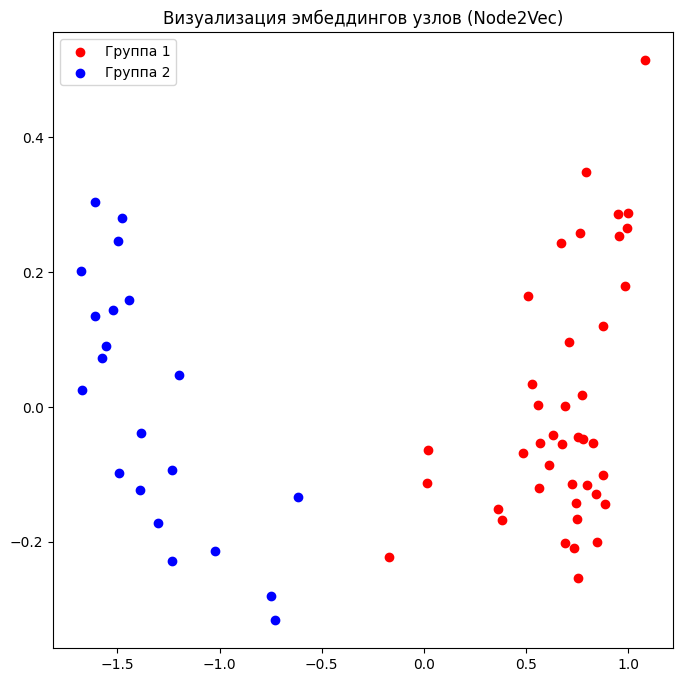

Точность классификатора с Node2Vec: 1.0000


In [53]:
dimensions = 16
walk_length = 15
num_walks = 10
p = 1  # Вероятность возврата
q = 0.5

walks = generate_node2vec_walks(G, num_walks, walk_length, p, q)
model = train_word2vec(walks, dimensions)
visualize_embeddings(model, G, group1, group2)
accuracy = train_classifier(G, model, group1, group2)
print(f"Точность классификатора с Node2Vec: {accuracy:.4f}")

**Вывод:** Узлы двух сообществ чётко разделены на графике. Красные точки сконцентрированы с правой стороны, а синие точки расположены с левой стороны. Это указывает на то, что `Node2Vec` смог эффективно захватить структуру графа и выделить различия между двумя сообществами. Видно, что внутри каждой группы узлы достаточно плотно сгруппированы, что говорит о схожести их топологических связей в графе. Это подтверждает, что эмбеддинги отразили структуру взаимодействий дельфинов.

Оба метода успешно решают задачу, но Node2Vec даёт более гибкие результаты, позволяя лучше настроить разделение узлов на кластеры в зависимости от их связей.